In [534]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

import re
import warnings
import math
from pathlib import Path
from datetime import datetime

import phreeqpy.iphreeqc.phreeqc_dll as phreeqc_mod
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats('png')
matplotlib.rcParams['savefig.format'] = 'png'

print(f">>> matplotlib backend set to {matplotlib.get_backend()}")
print(">>> Inline figure format set to png")


>>> matplotlib backend set to module://matplotlib_inline.backend_inline
>>> Inline figure format set to png


In [535]:
# =========================================================
# Central model configuration
# =========================================================
dll_path = r"D:\USGS\IPhreeqcCOM 3.8.6-17100\bin\IPhreeqcCOM.dll"
db_path  = r"D:\USGS\IPhreeqcCOM 3.8.6-17100\database\PHREEQC_ThermoddemV1.10_15Dec2020.dat"

out_dir = Path.cwd()
print(f">>> Current working directory: {out_dir.resolve()}")

PRINT_FULL_HEADER = False

boundary_base = {
    "temp": 240,
    "pressure": 27,
    "units": "mol/kgw",
    "pH": 8.0,
    "pe": 0.0,
    "Na": 1.05,
    "Cl": 0.50,
    "K": 1e-3,
    "P(5)": 0.10,
    "water": 0.008,
}

boundary_interpolation = {
    "Cu(1)": {"start": 6.5e-4, "end": 4.1e-4, "mode": "exp", "shape_k": 3.0},
    "Fe(3)": {"start": 3.0e-4, "end": 5.0e-4, "mode": "exp", "shape_k": 3.0},
    "S(-2)": {"start": 2.4e-2, "end": 2.0e-2, "mode": "exp", "shape_k": 5.0},
    "Au(3)": {"start": 1.0e-4, "end": 1.0e-4, "mode": "linear"},
}

def transform_progress(progress, mode="linear", shape_k=3.0):
    p = float(np.clip(progress, 0.0, 1.0))
    mode = str(mode).lower()
    k = float(shape_k)
    if mode == "linear":
        return p
    if mode == "exp":
        if np.isclose(k, 0.0):
            return p
        num = np.exp(k * p) - 1.0
        den = np.exp(k) - 1.0
        return float(num / den)
    if mode == "log":
        k_abs = abs(k)
        if np.isclose(k_abs, 0.0):
            return p
        return float(np.log1p(k_abs * p) / np.log1p(k_abs))
    raise ValueError(f"Unknown interpolation mode: {mode}")

def interpolate_stage_value(start, end, progress, mode="linear", shape_k=3.0):
    g = transform_progress(progress=progress, mode=mode, shape_k=shape_k)
    return start + (end - start) * g

def build_stage_boundary_fluids(n_stages, boundary_base, boundary_interpolation):
    fluids = []
    for stage_index in range(1, n_stages + 1):
        progress = 0.0 if n_stages <= 1 else (stage_index - 1) / (n_stages - 1)
        cfg = dict(boundary_base)
        for sp, spec in boundary_interpolation.items():
            cfg[sp] = interpolate_stage_value(
                start=spec["start"],
                end=spec["end"],
                progress=progress,
                mode=spec.get("mode", "linear"),
                shape_k=spec.get("shape_k", 3.0),
            )
        cfg["stage_index"] = stage_index
        cfg["stage_label"] = f"Stage-{stage_index}"
        fluids.append(cfg)
    return fluids

model_config = {
    "n_cells": 10,
    "n_stages": 8,
    "stage_shifts": [2, 3, 4, 10, 15, 16, 19, 20],
    "transport_params": {
        "time_step": 1e4,
        "flow_direction": "diffusion_only",
        "boundary_conditions": "constant closed",
        "lengths": 1e-3,
        "dispersivities": 1e-6,
        "diffusion_coefficient": 1e-9,
        "correct_disp": None,
        "punch_cells": None,
        "punch_frequency": 1,
    },
    "initial_pore_solution": {
        "temp": 240,
        "pressure": 27,
        "units": "mol/kgw",
        "pH": 8.0,
        "pe": 0.0,
        "Na": 1e-1,
        "Cl": 1e-1,
        "K": 1e-10,
        "P(5)": 0.0,
        "Cu(2)": 5e-5,
        "Fe(3)": 1e-5,
        "S(-2)": 0.0,
        "Au(3)": 0.0,
        "water": 0.008,
    },
    "initial_pore_gradient": {
        "mode": "log", # "linear" / "exp" / "log"
        "shape_k": 5.0,
        "shell_factor": 1.0,
        "core_factor": 0.1,
        "species": ["Na", "Cl", "K", "P(5)", "Cu(2)", "Fe(3)", "S(-2)", "Au(3)"],
    },
    "boundary_base": boundary_base,
    "boundary_interpolation": boundary_interpolation,
    "stage_boundary_fluids": build_stage_boundary_fluids(
        n_stages=8,
        boundary_base=boundary_base,
        boundary_interpolation=boundary_interpolation,
    ),
    "equilibrium_phases": [
        ("Pyrite", 0.8, 0, None),
        ("Chalcopyrite(alpha)", -2.0, 0, None),
        ("Bornite(alpha)", -1.0, 0, None),
        ("Magnetite", 0.6, 0, None),
        ("Chalcocite(alpha)", 1.0, 0, None),
        ("Au(element)", 0, 0, None),
        ("Cu(element)", 0, 0, None),
    ],
    "hematite_kinetics": {
        "rate_name": "Hematite_PK", "formula": "Fe2O3", "m": 5e-7, "m0": 5e-7,
        "affinity_factor": 0, "sp_area": 1.0e3, "roughness": 10,
        "lgkH": -9.39, "e_H": 66.2, "nH": 1, "lgkH2O": -14.6, "e_H2O": 66.2,
        "lgkOH": -30, "e_OH": 0, "nOH": 0, "tol": 1e-08,
        "step_divide": 10, "runge_kutta": 3, "bad_step_max": 500,
    },
    "selected_output": {
        "totals": ["Na", "Cl", "K", "P", "Cu", "Fe", "S", "Au", "P(5)", "Cu(1)", "Cu(2)",  "Fe(2)", "Fe(3)", "S(-2)", "S(6)", "Au(1)", "Au(3)"],
        "molalities": ["Fe+2", "Fe+3", "FeOH+", "FeOH+2", "FeCl+", "FeCl+2", "FeCl2", "FeCl2+", "Fe(OH)4-"],
        "equilibrium_phases": ["Magnetite", "Chalcocite(alpha)", "Chalcopyrite(alpha)", "Bornite(alpha)", "Au(element)", "Pyrite", "Cu(element)"],
        "saturation_indices": ["Hematite", "Magnetite", "Chalcocite(alpha)", "Pyrite", "Chalcopyrite(alpha)", "Bornite(alpha)", "Cu(element)", "Au(element)"],
        "kinetic_reactants": ["Hematite_PK"],
    },
    "plot": {
        "target_cells": [1, 4, 7, 10],
    },
}

n_stages = model_config["n_stages"]
stage_shifts = model_config["stage_shifts"]
stage_configs = []
for i, st in enumerate(model_config["stage_boundary_fluids"], start=1):
    cfg = dict(st)
    cfg["shifts"] = stage_shifts[i - 1]
    stage_configs.append(cfg)

target_cells = model_config["plot"]["target_cells"]


>>> Current working directory: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion


In [536]:
# =========================================================
# Initialize PHREEQC
# =========================================================
phreeqc = phreeqc_mod.IPhreeqc(dll_path)
phreeqc.load_database(db_path)

print(">>> Start 1D TRANSPORT Simulation (Extended Tracking Mode)...")
print(f">>> CSV output directory: {out_dir.resolve()}")
print(">>> Figures will be displayed inline in the notebook as SVG instead of being saved as PNG files.")


>>> Start 1D TRANSPORT Simulation (Extended Tracking Mode)...
>>> CSV output directory: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion
>>> Figures will be displayed inline in the notebook as SVG instead of being saved as PNG files.


In [537]:
# =========================================================
# Build PHREEQC input blocks
# =========================================================
def build_calculate_values_block():
    return """
CALCULATE_VALUES
SR_m_Hematite
-start
10 m = MOL("H+")
20 IF (m <= 0) THEN m = 1e-30
30 SR = SI("Hematite")
40 m_Hematite = 10^((2*LA("Fe+3") + 3*LA("H2O") - 6*LA("H+")) - LK_PHASE("Hematite"))
50 SAVE m_Hematite
-end
""".strip()

def build_rates_block(kin_cfg):
    return f"""
RATES
{kin_cfg['rate_name']}
-start
10 if (M <= 0) then goto 200
20 si_h = SI("Hematite")
30 if (si_h >= 0) then goto 200
40 aH = ACT("H+")
50 if (aH <= 1e-30) then aH = 1e-30
60 area = PARM(2) * PARM(3) * (M/M0)^PARM(4)
70 kH = 10^(PARM(5) - PARM(6)/TK) * (aH^PARM(7))
80 kH2O = 10^(PARM(8) - PARM(9)/TK)
90 kOH = 10^(PARM(10) - PARM(11)/TK) * (aH^(-PARM(12)))
100 rate = area * (kH + kH2O + kOH) * (1 - 10^(si_h))
110 if (rate < 0) then rate = 0
120 moles = rate * TIME
130 if (moles > M) then moles = M
200 SAVE moles
-end
""".strip()

def build_equilibrium_phases_block(n_cells, phases):
    lines = [f"EQUILIBRIUM_PHASES 1-{n_cells}"]
    for ph in phases:
        if len(ph) == 4:
            name, si, m, opt = ph
            if opt is None or str(opt).strip() == "":
                lines.append(f"    {name:<20} {si} {m}")
            else:
                lines.append(f"    {name:<20} {si} {m} {opt}")
        elif len(ph) == 3:
            name, si, m = ph
            lines.append(f"    {name:<20} {si} {m}")
        else:
            raise ValueError(f"Invalid equilibrium phase tuple: {ph}")
    return "\n".join(lines)

def build_kinetics_block(n_cells, kin_cfg):
    parms = [kin_cfg['affinity_factor'], kin_cfg['sp_area'], kin_cfg['roughness'], 0.67, kin_cfg['lgkH'], kin_cfg['e_H'], kin_cfg['nH'], kin_cfg['lgkH2O'], kin_cfg['e_H2O'], kin_cfg['lgkOH'], kin_cfg['e_OH'], kin_cfg['nOH']]
    parms_text = " ".join(str(v) for v in parms)
    return f"""
KINETICS 1-{n_cells}
{kin_cfg['rate_name']}
    -formula  {kin_cfg['formula']}  1
    -m      {kin_cfg['m']}
    -m0     {kin_cfg['m0']}
    -parms  {parms_text}
    -tol    {kin_cfg['tol']}
    -step_divide {kin_cfg['step_divide']}
    -runge_kutta {kin_cfg['runge_kutta']}
    -bad_step_max {kin_cfg['bad_step_max']}
""".strip()

def build_initial_cells_block(n_cells, pore_cfg, phases, kin_cfg, gradient_cfg=None):
    gradient_cfg = gradient_cfg or {}
    shell_factor = float(gradient_cfg.get("shell_factor", 1.0))
    core_factor = float(gradient_cfg.get("core_factor", shell_factor))
    grad_species = set(gradient_cfg.get("species", []))
    grad_mode = gradient_cfg.get("mode", "linear")
    grad_shape_k = float(gradient_cfg.get("shape_k", 3.0))

    def scaled_value(name, base_value, factor):
        if name in grad_species:
            return base_value * factor
        return base_value

    lines = []
    for cell in range(1, n_cells + 1):
        progress = 0.0 if n_cells == 1 else (cell - 1) / (n_cells - 1)
        mapped = transform_progress(progress=progress, mode=grad_mode, shape_k=grad_shape_k)
        factor = shell_factor + (core_factor - shell_factor) * mapped
        lines.extend([
            f"SOLUTION {cell}  Initial Alkaline Pore Fluid (shell->core gradient)",
            f"    temp      {pore_cfg['temp']}", f"    pressure  {pore_cfg['pressure']}",
            f"    units     {pore_cfg['units']}", f"    pH        {pore_cfg['pH']}",
            f"    pe        {pore_cfg['pe']}", "    redox     pe",
            f"    Na        {scaled_value('Na', pore_cfg['Na'], factor)}",
            f"    Cl        {scaled_value('Cl', pore_cfg['Cl'], factor)} charge",
            f"    P(5)      {scaled_value('P(5)', pore_cfg['P(5)'], factor)}",
            f"    Cu(2)     {scaled_value('Cu(2)', pore_cfg['Cu(2)'], factor)}",
            f"    Fe(3)     {scaled_value('Fe(3)', pore_cfg['Fe(3)'], factor)}",
            f"    S(-2)     {scaled_value('S(-2)', pore_cfg['S(-2)'], factor)}",
            f"    Au(3)     {scaled_value('Au(3)', pore_cfg['Au(3)'], factor)}",
        ])
        if "K" in pore_cfg:
            lines.append(f"    K         {scaled_value('K', pore_cfg['K'], factor)}")
        lines.extend([f"    -water    {pore_cfg['water']}", ""])

    lines.extend([build_equilibrium_phases_block(n_cells, phases), "", build_kinetics_block(n_cells, kin_cfg)])
    return "\n".join(lines).strip()

def make_transport_block(n_cells, shifts):
    punch_cells = transport_params.get("punch_cells") or f"1-{n_cells}"
    lines = ["TRANSPORT", f"    -cells                 {n_cells}", f"    -shifts                {shifts}"]
    if transport_params.get("time_step") is not None:
        lines.append(f"    -time_step             {transport_params['time_step']}")
    lines.extend([
        f"    -flow_direction        {transport_params['flow_direction']}",
        f"    -boundary_conditions   {transport_params['boundary_conditions']}",
        f"    -lengths               {transport_params['lengths']}",
        f"    -dispersivities        {transport_params['dispersivities']}",
        f"    -diffusion_coefficient {transport_params['diffusion_coefficient']}",
        f"    -punch_cells           {punch_cells}",
        f"    -punch_frequency       {transport_params['punch_frequency']}",
    ])
    correct_disp = transport_params.get("correct_disp", None)
    if correct_disp is True:
        lines.append("    -correct_disp          true")
    elif correct_disp is False:
        lines.append("    -correct_disp          false")
    return "\n".join(lines).strip()

def make_selected_output_block(title_text, stage_index):
    return f"""
TITLE Shell-to-core diffusion replacement: {title_text}
SELECTED_OUTPUT 1
    -reset false
    -step true
    -soln true
    -dist true
    -time true
    -temperature true
    -pH true
    -pe true
    -charge_balance true
    -percent_error true
    -totals               Na Cl K P Cu Fe S Au
                          P(5) Cu(1) Fe(2) Fe(3) S(-2) S(6) Au(1) Au(3)
    -molalities           Fe+2  Fe+3  FeOH+  FeOH+2
                          FeCl+  FeCl+2  FeCl2  FeCl2+
                          Fe(OH)4-
    -activities           SO4-2  Cu(HS)2-  Au(HS)2-  AuHS
                          H+  OH-  HS-  H2S
                          Au(OH)2-  Au+  Au+3  AuCl
                          AuCl2-  AuCl3-2  AuCl4-  AuOH
                          Cu2S(HS)2-2  CuCl+  CuCl2  CuCl2-
                          CuCl3-  CuCl3-2  CuCl4-2  CuHS
                          CuCl  CuOH  CuOH+  H2S
                          HS-  S-2
    -equilibrium_phases   Magnetite  Chalcocite(alpha)  Chalcopyrite(alpha)
                          Bornite(alpha)  Au(element)  Pyrite  Cu(element)
    -saturation_indices   Hematite  Magnetite  Chalcocite(alpha)  Pyrite
                          Chalcopyrite(alpha)  Bornite(alpha)  Cu(element)  Au(element)
    -kinetic_reactants    Hematite_PK
USER_PUNCH 1
    -headings stage u_step time_days pH_user logaHS- logaH2S SR_Hematite HematitePK_m
    -start
10 PUNCH {stage_index}, STEP_NO, TOTAL_TIME/3600/24, -LA("H+"), LA("HS-"), LA("H2S"), SR("Hematite"), KIN("Hematite_PK")
    -end
""".strip()

def make_solution0_block(cfg):
    lines = [
        f"SOLUTION 0  External boundary fluid at outer shell rim ({cfg['stage_label']})",
        f"    temp      {cfg['temp']}", f"    pressure  {cfg['pressure']}",
        f"    pH        {cfg.get('pH', initial_pore_solution['pH'])}", f"    pe        {cfg.get('pe', initial_pore_solution['pe'])}", "    redox     pe",
        f"    units     {cfg['units']}", f"    Na        {cfg['Na']}",
        f"    Cl        {cfg['Cl']} charge", f"    P(5)      {cfg['P(5)']}",
        f"    Cu(1)     {cfg.get('Cu(1)', cfg.get('cu_value'))}", f"    Fe(3)     {cfg.get('Fe(3)', cfg.get('fe_value'))}",
        f"    S(-2)     {cfg.get('S(-2)', cfg.get('s_value'))}", f"    Au(3)     {cfg.get('Au(3)', cfg.get('au_value'))}",
    ]
    if "K" in cfg:
        lines.append(f"    K         {cfg['K']}")
    lines.extend([f"    -water    {cfg['water']}", "SAVE solution 0"])
    return "\n".join(lines).strip()

initial_pore_solution = model_config["initial_pore_solution"]
initial_pore_gradient = model_config.get("initial_pore_gradient")
equilibrium_phases = model_config["equilibrium_phases"]
hematite_kinetics = model_config["hematite_kinetics"]
transport_params = model_config["transport_params"]
n_cells_default = model_config["n_cells"]

initial_cells_block = build_initial_cells_block(n_cells_default, initial_pore_solution, equilibrium_phases, hematite_kinetics, initial_pore_gradient)
calculate_values_block = build_calculate_values_block()
rates_block = build_rates_block(hematite_kinetics)

combined_script_parts = []
for i, cfg in enumerate(stage_configs):
    combined_script_parts.append(make_selected_output_block(f"Sequential Stage {cfg['stage_index']}", cfg["stage_index"]))
    combined_script_parts.append(make_solution0_block(cfg))
    if i == 0:
        combined_script_parts.append(calculate_values_block)
        combined_script_parts.append(rates_block)
        combined_script_parts.append(initial_cells_block)
    combined_script_parts.append(make_transport_block(n_cells=n_cells_default, shifts=cfg["shifts"]))
    combined_script_parts.append("END")

combined_phreeqc_script = "\n\n".join(part for part in combined_script_parts if part)
phreeqc_script = combined_phreeqc_script
phreeqc_template = combined_phreeqc_script  # compatibility alias for downstream cells

if any(item[0].lower() == "hematite" for item in equilibrium_phases):
    raise ValueError("Hematite must not be included in equilibrium_phases. Use KINETICS instead.")

time_step = model_config["transport_params"]["time_step"]
lengths = model_config["transport_params"]["lengths"]
flow_direction = model_config["transport_params"]["flow_direction"]
boundary_conditions = model_config["transport_params"]["boundary_conditions"]

total_shifts = sum(cfg["shifts"] for cfg in stage_configs)
total_time_s = total_shifts * time_step
total_advective_distance = total_shifts * lengths

print(">>> Flux/advection transport setup report:")
print(f"    n_cells = {n_cells_default}")
print(f"    shifts per stage = {[cfg['shifts'] for cfg in stage_configs]}")
print(f"    total shifts = {total_shifts}")
print(f"    flow_direction = {flow_direction}")
print(f"    boundary_conditions = {boundary_conditions}")
print(f"    dx = {lengths}")
print(f"    time_step = {time_step}")
print(f"    total time = {total_time_s:.3e} s = {total_time_s/3600:.3f} h")
print(f"    nominal advective distance = {total_advective_distance:.3e} m")
print(f"    nominal pore-water velocity = {lengths / time_step:.3e} m/s")


print("=== Configuration Consistency Check ===")


>>> Flux/advection transport setup report:
    n_cells = 10
    shifts per stage = [2, 3, 4, 10, 15, 16, 19, 20]
    total shifts = 89
    flow_direction = diffusion_only
    boundary_conditions = constant closed
    dx = 0.001
    time_step = 10000.0
    total time = 8.900e+05 s = 247.222 h
    nominal advective distance = 8.900e-02 m
    nominal pore-water velocity = 1.000e-07 m/s
=== Configuration Consistency Check ===


In [538]:
# =========================================================
# Helper functions
# =========================================================
def try_extract_first_float(pattern, text, name, flags=re.IGNORECASE | re.MULTILINE):
    m = re.search(pattern, text, flags=flags)
    if not m:
        warnings.warn(f"Normalization reference not found: {name}. Fallback will be used.")
        return None
    try:
        return float(m.group(1))
    except Exception:
        warnings.warn(f"Failed to parse normalization reference: {name}. Fallback will be used.")
        return None

def safe_divide(series, denominator):
    if denominator is None:
        warnings.warn("Denominator is None. Raw values will be used instead of normalized values.")
        return series.copy()
    if denominator == 0:
        warnings.warn("Denominator is zero. Raw values will be used instead of normalized values.")
        return series.copy()
    return series / denominator

def add_stage_background(ax, stage_ranges):
    stage_colors = ["#dbeafe", "#fee2e2", "#dcfce7", "#fef3c7"]
    for i, (s0, s1, label) in enumerate(stage_ranges):
        color = stage_colors[i % len(stage_colors)]
        ax.axvspan(s0, s1, color=color, alpha=0.25, zorder=0)
        if i > 0:
            ax.axvline(s0, color="k", linestyle="--", linewidth=1.2, alpha=0.8)

def add_stage_labels(ax, stage_ranges, ypad=0.96):
    xmin, xmax = ax.get_xlim()
    xr = xmax - xmin if xmax > xmin else 1.0
    for (s0, s1, label) in stage_ranges:
        xc = 0.5 * (s0 + s1)
        x_frac = (xc - xmin) / xr
        if 0 <= x_frac <= 1:
            ax.text(
                x_frac, ypad, label,
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=10
            )

def try_numeric(series):
    try:
        return pd.to_numeric(series)
    except Exception:
        return series


def nontrivial_series(series, atol=1e-30):
    if series is None:
        return False
    arr = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return False
    return np.nanmax(np.abs(arr)) > atol


def split_groups(items, group_size):
    return [items[i:i + group_size] for i in range(0, len(items), group_size)]


def savefig(fig, filename=None):
    fig.tight_layout()
    plt.show()
    print(f">>> Figure displayed inline{' : ' + filename if filename else ''}")


def savecsv(df, filename):
    path = out_dir / filename
    df.to_csv(path, index=False)
    print(f">>> Saved CSV: {path.resolve()}")


def _find_first_existing(colset, candidates):
    for cand in candidates:
        if cand in colset:
            return cand
    return None

def _find_fuzzy_column(cols, include_tokens, exclude_tokens=None):
    exclude_tokens = exclude_tokens or []
    include_tokens = [t.lower() for t in include_tokens]
    exclude_tokens = [t.lower() for t in exclude_tokens]
    for col in cols:
        low = col.lower()
        if all(t in low for t in include_tokens) and not any(t in low for t in exclude_tokens):
            return col
    return None

def resolve_exact_output_names(df):
    """
    Map requested logical names to actual PHREEQC output headers.
    Based on current observed header style:
      totals:     Na(mol/kgw)
      molality:   m_Fe+2(mol/kgw)
      activity:   la_AuCl2-
      eq phase:   Pyrite
      SI:         si_Hematite
    """
    cols = list(df.columns)
    colset = set(cols)

    totals_req = ["Na", "Cl", "P", "Cu", "Fe", "S", "Au", "P(5)", "Cu(1)", "Fe(2)", "Fe(3)", "S(-2)", "S(6)", "Au(1)", "Au(3)"]
    mol_req = [
        "Fe+2", "Fe+3", "FeOH+", "FeOH+2",
        "FeCl+", "FeCl+2", "FeCl2", "FeCl2+",
        "Fe(OH)4-"
    ]
    act_req = [
        "SO4-2", "Cu(HS)2-", "Au(HS)2-", "AuHS",
        "Au(OH)2-", "Au+", "Au+3", "AuCl",
        "AuCl2-", "AuCl3-2", "AuCl4-", "AuOH",
        "Cu2S(HS)2-2", "CuCl+", "CuCl2", "CuCl2-",
        "CuCl3-", "CuCl3-2", "CuCl4-2", "CuHS",
        "CuCl", "CuOH", "CuOH+", "H2S",
        "HS-", "S-2"
    ]
    eq_req = [
        "Magnetite", "Chalcocite(alpha)",
        "Chalcopyrite(alpha)", "Bornite(alpha)", "Au(element)",
        "Pyrite", "Cu(element)"
    ]
    si_req = [
        "si_Hematite", "si_Magnetite", "si_Chalcocite(alpha)", "si_Pyrite",
        "si_Chalcopyrite(alpha)", "si_Bornite(alpha)", "si_Cu(element)", "si_Au(element)"
    ]

    totals_map = {}
    for name in totals_req:
        cand = f"{name}(mol/kgw)"
        if cand in colset:
            totals_map[name] = cand

    mol_map = {}
    for name in mol_req:
        cand = f"m_{name}(mol/kgw)"
        if cand in colset:
            mol_map[name] = cand

    act_map = {}
    for name in act_req:
        cand = f"la_{name}"
        if cand in colset:
            act_map[name] = cand

    eq_map = {}
    for name in eq_req:
        if name in colset:
            eq_map[name] = name

    si_map = {}
    for name in si_req:
        if name in colset:
            si_map[name.replace("si_", "")] = name

    kin_map = {}

    hem_pk_remaining = _find_first_existing(colset, [
        "Hematite_PK",
        "k_Hematite_PK",
        "kin_Hematite_PK",
        "Hematite_PK(mol)",
        "Hematite_PK(moles)"
    ])
    if hem_pk_remaining is None:
        hem_pk_remaining = _find_fuzzy_column(
            cols,
            include_tokens=["hematite_pk"],
            exclude_tokens=["d_", "delta", "trans", "transfer"]
        )

    hem_pk_transferred = _find_first_existing(colset, [
        "d_Hematite_PK",
        "dk_Hematite_PK",
        "delta_Hematite_PK",
        "transferred_Hematite_PK"
    ])
    if hem_pk_transferred is None:
        hem_pk_transferred = _find_fuzzy_column(
            cols,
            include_tokens=["hematite_pk"],
            exclude_tokens=[]
        )
        if hem_pk_transferred == hem_pk_remaining:
            hem_pk_transferred = None

    if hem_pk_remaining is not None:
        kin_map["Hematite_PK_remaining"] = hem_pk_remaining
    if hem_pk_transferred is not None:
        kin_map["Hematite_PK_transferred"] = hem_pk_transferred

    return totals_map, mol_map, act_map, eq_map, si_map, kin_map

def find_col_fuzzy(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for col in df.columns:
        low = col.lower()
        if all(token.lower() in low for token in candidates[0].split()):
            return col
    return None

def detect_hematite_pk_column(df):
    col = find_col_fuzzy(df, ["Hematite_PK", "kin_Hematite_PK", "k_Hematite_PK"])
    if col is None:
        warnings.warn("Cannot find Hematite_PK kinetic column in SELECTED_OUTPUT.")
    return col


def plot_final_distribution(df_final, col_map, out_png, title, ylabel):
    if len(col_map) == 0:
        return False

    fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
    x = pd.to_numeric(df_final["cell_plot"], errors="coerce")

    plotted = False
    for label, col in col_map.items():
        y = pd.to_numeric(df_final[col], errors="coerce")
        if nontrivial_series(y):
            ax.plot(x, y, linewidth=2.0, label=label)
            plotted = True

    if not plotted:
        plt.close(fig)
        return False

    ax.set_xlabel("Radial shell index from rim to core", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    savefig(fig, out_png)
    return True


def plot_grouped_final_distribution(df_final, col_map, out_prefix, title_prefix, ylabel, group_size=6):
    keys = list(col_map.keys())
    if len(keys) == 0:
        return 0
    groups = split_groups(keys, group_size)
    count = 0
    for i, grp in enumerate(groups, start=1):
        submap = {k: col_map[k] for k in grp}
        ok = plot_final_distribution(
            df_final,
            submap,
            f"{out_prefix}_part{i}.png",
            f"{title_prefix} (Part {i})",
            ylabel
        )
        count += int(ok)
    return count


def plot_cell_tracking(df_evo, target_cells, col_map, out_png, title, ylabel, time_xlabel):
    if len(col_map) == 0:
        return False

    ncols = 2
    nrows = math.ceil(len(target_cells) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    anything_plotted = False

    for i, cell in enumerate(target_cells):
        ax = axes[i]
        sub = df_evo[df_evo["soln"] == cell].sort_values("time_plot")

        local_plotted = False
        for label, col in col_map.items():
            y = pd.to_numeric(sub[col], errors="coerce")
            if nontrivial_series(y):
                ax.plot(sub["time_plot"], y, linewidth=1.8, label=label)
                local_plotted = True
                anything_plotted = True

        ax.set_title(f"Cell {cell}", fontweight="bold")
        ax.set_xlabel(time_xlabel, fontweight="bold")
        ax.set_ylabel(ylabel, fontweight="bold")
        ax.grid(True, alpha=0.3)

        if i == 0 and local_plotted:
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)

        if not local_plotted:
            ax.text(0.5, 0.5, "No valid series", ha="center", va="center", transform=ax.transAxes)

    for j in range(len(target_cells), len(axes)):
        axes[j].axis("off")

    if anything_plotted:
        fig.suptitle(title, fontsize=14, fontweight="bold")
        savefig(fig, out_png)
        return True
    else:
        plt.close(fig)
        return False


def plot_grouped_cell_tracking(df_evo, target_cells, col_map, out_prefix, title_prefix, ylabel, time_xlabel, group_size=6):
    keys = list(col_map.keys())
    if len(keys) == 0:
        return 0
    groups = split_groups(keys, group_size)
    count = 0
    for i, grp in enumerate(groups, start=1):
        submap = {k: col_map[k] for k in grp}
        ok = plot_cell_tracking(
            df_evo,
            target_cells,
            submap,
            f"{out_prefix}_part{i}.png",
            f"{title_prefix} (Part {i})",
            ylabel,
            time_xlabel
        )
        count += int(ok)
    return count


def plot_filled_stack_area(df_final, phase_col_map, out_png, title, ylabel, au_col="Au(element)"):
    """
    100% stacked area plot using absolute mineral amounts.
    Input columns in phase_col_map should be raw phase columns, not *_plot columns.

    Features:
    1) 100% stacked area by cell
    2) black boundary lines between phases
    3) optional Au curve on secondary y-axis (raw absolute amount)
    """
    if len(phase_col_map) == 0:
        return False

    if "cell_plot" in df_final.columns:
        x = pd.to_numeric(df_final["cell_plot"], errors="coerce").to_numpy(dtype=float)
    elif "soln" in df_final.columns:
        x = pd.to_numeric(df_final["soln"], errors="coerce").to_numpy(dtype=float)
    else:
        x = np.arange(1, len(df_final) + 1, dtype=float)

    labels = []
    ys = []

    for label, col in phase_col_map.items():
        if col not in df_final.columns:
            continue
        y = pd.to_numeric(df_final[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        y[~np.isfinite(y)] = 0.0
        y = np.clip(y, 0.0, None)
        ys.append(y)
        labels.append(label)

    if len(ys) == 0:
        return False

    Y = np.vstack(ys)
    colsum = Y.sum(axis=0)

    valid = np.isfinite(colsum) & (colsum > 0)
    if not np.any(valid):
        return False

    Y_fill = np.zeros_like(Y, dtype=float)
    Y_fill[:, valid] = Y[:, valid] / colsum[valid]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

    ax.stackplot(
        x, *Y_fill,
        labels=labels,
        alpha=0.95
    )

    cum = np.cumsum(Y_fill, axis=0)
    for i in range(cum.shape[0]):
        ax.plot(
            x,
            cum[i, :],
            linewidth=1.0,
            color="black",
            alpha=0.7
        )

    ax2 = None
    if au_col in df_final.columns:
        y_au = pd.to_numeric(df_final[au_col], errors="coerce").to_numpy(dtype=float)
        y_au[~np.isfinite(y_au)] = np.nan

        y_au_valid = y_au[np.isfinite(y_au)]
        if y_au_valid.size > 0 and np.nanmax(np.abs(y_au_valid)) > 0:
            ax2 = ax.twinx()
            ax2.plot(
                x,
                y_au,
                linestyle="--",
                linewidth=2.2,
                color="purple",
                label="Au(element)"
            )
            ax2.set_ylabel("Au(element)", fontweight="bold", color="purple")
            ax2.tick_params(axis="y", colors="purple")

    ax.set_xlabel("Radial shell index from rim to core", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.25)

    leg1 = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        fontsize=9
    )
    ax.add_artist(leg1)

    if ax2 is not None:
        lines2, labels2 = ax2.get_legend_handles_labels()
        if lines2:
            ax2.legend(
                lines2, labels2,
                loc="lower left",
                bbox_to_anchor=(1.02, 0.0),
                frameon=False,
                fontsize=9
            )

    savefig(fig, out_png)
    return True


In [539]:
# =========================================================
# Added notebook-only patch: sync plotting flow/strategy with FASS
# =========================================================
# This cell intentionally overrides selected plotting helpers only.

def _to_log_positive(series):
    y = pd.to_numeric(series, errors="coerce").astype(float)
    y = y.where(np.isfinite(y))
    return y.where(y > 0)


def _is_au_series(label, col):
    text = f"{label} {col}".lower()
    return "au" in text or "gold" in text


def plot_final_distribution(df_final, col_map, out_png, title, ylabel):
    if len(col_map) == 0:
        return False

    fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
    ax_au = None
    x = pd.to_numeric(df_final["cell_plot"], errors="coerce")

    plotted_left = False
    plotted_right = False

    for label, col in col_map.items():
        y = _to_log_positive(df_final[col])
        if not nontrivial_series(y):
            continue

        if _is_au_series(label, col):
            if ax_au is None:
                ax_au = ax.twinx()
            ax_au.plot(x, y, linewidth=2.0, linestyle="--", label=label)
            plotted_right = True
        else:
            ax.plot(x, y, linewidth=2.0, label=label)
            plotted_left = True

    if not (plotted_left or plotted_right):
        plt.close(fig)
        return False

    ax.set_xlabel("Radial shell index from rim to core", fontweight="bold")
    ax.set_ylabel(f"{ylabel} (log scale)", fontweight="bold")
    ax.set_yscale("log")
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.3)

    if ax_au is not None:
        ax_au.set_ylabel(f"{ylabel} (Au-related, log scale)", fontweight="bold")
        ax_au.set_yscale("log")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = (ax_au.get_legend_handles_labels() if ax_au is not None else ([], []))
    if lines1 or lines2:
        ax.legend(lines1 + lines2, labels1 + labels2, loc="lower left",
                  frameon=True, facecolor="white", framealpha=0.65)

    savefig(fig, out_png)
    return True


def plot_cell_tracking(df_evo, target_cells, col_map, out_png, title, ylabel, time_xlabel):
    if len(col_map) == 0:
        return False

    ncols = 2
    nrows = math.ceil(len(target_cells) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    anything_plotted = False

    for i, cell in enumerate(target_cells):
        ax = axes[i]
        ax_au = None
        sub = df_evo[df_evo["soln"] == cell].sort_values("time_plot")

        local_plotted = False

        for label, col in col_map.items():
            y = _to_log_positive(sub[col]) if _is_au_series(label, col) else pd.to_numeric(sub[col], errors="coerce")
            if not nontrivial_series(y):
                continue

            if _is_au_series(label, col):
                if ax_au is None:
                    ax_au = ax.twinx()
                ax_au.plot(sub["time_plot"], y, linewidth=1.8, linestyle="--", label=label)
                local_plotted = True
                anything_plotted = True
            else:
                ax.plot(sub["time_plot"], y, linewidth=1.8, label=label)
                local_plotted = True
                anything_plotted = True

        ax.set_title(f"Cell {cell}", fontweight="bold")
        ax.set_xlabel(time_xlabel, fontweight="bold")
        ax.set_ylabel(ylabel, fontweight="bold")
        ax.grid(True, alpha=0.3)

        if ax_au is not None:
            ax_au.set_ylabel(f"{ylabel} (Au-related, log scale)", fontweight="bold")
            ax_au.set_yscale("log")

        if i == 0 and local_plotted:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = (ax_au.get_legend_handles_labels() if ax_au is not None else ([], []))
            ax.legend(lines1 + lines2, labels1 + labels2, loc="lower left",
                      frameon=True, facecolor="white", framealpha=0.65)

        if not local_plotted:
            ax.text(0.5, 0.5, "No valid series", ha="center", va="center", transform=ax.transAxes)

    for j in range(len(target_cells), len(axes)):
        axes[j].axis("off")

    if anything_plotted:
        fig.suptitle(title, fontsize=14, fontweight="bold")
        savefig(fig, out_png)
        return True
    else:
        plt.close(fig)
        return False


def plot_filled_stack_area(df_final, phase_col_map, out_png, title, ylabel, au_col="Au(element)"):
    if len(phase_col_map) == 0:
        return False

    if "cell_plot" in df_final.columns:
        x = pd.to_numeric(df_final["cell_plot"], errors="coerce").to_numpy(dtype=float)
    elif "soln" in df_final.columns:
        x = pd.to_numeric(df_final["soln"], errors="coerce").to_numpy(dtype=float)
    else:
        x = np.arange(1, len(df_final) + 1, dtype=float)

    labels = []
    ys = []

    for label, col in phase_col_map.items():
        if col not in df_final.columns:
            continue
        y = pd.to_numeric(df_final[col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        y[~np.isfinite(y)] = 0.0
        y = np.clip(y, 0.0, None)
        ys.append(y)
        labels.append(label)

    if len(ys) == 0:
        return False

    Y = np.vstack(ys)
    colsum = Y.sum(axis=0)

    valid = np.isfinite(colsum) & (colsum > 0)
    if not np.any(valid):
        return False

    Y_fill = np.zeros_like(Y, dtype=float)
    Y_fill[:, valid] = Y[:, valid] / colsum[valid]

    plotted_mask = np.any(Y_fill > 0, axis=1)
    if not np.any(plotted_mask):
        return False
    Y_fill = Y_fill[plotted_mask, :]
    labels = [label for label, keep in zip(labels, plotted_mask) if keep]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

    phase_colors = {
        "Hematite": "gray",
        "Pyrite": "#E6C200",
        "Chalcopyrite(alpha)": "darkorange",
        "Bornite(alpha)": "blue",
        "Arsenopyrite": "saddlebrown",
        "Marcassite": "olive",
        "Magnetite": "red",
        "Chalcocite(alpha)": "green",
        "Clinochlore": "purple",
        "Claudetite": "brown",
        "Orpiment": "#7f7f7f",
        "Realgar": "pink",
        "Pyrrhotite": "cyan",
    }
    fallback_palette = list(plt.get_cmap("tab20").colors)
    colors = [phase_colors.get(label, fallback_palette[i % len(fallback_palette)]) for i, label in enumerate(labels)]

    ax.stackplot(
        x, *Y_fill,
        labels=labels,
        colors=colors,
        alpha=0.95
    )

    cum = np.cumsum(Y_fill, axis=0)
    for i in range(cum.shape[0]):
        ax.plot(
            x,
            cum[i, :],
            linewidth=1.0,
            color="black",
            alpha=0.7
        )

    ax2 = None
    if au_col in df_final.columns:
        y_au = _to_log_positive(df_final[au_col]).to_numpy(dtype=float)

        y_au_valid = y_au[np.isfinite(y_au)]
        if y_au_valid.size > 0 and np.nanmax(np.abs(y_au_valid)) > 0:
            ax2 = ax.twinx()
            ax2.plot(
                x,
                y_au,
                linestyle="--",
                linewidth=2.2,
                color="purple",
                label="Au(element)"
            )
            ax2.set_ylabel("Au(element) (log scale)", fontweight="bold", color="purple")
            ax2.set_yscale("log")
            ax2.tick_params(axis="y", colors="purple")

    ax.set_xlabel("Radial shell index from rim to core", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, alpha=0.25)

    leg1 = ax.legend(
        loc="lower left",
        frameon=True,
        facecolor="white",
        framealpha=0.65,
        fontsize=9
    )
    ax.add_artist(leg1)

    if ax2 is not None:
        lines2, labels2 = ax2.get_legend_handles_labels()
        if lines2:
            ax2.legend(
                lines2, labels2,
                loc="lower right",
                frameon=True,
                facecolor="white",
                framealpha=0.65,
                fontsize=9
            )

    savefig(fig, out_png)
    return True


In [540]:
# =========================================================
# Parse normalization references
# =========================================================
L_ref = try_extract_first_float(
    r"^\s*-lengths\s+([0-9Ee+\-\.]+)",
    phreeqc_template,
    "TRANSPORT -lengths"
)

t_ref = try_extract_first_float(
    r"^\s*-time_step\s+([0-9Ee+\-\.]+)",
    phreeqc_template,
    "TRANSPORT -time_step"
)

sol0_match = re.search(
    r"SOLUTION\s+0\b(.*?)SAVE\s+solution\s+0",
    phreeqc_template,
    flags=re.IGNORECASE | re.DOTALL
)
sol0_block = sol0_match.group(1) if sol0_match else ""

au_ref = try_extract_first_float(
    r"^\s*Au\(3\)\s+([0-9Ee+\-\.]+)",
    sol0_block,
    "SOLUTION 0 Au(3)"
)

n_ref = model_config.get("hematite_kinetics", {}).get("m0", None)

kin_match = re.search(
    r"KINETICS\s+1-\d+.*?Hematite_PK.*?^\s*-m0\s+([0-9Ee+\-\.]+)",
    phreeqc_script,
    flags=re.IGNORECASE | re.MULTILINE | re.DOTALL
)
if n_ref is None and kin_match:
    n_ref = float(kin_match.group(1))

if n_ref is None:
    warnings.warn(
        "Cannot find Hematite_PK -m0 in KINETICS block. "
        "Mineral normalization will fall back to raw values."
    )

print(">>> Normalization references parsed from script:")
print(f"    L_ref  = {L_ref}")
print(f"    t_ref  = {t_ref}")
print(f"    n_ref  = {n_ref}")
print(f"    au_ref = {au_ref}")

if t_ref is None:
    print(">>> WARNING: No -time_step found. Time-related plots will use shift number instead of physical time.")



>>> Normalization references parsed from script:
    L_ref  = 0.001
    t_ref  = 10000.0
    n_ref  = 5e-07
    au_ref = 0.0001


In [541]:
# =========================================================
# Run PHREEQC once in sequential mode, then split output by stage
# Supports different shifts for different stages
# =========================================================
stage_results = []

print(">>> Running one sequential PHREEQC simulation with inherited state...")
phreeqc_seq = phreeqc_mod.IPhreeqc(dll_path)
phreeqc_seq.load_database(db_path)

try:
    phreeqc_seq.run_string(phreeqc_script)
except Exception as e:
    print(">>> PHREEQC sequential run failed.")
    try:
        err = phreeqc_seq.get_error_string()
        if err:
            print(">>> PHREEQC error string:")
            print(err)
    except Exception:
        pass
    raise e

try:
    warn = phreeqc_seq.get_warning_string()
    if warn:
        print(">>> PHREEQC warnings:")
        print(warn)
except Exception:
    pass

output = phreeqc_seq.get_selected_output_array()
header = [str(h).strip() for h in output[0]]
df_seq_raw = pd.DataFrame(output[1:], columns=header)

if PRINT_FULL_HEADER:
    print(">>> Output header for sequential run:")
    for h in header:
        print("   ", h)
else:
    print(f">>> Output header contains {len(header)} columns.")

if len(df_seq_raw) == 0:
    raise RuntimeError("Sequential run returned no selected-output rows.")

# -----------------------------
# normalize key columns
# -----------------------------
required_cols = ["stage", "step", "soln"]
for col in required_cols:
    if col not in df_seq_raw.columns:
        raise RuntimeError(f"Required column '{col}' not found in selected output.")
    df_seq_raw[col] = pd.to_numeric(df_seq_raw[col], errors="coerce")

print(f">>> Sequential output rows: {len(df_seq_raw)}")
print(">>> Raw stage value counts:")
print(df_seq_raw["stage"].value_counts(dropna=False).sort_index())

print(">>> Raw stage-step summary:")
print(df_seq_raw.groupby("stage", dropna=False)["step"].agg(["min", "max", "count"]))

# -----------------------------
# split by stage with per-stage filtering
# -----------------------------
for cfg in stage_configs:
    sid = cfg["stage_index"]
    n_cells = n_cells_default
    n_shifts = cfg["shifts"]

    df_stage_raw = df_seq_raw[df_seq_raw["stage"] == sid].copy()

    if df_stage_raw.empty:
        print(f">>> WARNING: No raw rows found for Stage {sid} ({cfg['stage_label']}).")
        continue

    # --------------------------------
    # first-pass filter: valid cell rows
    # --------------------------------
    df_stage_valid = df_stage_raw[
        df_stage_raw["soln"].between(1, n_cells)
    ].copy()

    # --------------------------------
    # second-pass filter: try normal transport rows
    # --------------------------------
    df_stage_step = df_stage_valid[
        df_stage_valid["step"].between(1, max(1, n_shifts))
    ].copy()

    # If diffusion/closed mode does not produce normal step series,
    # fall back to all valid cell rows.
    if len(df_stage_step) > 0:
        df_stage_use = df_stage_step.copy()
        filter_mode = "step+soln"
    else:
        df_stage_use = df_stage_valid.copy()
        filter_mode = "soln-only (fallback)"

    df_stage_use = df_stage_use.reset_index(drop=True)

    actual_rows = len(df_stage_use)
    expected_rows = n_cells * n_shifts

    print(
        f">>> Stage {sid} ({cfg['stage_label']}) rows kept: "
        f"{actual_rows} | expected ~{expected_rows} | filter={filter_mode}"
    )

    if actual_rows == 0:
        print(f">>> WARNING: No usable rows found for Stage {sid} ({cfg['stage_label']}).")
        continue

    if "step" in df_stage_use.columns:
        try:
            print(
                f"    step range = [{df_stage_use['step'].min()}, {df_stage_use['step'].max()}], "
                f"unique steps = {df_stage_use['step'].nunique()}"
            )
        except Exception:
            pass

    stage_results.append({
        "config": cfg,
        "script": phreeqc_script,
        "df_raw": df_stage_use,
    })

if not stage_results:
    raise RuntimeError("No stage results could be extracted from sequential output.")



>>> Running one sequential PHREEQC simulation with inherited state...
>>> Output header contains 94 columns.
>>> Sequential output rows: 989
>>> Raw stage value counts:
stage
1.0     42
2.0     41
3.0     51
4.0    111
5.0    161
6.0    171
7.0    201
8.0    211
Name: count, dtype: int64
>>> Raw stage-step summary:
       min  max  count
stage                 
1.0    -99    2     42
2.0    -99    3     41
3.0    -99    4     51
4.0    -99   10    111
5.0    -99   15    161
6.0    -99   16    171
7.0    -99   19    201
8.0    -99   20    211
>>> Stage 1 (Stage-1) rows kept: 20 | expected ~20 | filter=step+soln
    step range = [1, 2], unique steps = 2
>>> Stage 2 (Stage-2) rows kept: 30 | expected ~30 | filter=step+soln
    step range = [1, 3], unique steps = 3
>>> Stage 3 (Stage-3) rows kept: 40 | expected ~40 | filter=step+soln
    step range = [1, 4], unique steps = 4
>>> Stage 4 (Stage-4) rows kept: 100 | expected ~100 | filter=step+soln
    step range = [1, 10], unique steps = 10
>

In [542]:
# =========================================================
# Parse, normalize, and concatenate stage outputs
# =========================================================
processed_stage_results = []
step_offset = 0
stage_ranges = []

for item in stage_results:
    cfg = item["config"]
    df_stage = item["df_raw"].copy()

    float_cols = [
        "dist_x", "pH", "pe",
        "Hematite", "Pyrite", "Chalcopyrite(alpha)",
        "Bornite(alpha)", "Magnetite", "Chalcocite(alpha)",
        "Au(element)", "Cu(element)"
    ]
    for col in float_cols:
        if col in df_stage.columns:
            df_stage[col] = pd.to_numeric(df_stage[col], errors="coerce")

    possible_kin_cols = [
        "Hematite_PK",
        "k_Hematite_PK",
        "kin_Hematite_PK",
        "d_Hematite_PK",
        "dk_Hematite_PK",
        "delta_Hematite_PK",
        "transferred_Hematite_PK",
    ]
    for col in possible_kin_cols:
        if col in df_stage.columns:
            df_stage[col] = pd.to_numeric(df_stage[col], errors="coerce")

    if "step" in df_stage.columns:
        df_stage["step"] = pd.to_numeric(df_stage["step"], errors="coerce").astype("Int64")
    if "soln" in df_stage.columns:
        df_stage["soln"] = pd.to_numeric(df_stage["soln"], errors="coerce").astype("Int64")

    if "step" in df_stage.columns:
        df_stage = df_stage[df_stage["step"].notna()].copy()
        df_stage = df_stage[df_stage["step"] >= 1].copy()

    if "dist_x" in df_stage.columns:
        df_stage["x_plot"] = safe_divide(pd.to_numeric(df_stage["dist_x"], errors="coerce"), L_ref)
    else:
        df_stage["x_plot"] = np.nan

    if "soln" in df_stage.columns:
        df_stage["cell_plot"] = pd.to_numeric(df_stage["soln"], errors="coerce")
    elif "x_plot" in df_stage.columns:
        df_stage["cell_plot"] = pd.to_numeric(df_stage["x_plot"], errors="coerce")
    else:
        df_stage["cell_plot"] = np.arange(1, len(df_stage) + 1, dtype=float)

    local_step_max = int(df_stage["step"].max()) if ("step" in df_stage.columns and len(df_stage) > 0) else 0

    df_stage["stage_index"] = cfg["stage_index"]
    df_stage["stage_label"] = cfg["stage_label"]
    df_stage["step_local"] = pd.to_numeric(df_stage["step"], errors="coerce")

    if local_step_max > 0:
        df_stage["step_global"] = df_stage["step_local"] + step_offset
    else:
        df_stage["step_global"] = np.nan

    if "time_days" in df_stage.columns:
        df_stage["time_day"] = pd.to_numeric(df_stage["time_days"], errors="coerce")
        df_stage["time_s"] = df_stage["time_day"] * 86400.0
        df_stage["time_plot"] = df_stage["time_day"].astype(float)
        time_xlabel = "Time (days)"
    elif "time" in df_stage.columns:
        df_stage["time_s"] = pd.to_numeric(df_stage["time"], errors="coerce")
        df_stage["time_day"] = df_stage["time_s"] / 86400.0
        df_stage["time_plot"] = df_stage["time_day"].astype(float)
        time_xlabel = "Time (days)"
    elif t_ref is None:
        df_stage["time_plot"] = df_stage["step_global"].astype(float)
        df_stage["time_s"] = np.nan
        df_stage["time_day"] = np.nan
        time_xlabel = "Shift Number"
    else:
        df_stage["time_s"] = df_stage["step_global"].astype(float) * t_ref
        df_stage["time_day"] = df_stage["time_s"] / 86400.0
        df_stage["time_plot"] = df_stage["time_day"].astype(float)
        time_xlabel = "Time (days)"

    for col in ["Hematite", "Pyrite", "Chalcopyrite(alpha)", "Bornite(alpha)", "Magnetite", "Chalcocite(alpha)", "Cu(element)"]:
        if col in df_stage.columns:
            df_stage[f"{col}_plot"] = safe_divide(pd.to_numeric(df_stage[col], errors="coerce"), n_ref)

    if "Au(element)" in df_stage.columns:
        df_stage["Au(element)_plot"] = safe_divide(pd.to_numeric(df_stage["Au(element)"], errors="coerce"), au_ref)

    hematite_pk_col = detect_hematite_pk_column(df_stage)
    if hematite_pk_col is not None:
        raw_kin = pd.to_numeric(df_stage[hematite_pk_col], errors="coerce")
        low = hematite_pk_col.lower()
        if ("delta" in low) or ("d_" in low) or ("transferred" in low):
            df_stage["Hematite_PK_transferred_raw"] = raw_kin
            df_stage["Hematite_PK_dissolved"] = (-raw_kin).clip(lower=0)
        else:
            df_stage["Hematite_PK_remaining"] = raw_kin
            df_stage["Hematite_PK_dissolved"] = model_config["hematite_kinetics"]["m0"] - raw_kin
            df_stage["Hematite_PK_dissolved"] = df_stage["Hematite_PK_dissolved"].clip(lower=0)
            m0 = model_config["hematite_kinetics"]["m0"]
            if m0 and m0 > 0:
                df_stage["Hematite_PK_reacted_fraction"] = (1.0 - (df_stage["Hematite_PK_remaining"] / m0)).clip(lower=0, upper=1)

    stage_start = step_offset + 1 if local_step_max > 0 else step_offset
    stage_end = step_offset + local_step_max if local_step_max > 0 else step_offset
    stage_ranges.append((stage_start, stage_end, cfg["stage_label"]))
    step_offset += local_step_max

    processed_stage_results.append({
        **item,
        "df": df_stage,
        "step_start": stage_start,
        "step_end": stage_end,
        "step_count": local_step_max,
    })

df = pd.concat([x["df"] for x in processed_stage_results], ignore_index=True)
hematite_pk_col_all = detect_hematite_pk_column(df)
if hematite_pk_col_all is not None and ("Hematite_PK_remaining" not in df.columns) and ("Hematite_PK_dissolved" not in df.columns):
    raw_all = pd.to_numeric(df[hematite_pk_col_all], errors="coerce")
    low_all = hematite_pk_col_all.lower()
    if ("delta" in low_all) or ("d_" in low_all) or ("transferred" in low_all):
        df["Hematite_PK_transferred_raw"] = raw_all
        df["Hematite_PK_dissolved"] = (-raw_all).clip(lower=0)
    else:
        df["Hematite_PK_remaining"] = raw_all
        df["Hematite_PK_dissolved"] = model_config["hematite_kinetics"]["m0"] - raw_all
        df["Hematite_PK_dissolved"] = df["Hematite_PK_dissolved"].clip(lower=0)
        m0_all = model_config["hematite_kinetics"]["m0"]
        if m0_all and m0_all > 0:
            df["Hematite_PK_reacted_fraction"] = (1.0 - (df["Hematite_PK_remaining"] / m0_all)).clip(lower=0, upper=1)
print(f">>> Combined inherited table shape: {df.shape}")
print(">>> Stage step ranges:")
for s0, s1, label in stage_ranges:
    print(f"    {label}: {s0} -> {s1}")


>>> Combined inherited table shape: (890, 113)
>>> Stage step ranges:
    Stage-1: 1 -> 2
    Stage-2: 3 -> 5
    Stage-3: 6 -> 9
    Stage-4: 10 -> 19
    Stage-5: 20 -> 34
    Stage-6: 35 -> 50
    Stage-7: 51 -> 69
    Stage-8: 70 -> 89


In [543]:

# =========================================================
# Resolve actual output columns from combined table
# =========================================================
totals_map, mol_map, act_map, eq_map, si_map, kin_map = resolve_exact_output_names(df)

print(">>> Resolved variables:")
print(f"    totals              : {len(totals_map)}")
print(f"    molalities          : {len(mol_map)}")
print(f"    activities          : {len(act_map)}")
print(f"    equilibrium phases  : {len(eq_map)}")
print(f"    saturation indices  : {len(si_map)}")
print(f"    kinetic reactants   : {len(kin_map)}")
print(f"    kinetic map         : {kin_map}")
print(">>> SELECTED_OUTPUT header:")
print(list(df.columns))


>>> Resolved variables:
    totals              : 15
    molalities          : 9
    activities          : 26
    equilibrium phases  : 7
    saturation indices  : 8
    kinetic reactants   : 2
    kinetic map         : {'Hematite_PK_remaining': 'k_Hematite_PK', 'Hematite_PK_transferred': 'dk_Hematite_PK'}
>>> SELECTED_OUTPUT header:
['soln', 'dist_x', 'time', 'step', 'pH', 'pe', 'temp(C)', 'charge(eq)', 'pct_err', 'Na(mol/kgw)', 'Cl(mol/kgw)', 'K(mol/kgw)', 'P(mol/kgw)', 'Cu(mol/kgw)', 'Fe(mol/kgw)', 'S(mol/kgw)', 'Au(mol/kgw)', 'P(5)(mol/kgw)', 'Cu(1)(mol/kgw)', 'Fe(2)(mol/kgw)', 'Fe(3)(mol/kgw)', 'S(-2)(mol/kgw)', 'S(6)(mol/kgw)', 'Au(1)(mol/kgw)', 'Au(3)(mol/kgw)', 'm_Fe+2(mol/kgw)', 'm_Fe+3(mol/kgw)', 'm_FeOH+(mol/kgw)', 'm_FeOH+2(mol/kgw)', 'm_FeCl+(mol/kgw)', 'm_FeCl+2(mol/kgw)', 'm_FeCl2(mol/kgw)', 'm_FeCl2+(mol/kgw)', 'm_Fe(OH)4-(mol/kgw)', 'la_SO4-2', 'la_Cu(HS)2-', 'la_Au(HS)2-', 'la_AuHS', 'la_H+', 'la_OH-', 'la_HS-', 'la_H2S', 'la_Au(OH)2-', 'la_Au+', 'la_Au+3', 'la_AuCl',

In [544]:
# =========================================================
# Normalized phase / chemical columns on combined table
# =========================================================
for label, col in eq_map.items():
    df[f"{label}_plot"] = safe_divide(pd.to_numeric(df[col], errors="coerce"), n_ref)

if "Au(element)" in eq_map:
    df["Au(element)_plot"] = safe_divide(pd.to_numeric(df[eq_map["Au(element)"]], errors="coerce"), au_ref)

kinetic_phase_map = {}

if "Hematite_PK_remaining" in kin_map:
    hem_col = kin_map["Hematite_PK_remaining"]
    df["Hematite_PK_remaining"] = pd.to_numeric(df[hem_col], errors="coerce")
    df["Hematite_PK_remaining_plot"] = safe_divide(df["Hematite_PK_remaining"], n_ref)
    kinetic_phase_map["Hematite (kinetic remaining)"] = "Hematite_PK_remaining"

if "Hematite_PK_transferred" in kin_map:
    hem_d_col = kin_map["Hematite_PK_transferred"]
    df["Hematite_PK_transferred_raw"] = pd.to_numeric(df[hem_d_col], errors="coerce")
    arr = df["Hematite_PK_transferred_raw"].to_numpy(dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size > 0 and np.nanmedian(finite) < 0:
        df["Hematite_PK_dissolved"] = -df["Hematite_PK_transferred_raw"]
    else:
        df["Hematite_PK_dissolved"] = df["Hematite_PK_transferred_raw"]
    df["Hematite_PK_dissolved_plot"] = safe_divide(df["Hematite_PK_dissolved"], n_ref)
    kinetic_phase_map["Hematite dissolved"] = "Hematite_PK_dissolved"

print(">>> Kinetic phase columns:")
print(f"    {kinetic_phase_map}")

for label, col in {**totals_map, **mol_map, **act_map}.items():
    s = pd.to_numeric(df[col], errors="coerce")
    arr = s.to_numpy(dtype=float)
    arr_f = arr[np.isfinite(arr)]
    vmax = np.nanmax(arr_f) if arr_f.size > 0 else np.nan
    if pd.notna(vmax) and vmax != 0:
        df[f"{col}_norm"] = s / vmax
    else:
        df[f"{col}_norm"] = s.copy()

# Keep only basic derived coordinates/time used by stage plotting workflow.
if "dist_x" in df.columns:
    df["x_m"] = pd.to_numeric(df["dist_x"], errors="coerce")

df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
df["time_day"] = df["time_s"] / 86400.0


>>> Kinetic phase columns:
    {'Hematite (kinetic remaining)': 'Hematite_PK_remaining', 'Hematite dissolved': 'Hematite_PK_dissolved'}


In [545]:
# =========================================================
# Post-parse consistency check
# =========================================================
if "dist_x" in df.columns and "cell_plot" in df.columns:
    dtmp = df[["cell_plot", "dist_x"]].dropna().drop_duplicates().sort_values("cell_plot")
    dx_inferred = float(np.nanmedian(np.diff(pd.to_numeric(dtmp["dist_x"], errors="coerce")))) if len(dtmp) >= 2 else np.nan
else:
    dx_inferred = np.nan

if "time_s" in df.columns and "step_global" in df.columns:
    tt = pd.to_numeric(df["time_s"], errors="coerce")
    ss = pd.to_numeric(df["step_global"], errors="coerce")
    mask = tt.notna() & ss.notna() & (ss > 0)
    dt_inferred = float(np.nanmedian((tt[mask] / ss[mask]).values)) if mask.sum() > 0 else np.nan
else:
    dt_inferred = np.nan

print("=== Parsed Output Consistency ===")
print(f"expected dx = {model_config['transport_params']['lengths']}")
print(f"inferred dx = {dx_inferred}")
print(f"expected time_step = {model_config['transport_params']['time_step']}")
print(f"inferred time_step = {dt_inferred}")
if pd.notna(dx_inferred) and (not np.isclose(dx_inferred, model_config['transport_params']['lengths'], rtol=1e-6, atol=0.0)):
    print("WARNING: inferred dx differs from model_config")
if pd.notna(dt_inferred) and (not np.isclose(dt_inferred, model_config['transport_params']['time_step'], rtol=1e-6, atol=0.0)):
    print("WARNING: inferred time_step differs from model_config")


=== Parsed Output Consistency ===
expected dx = 0.001
inferred dx = 0.001
expected time_step = 10000.0
inferred time_step = 10000.0


In [546]:

# =========================================================
# Save CSVs
# =========================================================
for item in processed_stage_results:
    stage_slug = re.sub(r"[^A-Za-z0-9]+", "_", item["config"]["stage_label"]).strip("_")
    savecsv(item["df"], f"CFAS_Stage{item['config']['stage_index']:02d}_{stage_slug}_AllInOne.csv")

savecsv(df, "CFAS_Combined_AllInOne.csv")

savecsv(df, "CFAS_Shell_to_Core_Diffusion_Combined_AllInOne.csv")


>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage01_Stage_1_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage02_Stage_2_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage03_Stage_3_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage04_Stage_4_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage05_Stage_5_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusion\CFAS_Stage06_Stage_6_AllInOne.csv
>>> Saved CSV: E:\NJU_Postgrad\PhD\Y_1\Sources&Chores\Groupmember\Gan\Shrink_Core_Model\CFAS_multistage_diffusio

In [547]:
# =========================================================
# Prepare plotting data
# =========================================================
step_key = "step_global" if "step_global" in df.columns else "step"

target_cells = [5, 10, 20, 30]
if "soln" in df.columns:
    df_evo = df[df["soln"].isin(target_cells)].copy()
else:
    df_evo = df.copy()

def _prepare_final_slice(df_in, target_step, stage_index=None):
    if pd.isna(target_step):
        return pd.DataFrame()

    sub = df_in[df_in[step_key] == target_step].copy()

    if stage_index is not None and "stage_index" in sub.columns:
        sub = sub[sub["stage_index"] == stage_index].copy()

    if "dist_x" in sub.columns:
        sub = sub[pd.to_numeric(sub["dist_x"], errors="coerce") > 0].copy()

    sort_key = "dist_x" if "dist_x" in sub.columns else "cell_plot"
    if sort_key in sub.columns:
        sub = sub.sort_values(by=sort_key)

    return sub

stage_final_frames = []
stage_cell_tables = {}

for item in processed_stage_results:
    cfg = item["config"]
    df_cells = item["df"].copy()

    stage_cell_tables[cfg["stage_index"]] = df_cells

    stage_last_step = item["step_end"]
    frame = _prepare_final_slice(df, stage_last_step, stage_index=cfg["stage_index"])

    stage_final_frames.append({
        "stage_index": cfg["stage_index"],
        "stage_label": cfg["stage_label"],
        "step_start": item["step_start"],
        "step_end": item["step_end"],
        "df_final": frame,
    })

df_stage1_cells = stage_cell_tables.get(1, pd.DataFrame()).copy()
df_stage2_cells = stage_cell_tables.get(2, pd.DataFrame()).copy()

stage1_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 1), pd.NA)
stage2_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 2), pd.NA)
stage3_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 3), pd.NA)
stage4_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 4), pd.NA)
stage5_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 5), pd.NA)
stage6_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 6), pd.NA)
stage7_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 7), pd.NA)
stage8_last_step = next((x["step_end"] for x in processed_stage_results if x["config"]["stage_index"] == 8), pd.NA)

df_stage1_final = _prepare_final_slice(df, stage1_last_step, stage_index=1)
df_stage2_final = _prepare_final_slice(df, stage2_last_step, stage_index=2)
df_stage3_final = _prepare_final_slice(df, stage3_last_step, stage_index=3)
df_stage4_final = _prepare_final_slice(df, stage4_last_step, stage_index=4)
df_stage5_final = _prepare_final_slice(df, stage5_last_step, stage_index=5)
df_stage6_final = _prepare_final_slice(df, stage6_last_step, stage_index=6)
df_stage7_final = _prepare_final_slice(df, stage7_last_step, stage_index=7)
df_stage8_final = _prepare_final_slice(df, stage8_last_step, stage_index=8)

print(">>> Stage 1 final summary:")
if len(df_stage1_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage1_final.columns]
    print(df_stage1_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 2 final summary:")
if len(df_stage2_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage2_final.columns]
    print(df_stage2_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 3 final summary:")
if len(df_stage3_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage3_final.columns]
    print(df_stage3_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 4 final summary:")
if len(df_stage4_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage4_final.columns]
    print(df_stage4_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 5 final summary:")
if len(df_stage5_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage5_final.columns]
    print(df_stage5_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 6 final summary:")
if len(df_stage6_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage6_final.columns]
    print(df_stage6_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 7 final summary:")
if len(df_stage7_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage7_final.columns]
    print(df_stage7_final[cols].head())
else:
    print("    Empty.")

print(">>> Stage 8 final summary:")
if len(df_stage8_final) > 0:
    cols = [c for c in ["soln", "step", "step_global", "Pyrite", "Chalcopyrite(alpha)", "Au(element)"] if c in df_stage8_final.columns]
    print(df_stage8_final[cols].head())
else:
    print("    Empty.")

print(">>> Final-stage slices prepared:")
for meta in stage_final_frames:
    nrow = len(meta["df_final"])
    print(f"    Stage {meta['stage_index']}: {meta['stage_label']} | step_end={meta['step_end']} | rows={nrow}")


>>> Stage 1 final summary:
    soln  step  step_global  Pyrite  Chalcopyrite(alpha)   Au(element)
10     1     2            2     0.0         6.396008e-07  2.679687e-08
11     2     2            2     0.0         3.915645e-07  2.149239e-08
12     3     2            2     0.0         2.552042e-07  1.345628e-08
13     4     2            2     0.0         2.068521e-07  8.854553e-09
14     5     2            2     0.0         1.780926e-07  5.858484e-09
>>> Stage 2 final summary:
    soln  step  step_global  Pyrite  Chalcopyrite(alpha)   Au(element)
40     1     3            5     0.0         1.077960e-04  4.675427e-05
41     2     3            5     0.0         9.332251e-07  2.676167e-08
42     3     3            5     0.0         3.379270e-07  1.796706e-08
43     4     3            5     0.0         2.068525e-07  1.279547e-08
44     5     3            5     0.0         1.780930e-07  9.134188e-09
>>> Stage 3 final summary:
    soln  step  step_global  Pyrite  Chalcopyrite(alpha)   Au(eleme

In [548]:
# Combined table and stage-specific tables are ready for plotting.


In [549]:
# Plotting data prepared above.


In [550]:
# =========================================================
# Plot style
# =========================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})


In [551]:
def render_stage_combined_figure(df_stage_final, df_stage_cells, target_cells, stage_label, out_png):
    if df_stage_final is None or len(df_stage_final) == 0:
        print(f">>> Skip combined figure for {stage_label}: empty final slice.")
        return False

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        4, 1, figsize=(10, 14),
        gridspec_kw={"height_ratios": [3, 1.6, 1.6, 1.6]},
        constrained_layout=True,
        sharex=False
    )

    styles_main = {
        "Hematite_PK_remaining": {"color": "gray", "ls": "-", "lw": 2.5, "label": "Hematite (kinetic remaining)"},
        "Pyrite": {"color": "#E6C200", "ls": "-", "lw": 2.5, "label": "Pyrite"},
        "Chalcopyrite(alpha)": {"color": "darkorange", "ls": "-", "lw": 2.5, "label": "Chalcopyrite"},
        "Bornite(alpha)": {"color": "blue", "ls": "-", "lw": 2.5, "label": "Bornite"},
        "Magnetite": {"color": "red", "ls": "-", "lw": 2.0, "label": "Magnetite"},
        "Chalcocite(alpha)": {"color": "green", "ls": "-", "lw": 2.0, "label": "Chalcocite"},
    }

    if "cell_plot" in df_stage_final.columns:
        x_main = pd.to_numeric(df_stage_final["cell_plot"], errors="coerce")
    elif "soln" in df_stage_final.columns:
        x_main = pd.to_numeric(df_stage_final["soln"], errors="coerce")
    else:
        x_main = pd.Series(np.arange(1, len(df_stage_final) + 1, dtype=float))

    ax1b = ax1.twinx()

    for min_name, style in styles_main.items():
        if min_name in df_stage_final.columns:
            y = _to_log_positive(df_stage_final[min_name])
            if nontrivial_series(y, atol=1e-12):
                ax1.plot(
                    x_main,
                    y,
                    color=style["color"],
                    linestyle=style["ls"],
                    linewidth=style["lw"],
                    label=style["label"]
                )

    if "Au(element)" in df_stage_final.columns:
        y_au = _to_log_positive(df_stage_final["Au(element)"])
        if nontrivial_series(y_au, atol=1e-12):
            ax1b.plot(
                x_main,
                y_au,
                color="purple",
                linestyle="--",
                linewidth=2.0,
                label="Au(element)"
            )
            ax1b.set_ylabel("Au(element) (log scale)", color="purple", fontweight="bold")
            ax1b.set_yscale("log")
            ax1b.tick_params(axis="y", colors="purple")

    ax1.set_title(f"Final Solid Inventory Across Radial Shells Including Kinetic Hematite Remaining ({stage_label})", fontweight="bold")
    ax1.set_xlabel("Radial shell index from rim to core", fontweight="bold")
    ax1.set_ylabel("Mineral Amount (log scale)", fontweight="bold")
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax1b.get_legend_handles_labels()
    if len(handles1) + len(handles2) > 0:
        ax1.legend(handles1 + handles2, labels1 + labels2, loc="lower left",
                   frameon=True, facecolor="white", framealpha=0.65)

    df_local = df_stage_cells.copy()

    x_local_col = "step_local" if "step_local" in df_local.columns else "step"
    if x_local_col not in df_local.columns and "time_plot" in df_local.columns:
        x_local_col = "time_plot"

    if "pH" in df_local.columns:
        for cell in target_cells:
            sub = df_local[df_local["soln"] == cell].sort_values(x_local_col)
            if len(sub) > 0:
                ax2.plot(sub[x_local_col], pd.to_numeric(sub["pH"], errors="coerce"), linewidth=2.0, label=f"Cell {cell}")
        ax2.set_title("pH Evolution in Selected Cells", fontweight="bold")
        ax2.set_xlabel("Stage-local Step", fontweight="bold")
        ax2.set_ylabel("pH", fontweight="bold")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.65)

    if "pe" in df_local.columns:
        for cell in target_cells:
            sub = df_local[df_local["soln"] == cell].sort_values(x_local_col)
            if len(sub) > 0:
                ax3.plot(sub[x_local_col], pd.to_numeric(sub["pe"], errors="coerce"), linewidth=2.0, label=f"Cell {cell}")
        ax3.set_title("pe Evolution in Selected Cells", fontweight="bold")
        ax3.set_xlabel("Stage-local Step", fontweight="bold")
        ax3.set_ylabel("pe", fontweight="bold")
        ax3.grid(True, alpha=0.3)
        ax3.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.65)

    if "Au(element)" in df_local.columns:
        for cell in target_cells:
            sub = df_local[df_local["soln"] == cell].sort_values(x_local_col)
            if len(sub) > 0:
                ax4.plot(sub[x_local_col], _to_log_positive(sub["Au(element)"]), linewidth=2.0, label=f"Cell {cell}")
        ax4.set_title("Au(element) Evolution in Selected Cells", fontweight="bold")
        ax4.set_xlabel("Stage-local Step", fontweight="bold")
        ax4.set_ylabel("Au(element) (log scale)", fontweight="bold")
        ax4.set_yscale("log")
        ax4.grid(True, alpha=0.3)
        ax4.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.65)

    savefig(fig, out_png)
    return True


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


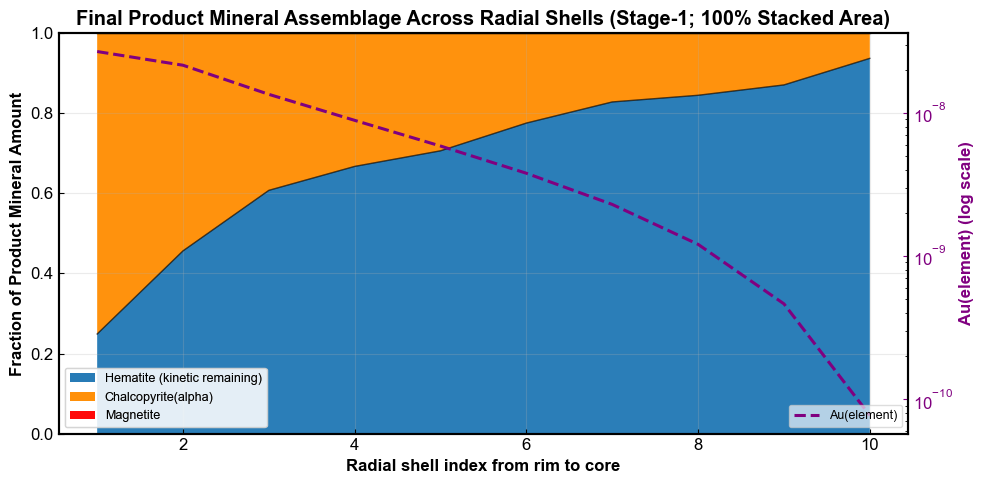

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


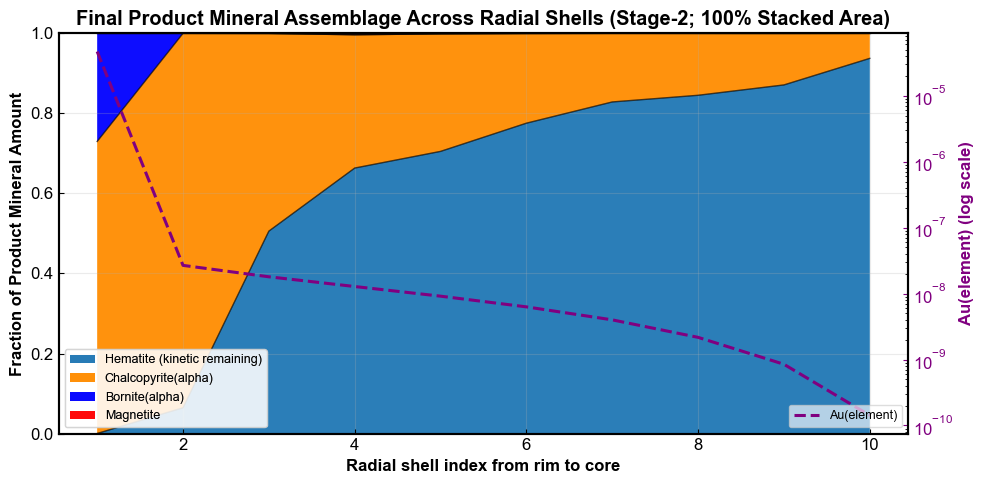

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


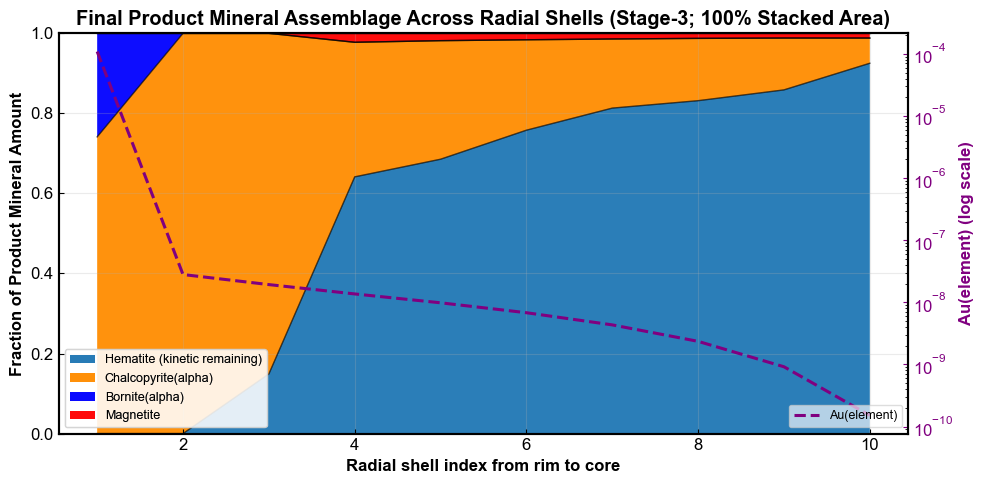

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


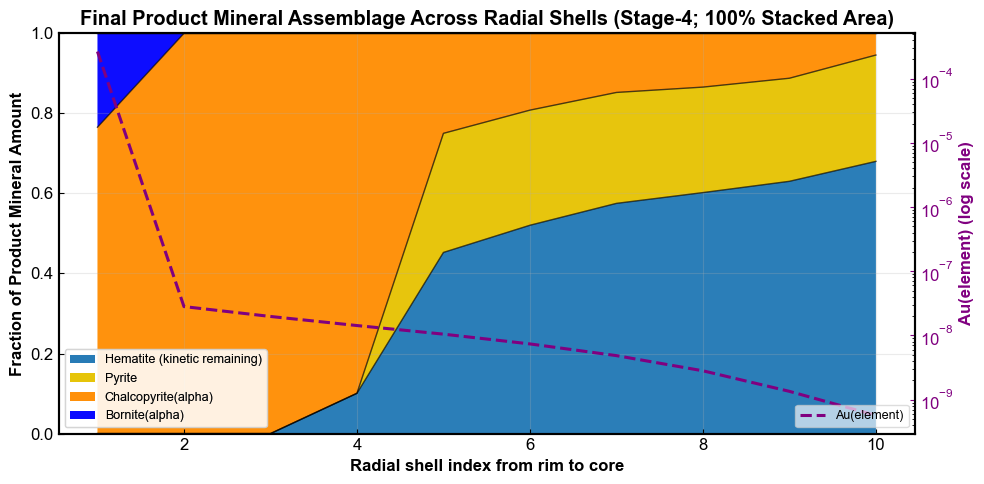

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


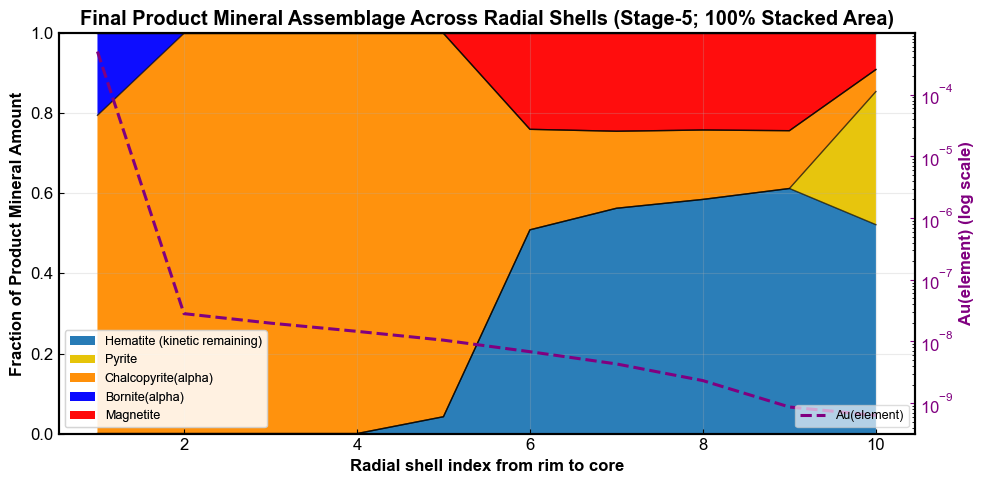

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


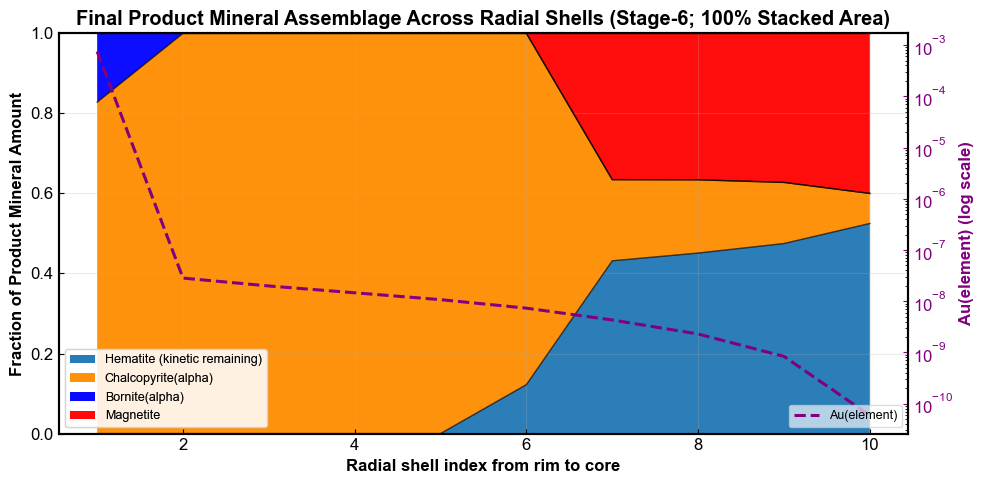

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


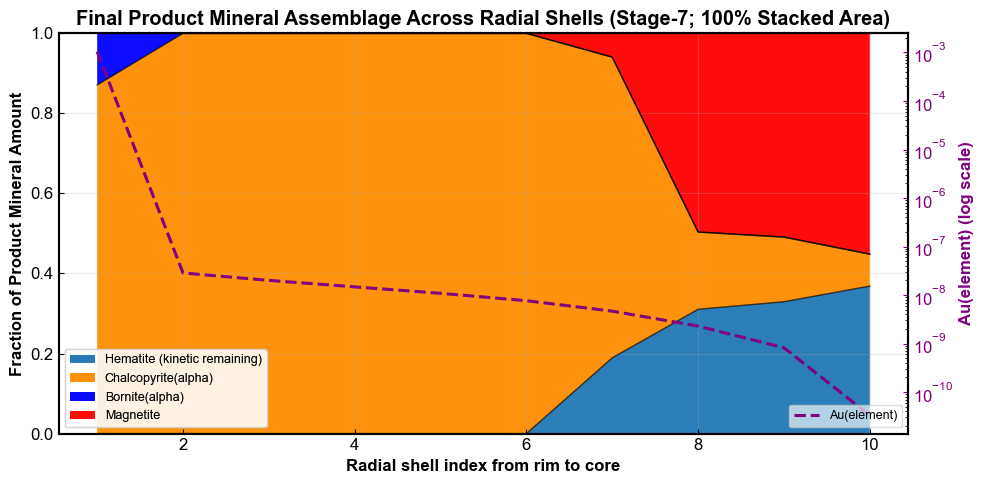

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Mineral_StackArea_Filled.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


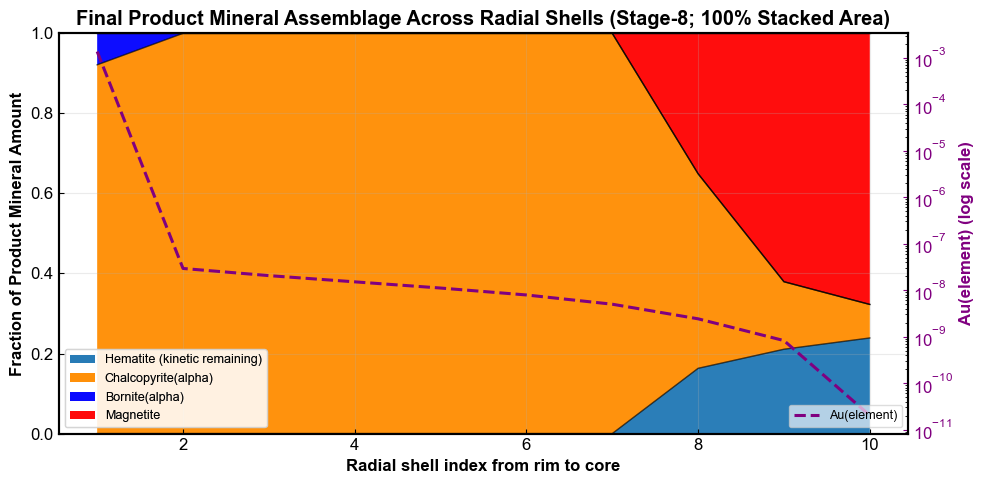

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Mineral_StackArea_Filled.png


In [552]:
# =========================================================
# 100% filled stack area (stage-separated)
# =========================================================
for meta in stage_final_frames:
    df_stage_final = meta["df_final"]
    if df_stage_final is None or len(df_stage_final) == 0:
        continue

    phase_fill_map = {}
    if "Hematite_PK_remaining" in df_stage_final.columns:
        phase_fill_map["Hematite (kinetic remaining)"] = "Hematite_PK_remaining"
    for phase in ["Pyrite", "Chalcopyrite(alpha)", "Bornite(alpha)", "Magnetite", "Chalcocite(alpha)", "Cu(element)"]:
        if phase in df_stage_final.columns:
            phase_fill_map[phase] = phase

    stage_slug = re.sub(r"[^A-Za-z0-9]+", "_", meta["stage_label"]).strip("_")
    plot_filled_stack_area(
        df_stage_final,
        phase_fill_map,
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Mineral_StackArea_Filled.png",
        f"Final Product Mineral Assemblage Across Radial Shells ({meta['stage_label']}; 100% Stacked Area)",
        "Fraction of Product Mineral Amount",
        au_col="Au(element)"
    )


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


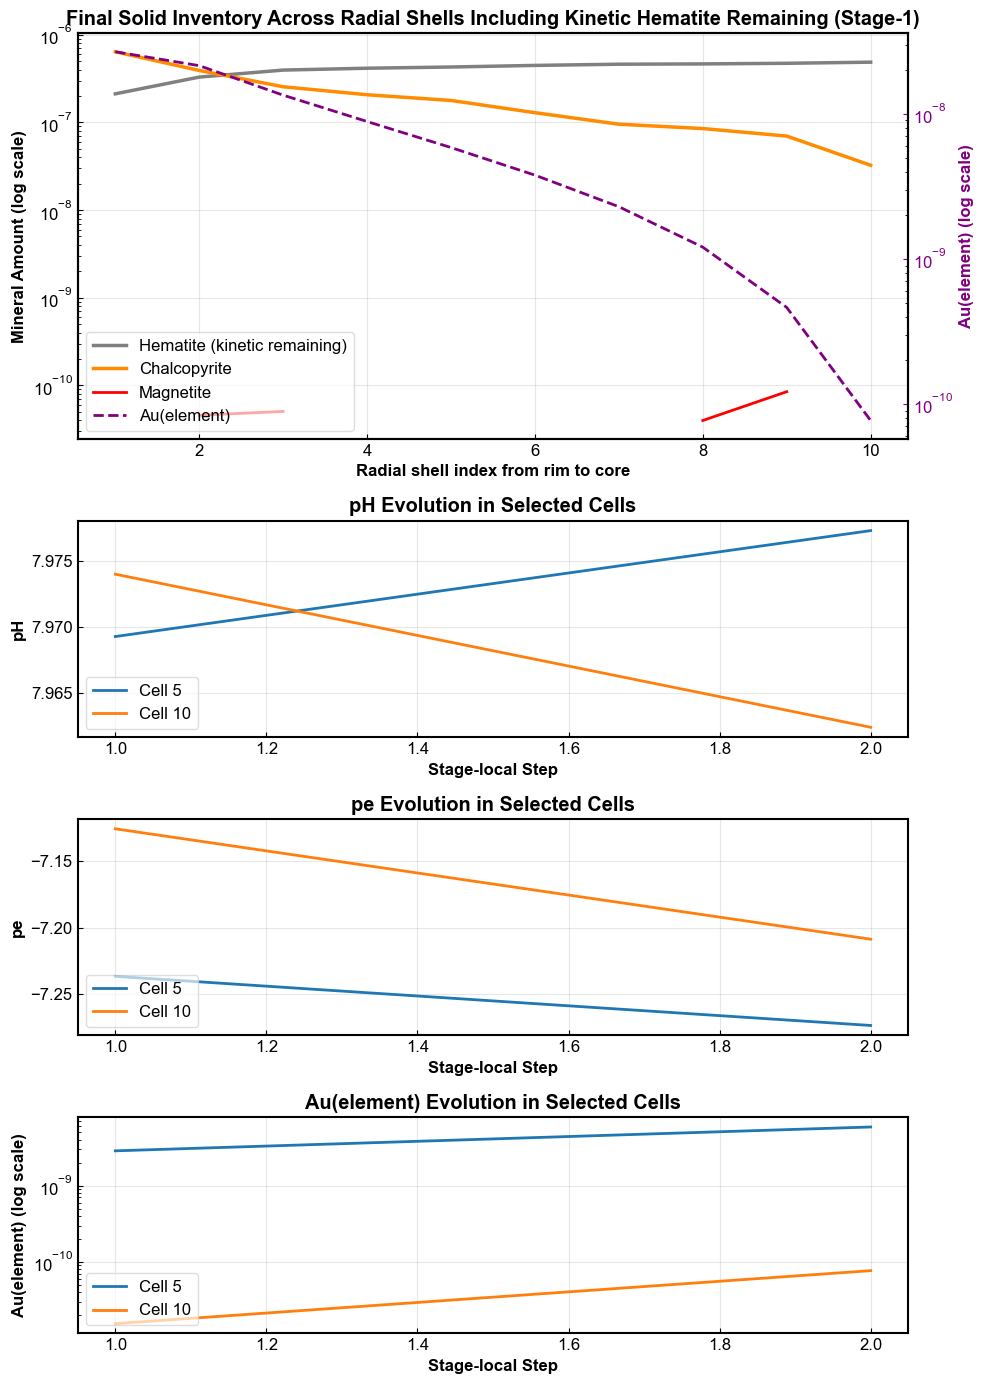

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


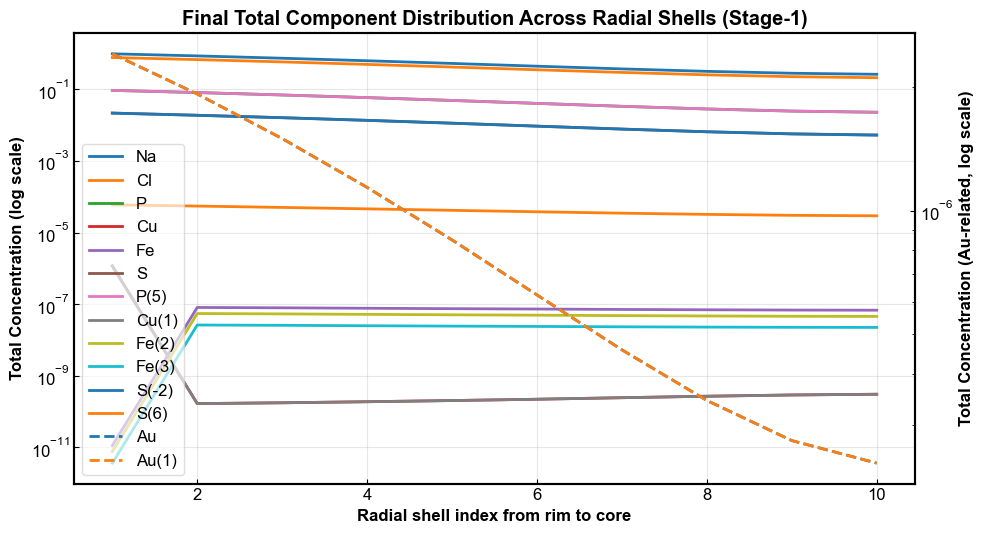

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


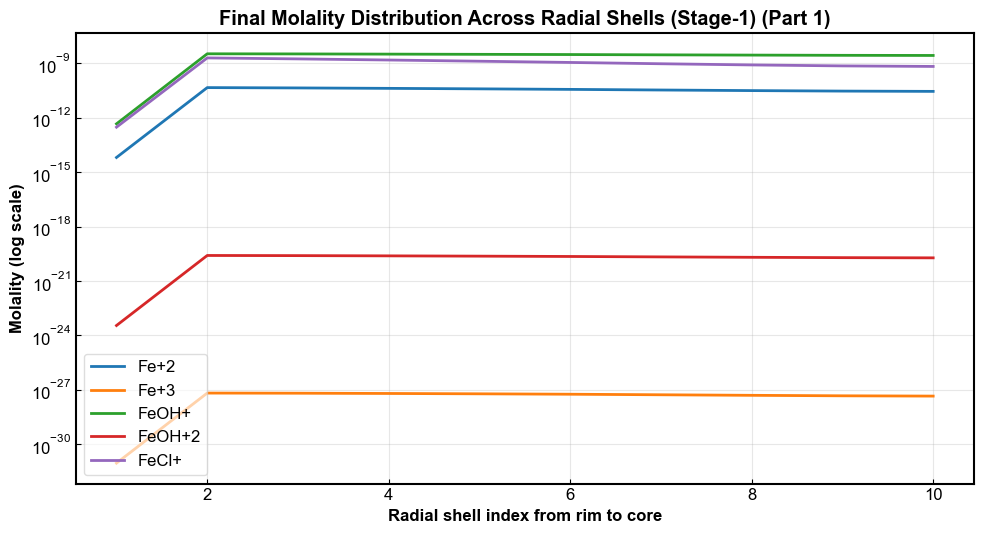

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


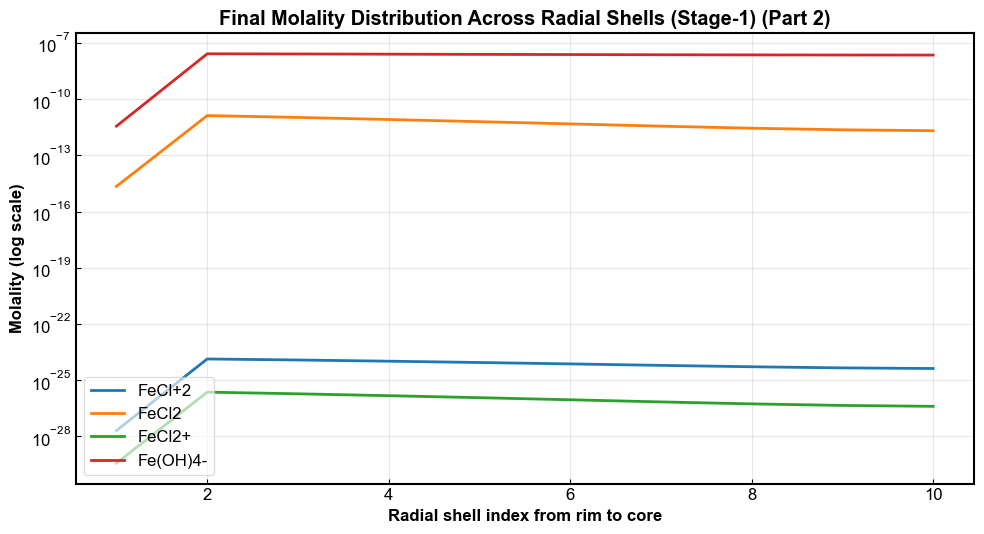

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


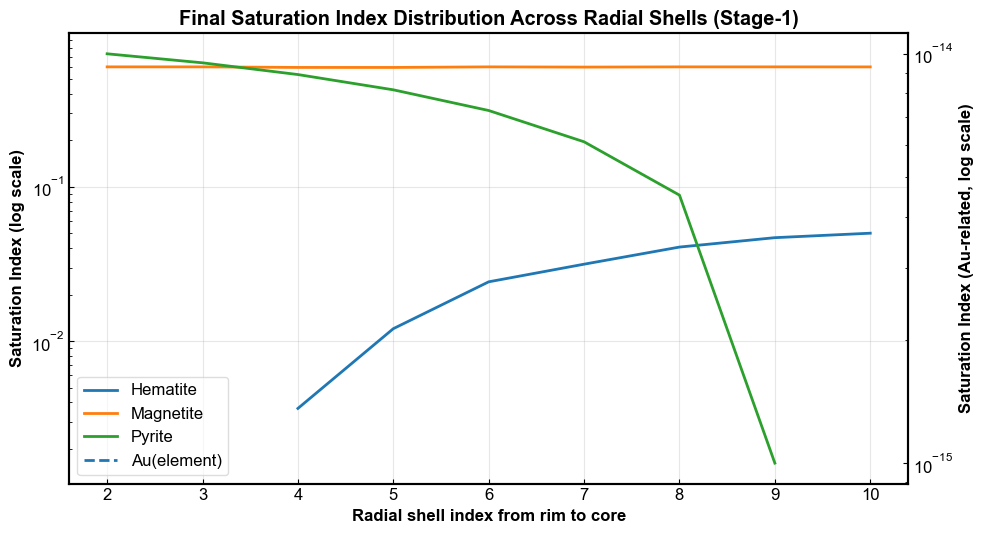

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


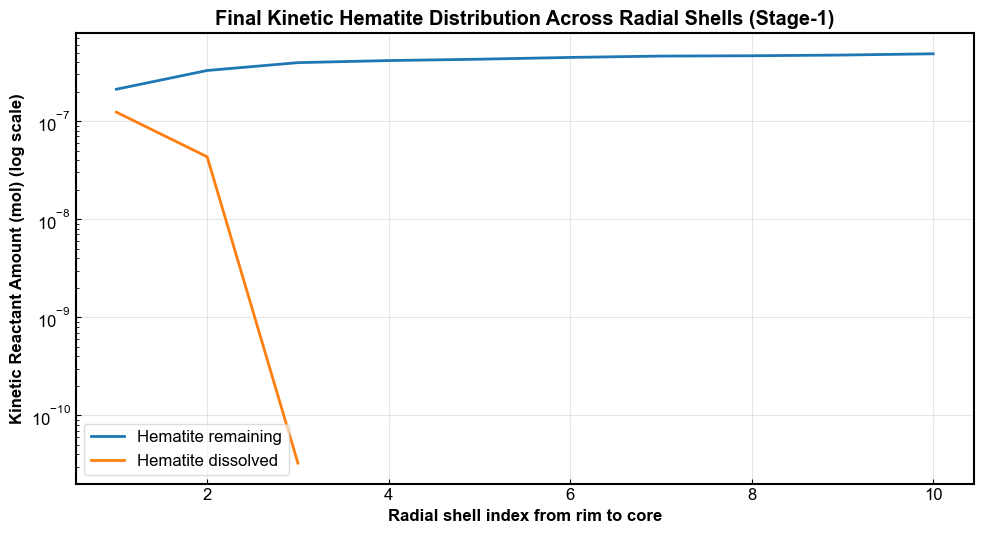

C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_HematitePK_AcrossCells.png


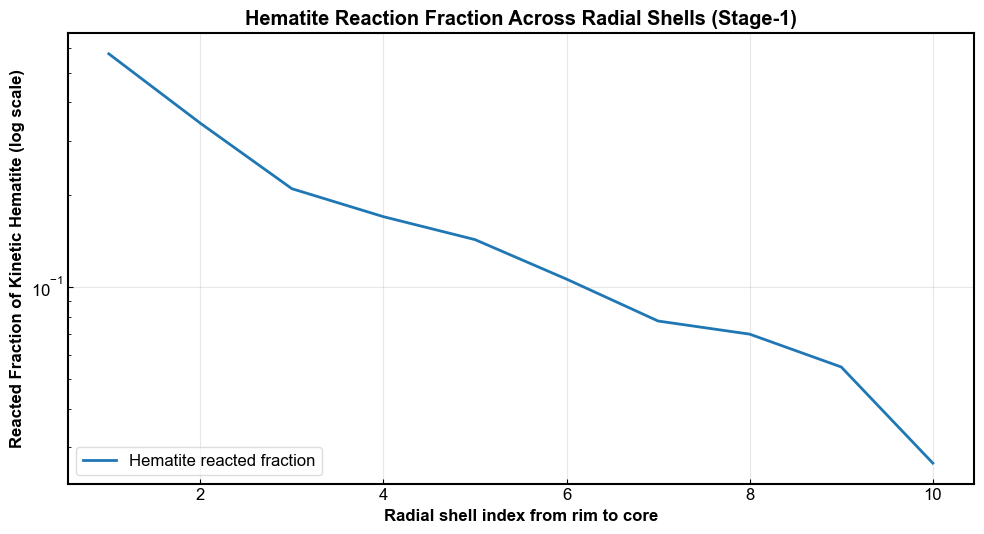

>>> Figure displayed inline : CFAS_Stage01_Stage_1_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


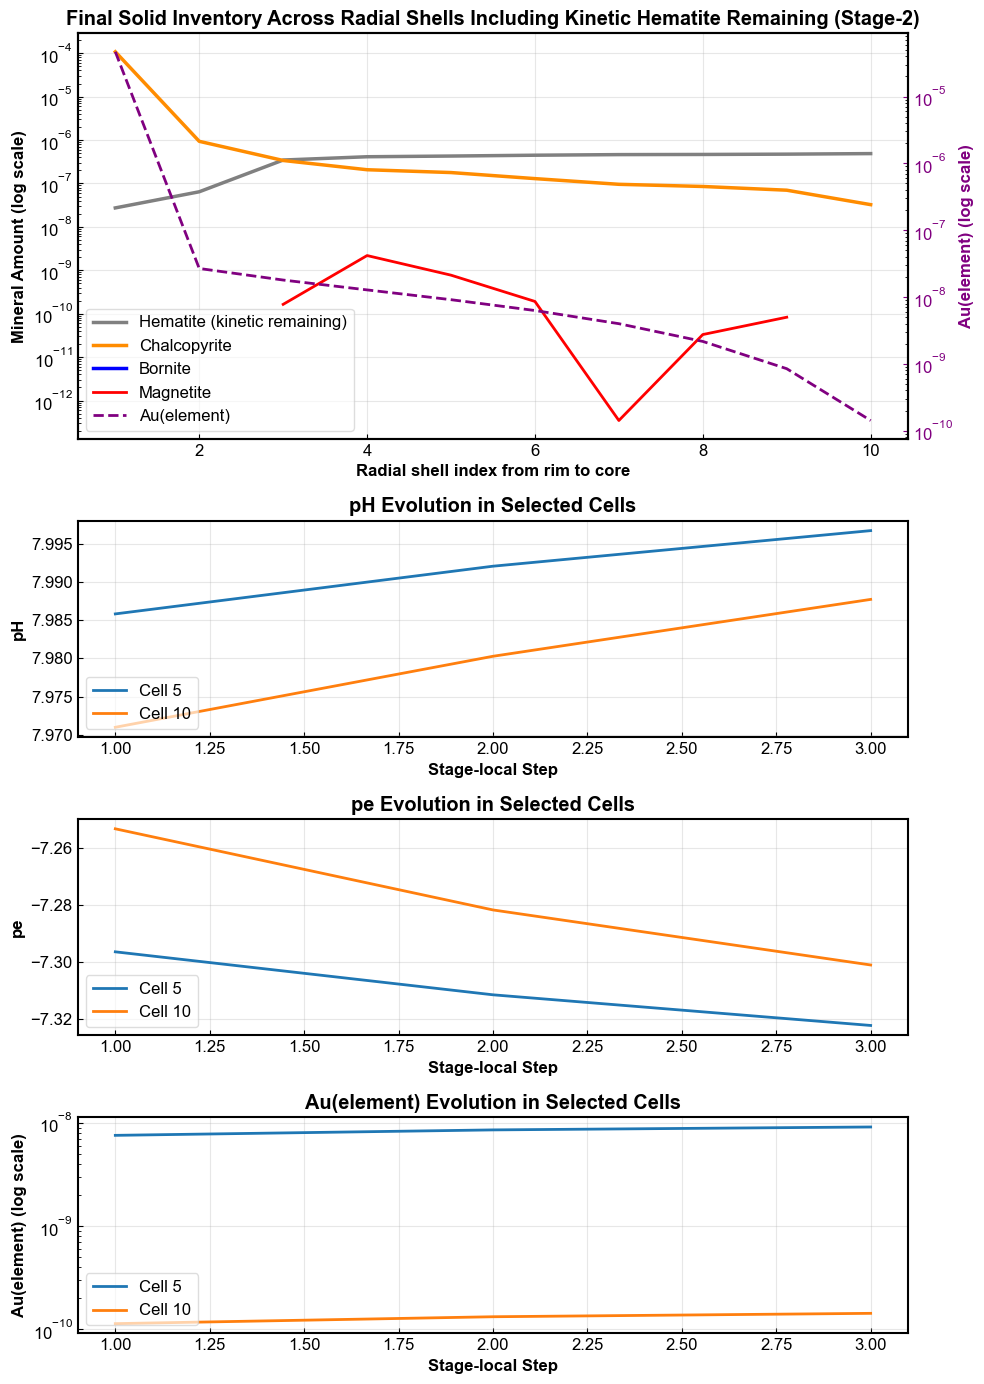

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


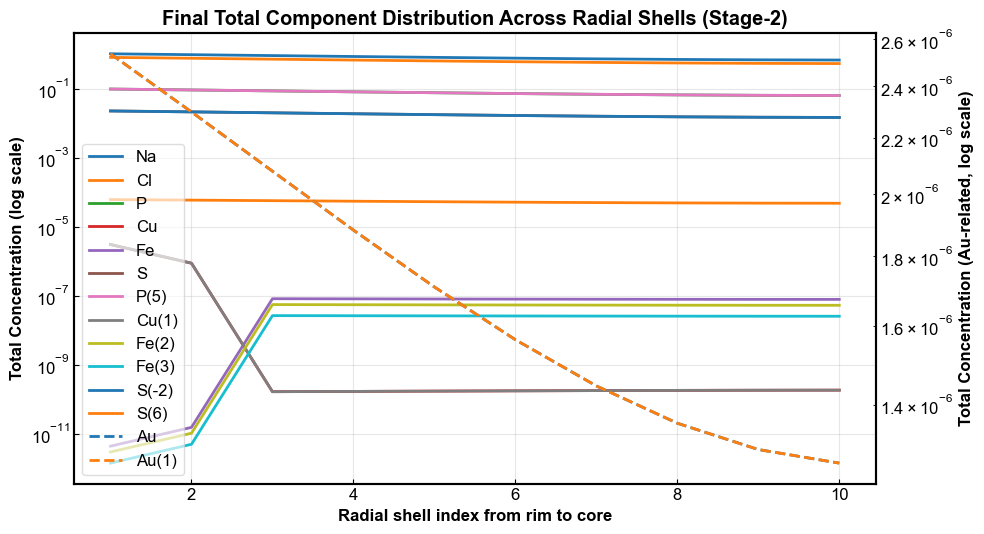

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


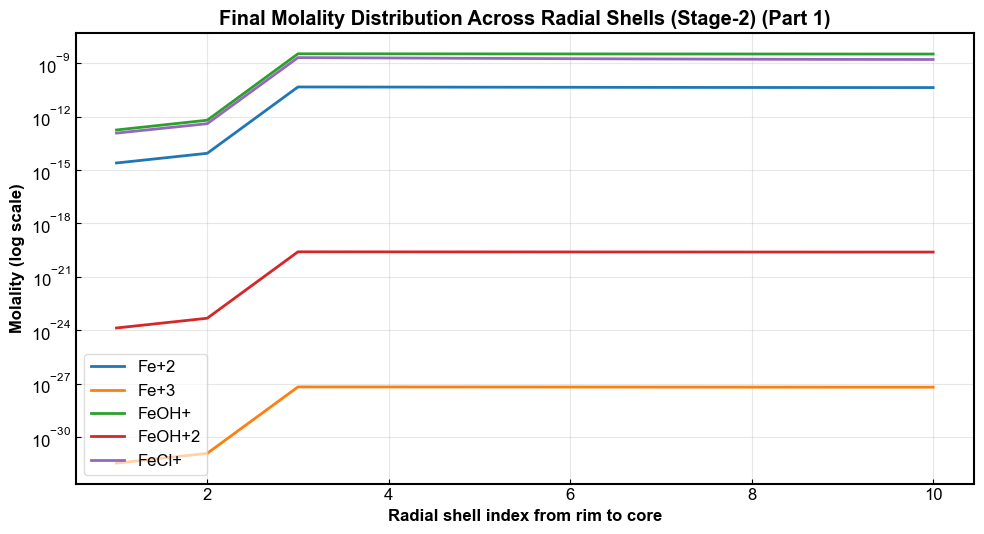

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


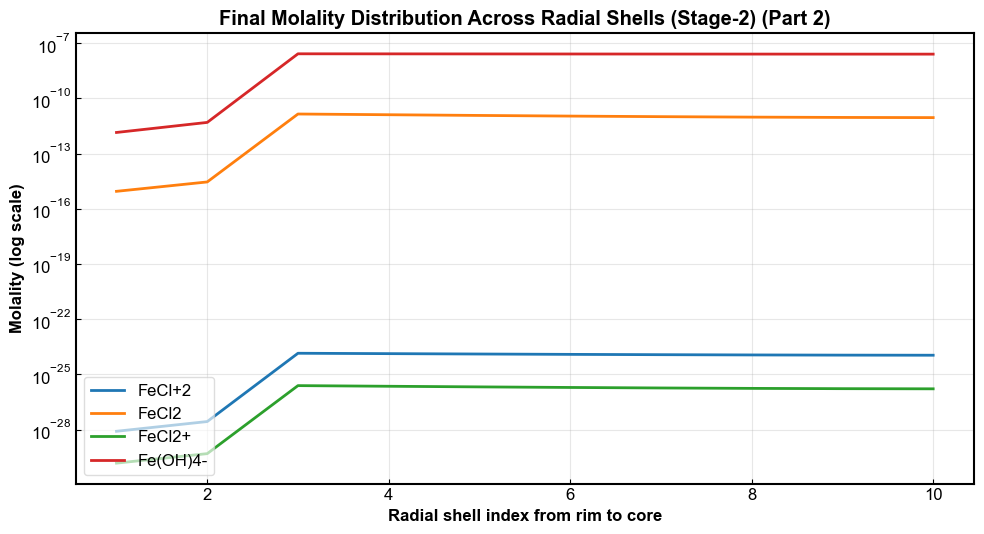

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


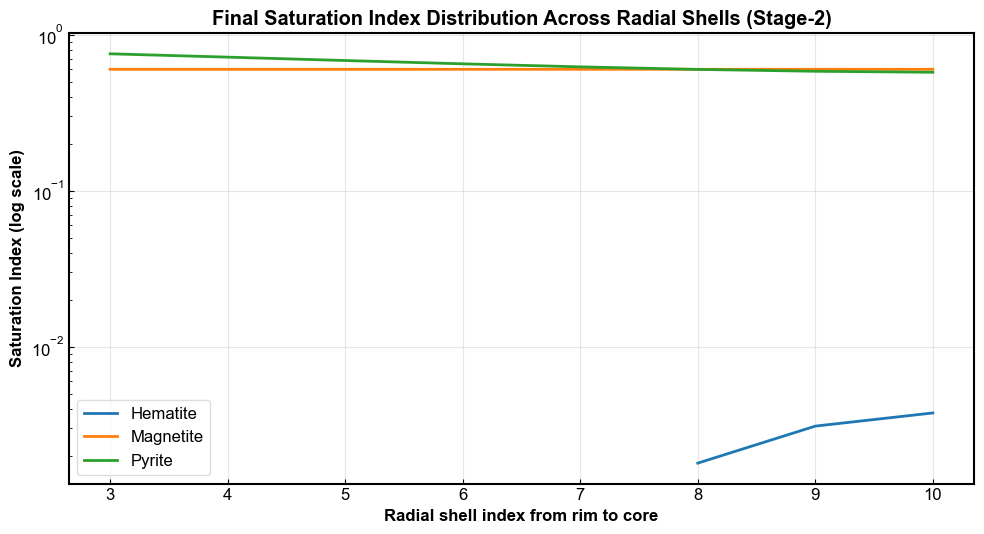

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


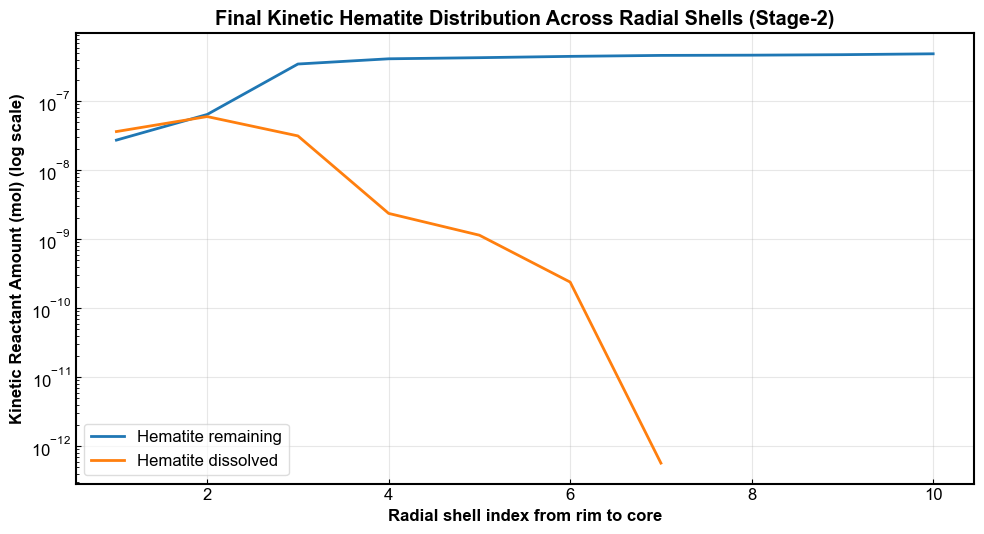

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_HematitePK_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


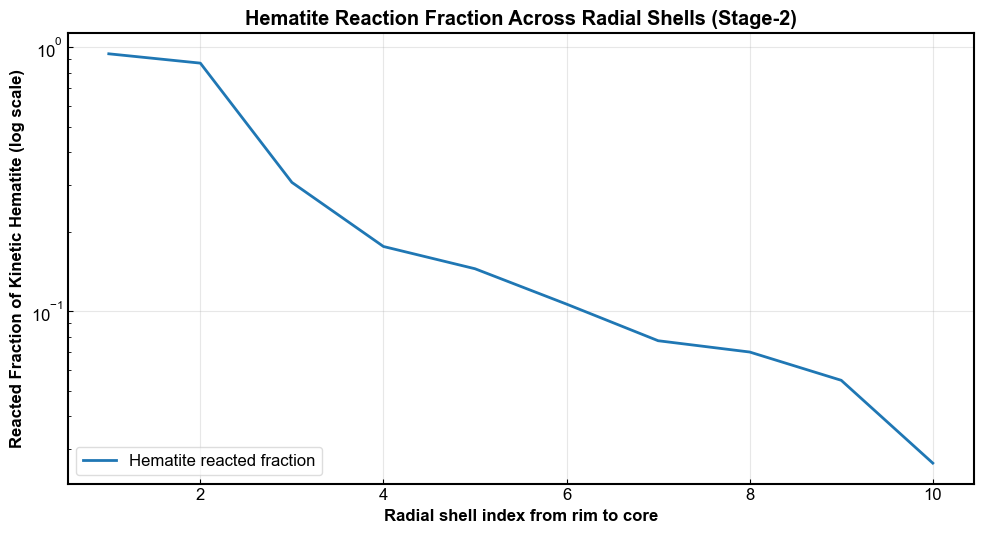

>>> Figure displayed inline : CFAS_Stage02_Stage_2_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


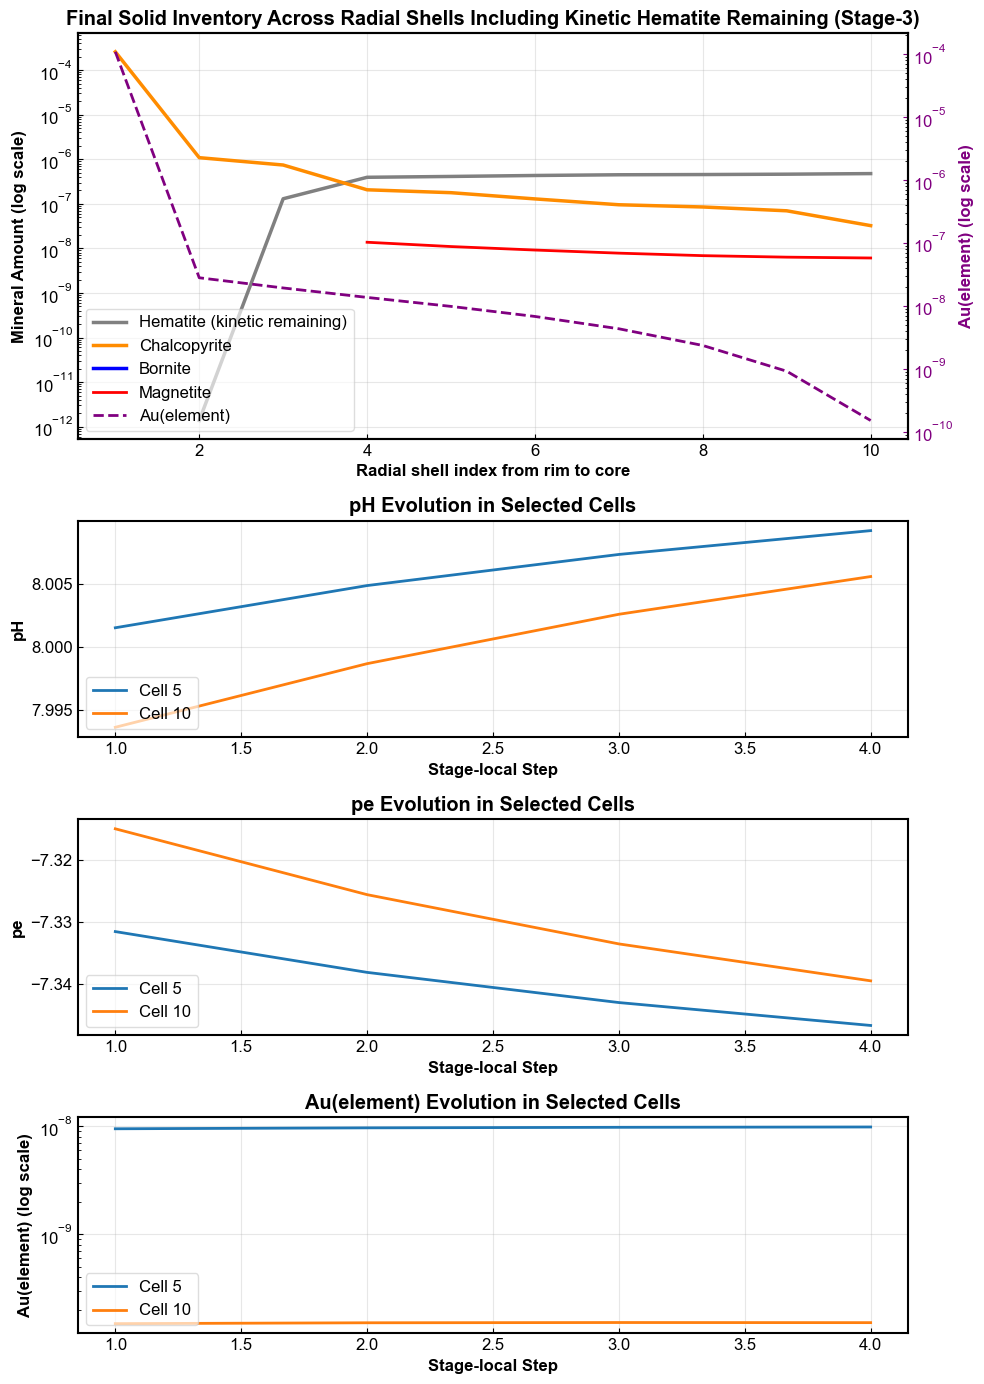

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


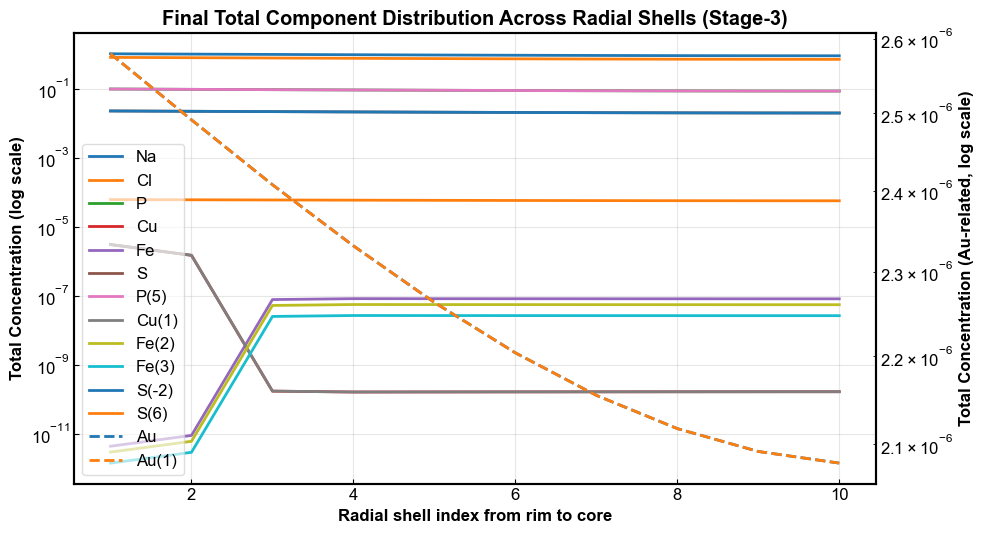

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


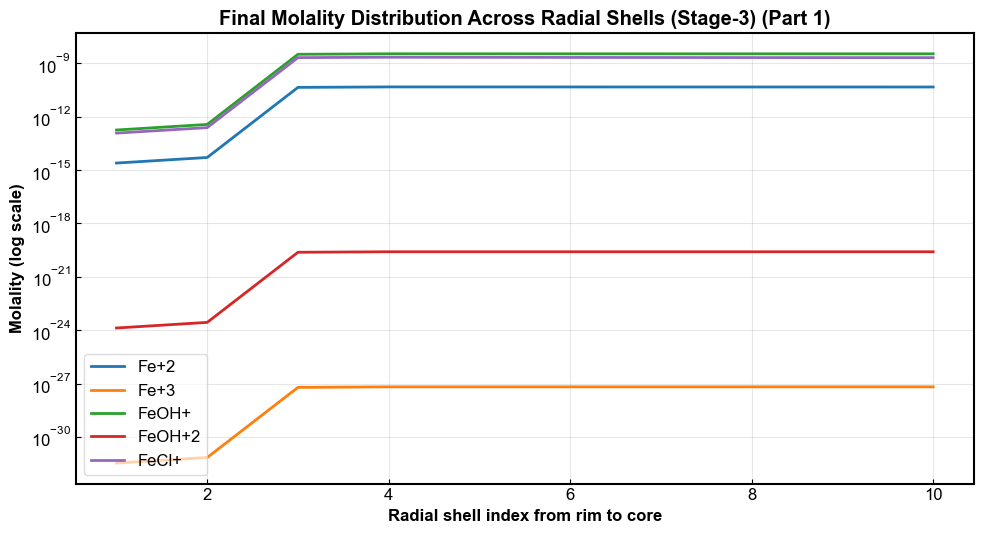

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


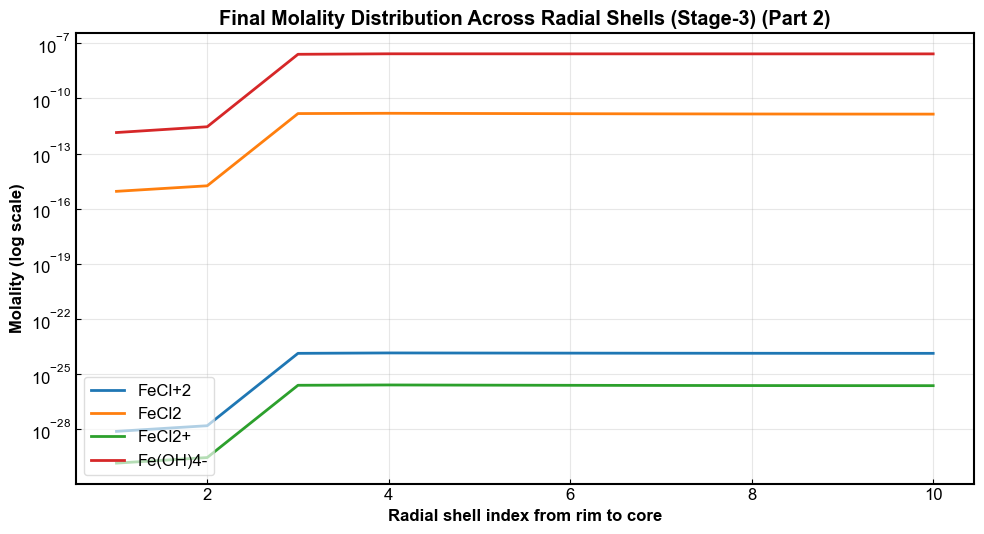

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


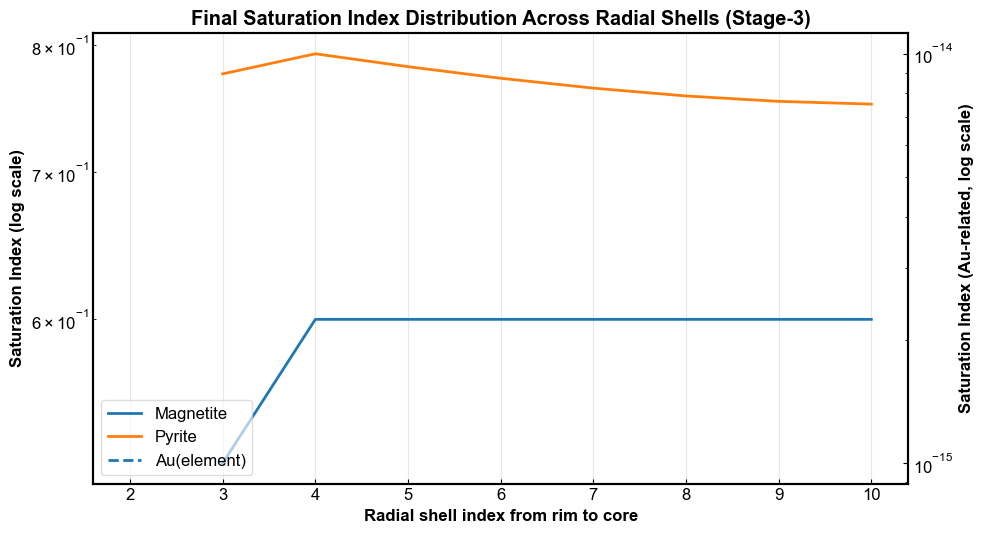

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


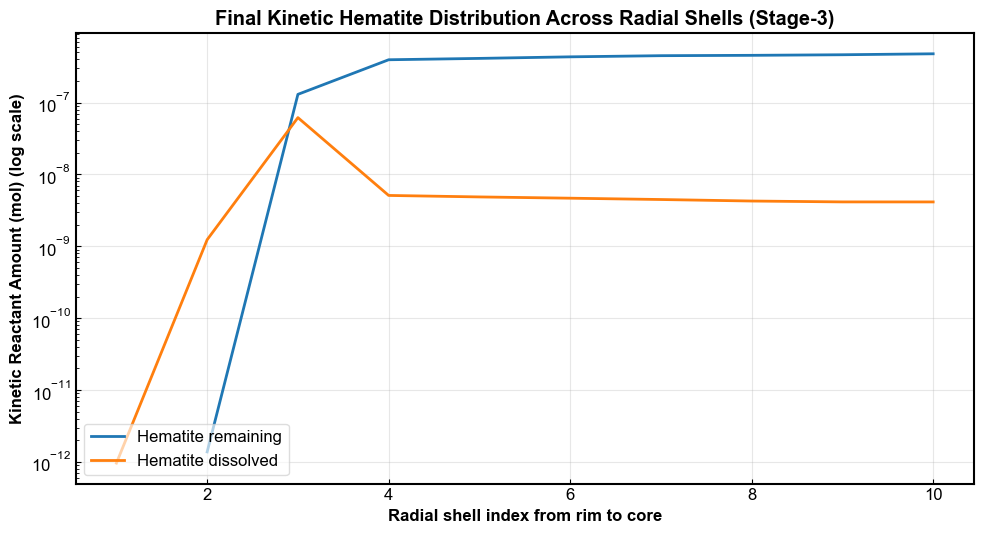

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_HematitePK_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


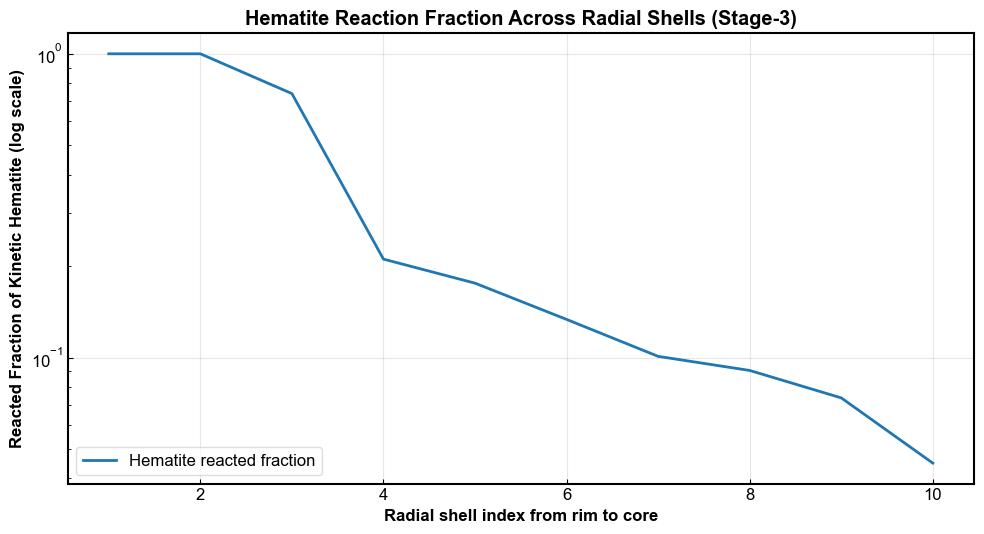

>>> Figure displayed inline : CFAS_Stage03_Stage_3_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


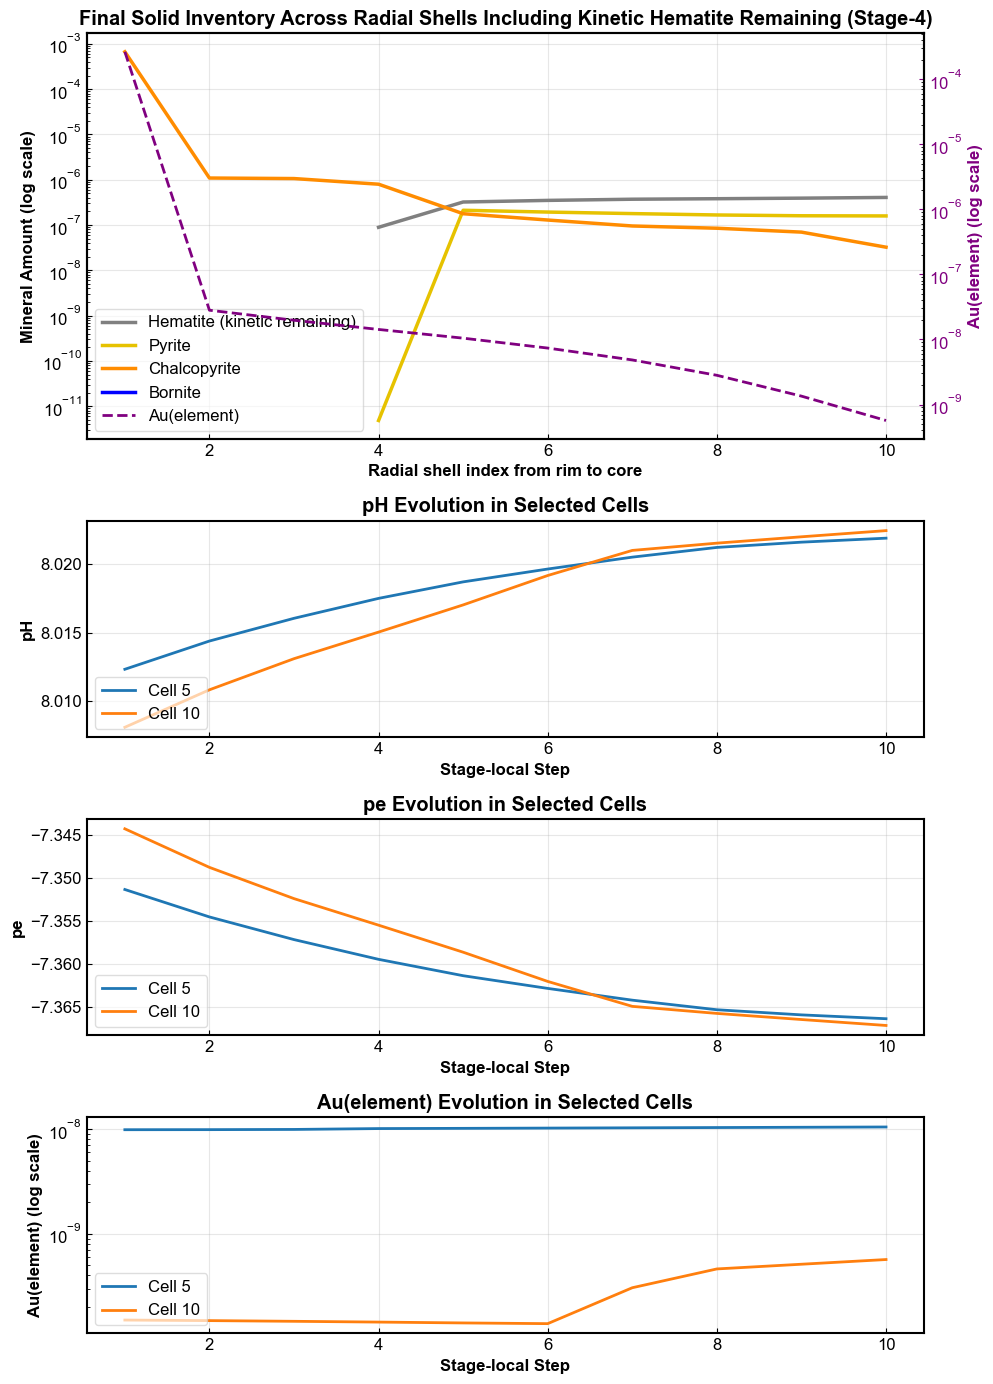

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


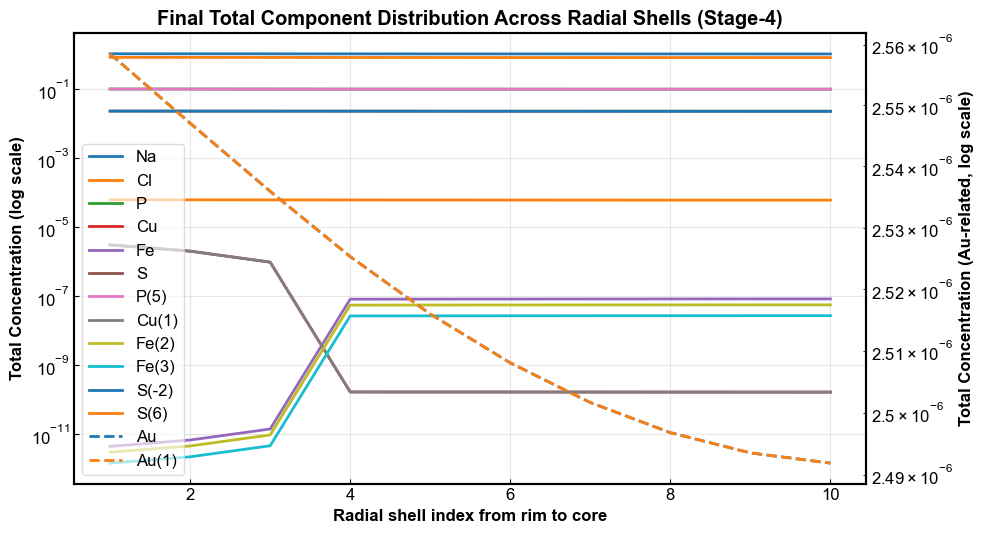

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


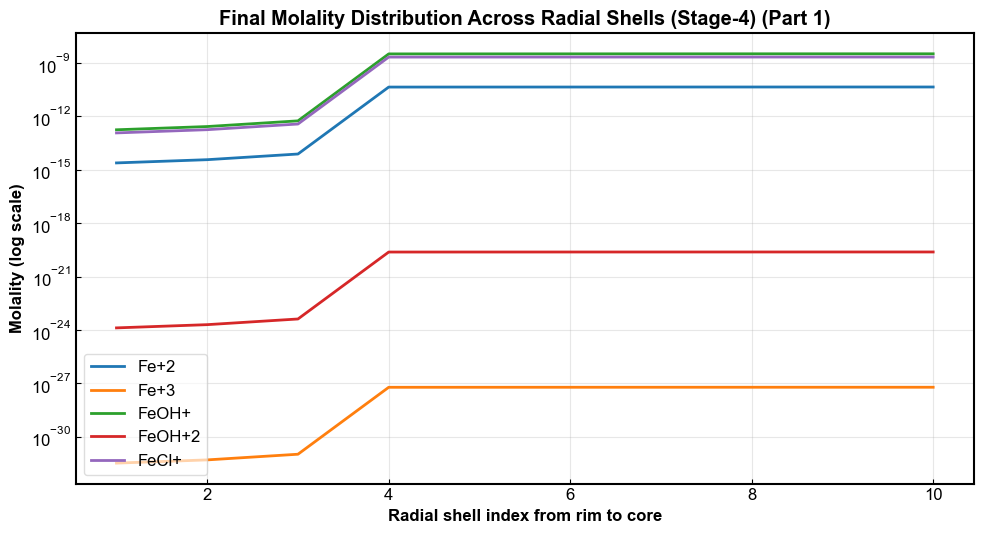

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


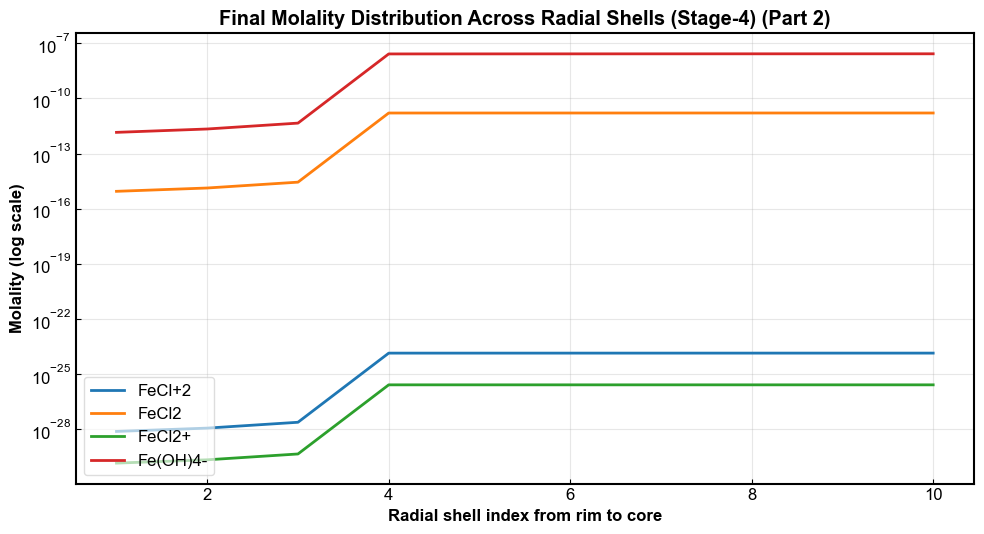

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


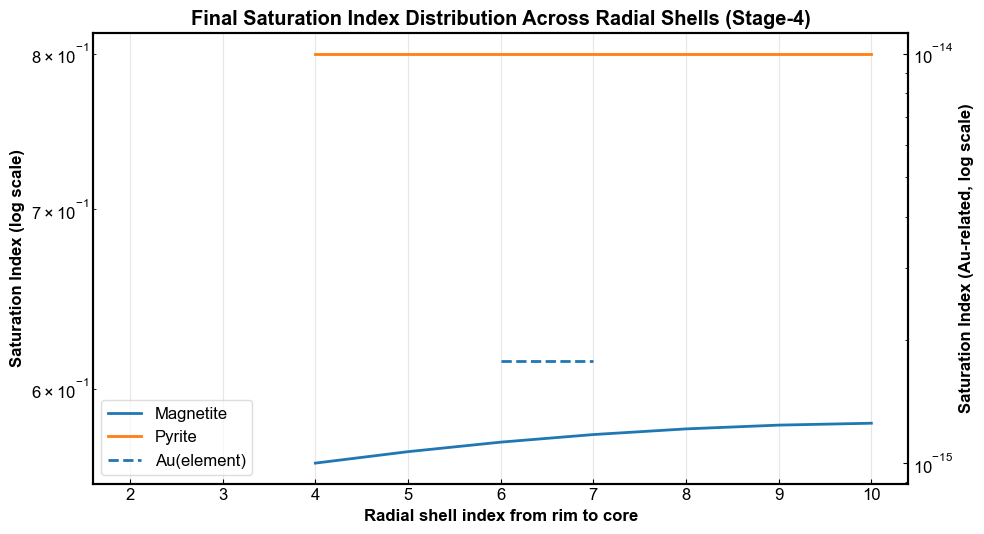

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


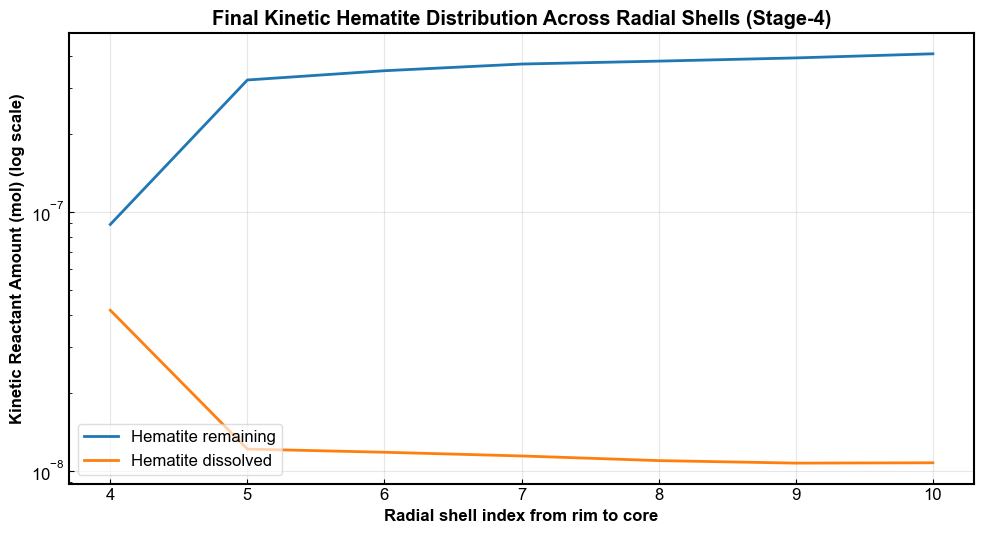

C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_HematitePK_AcrossCells.png


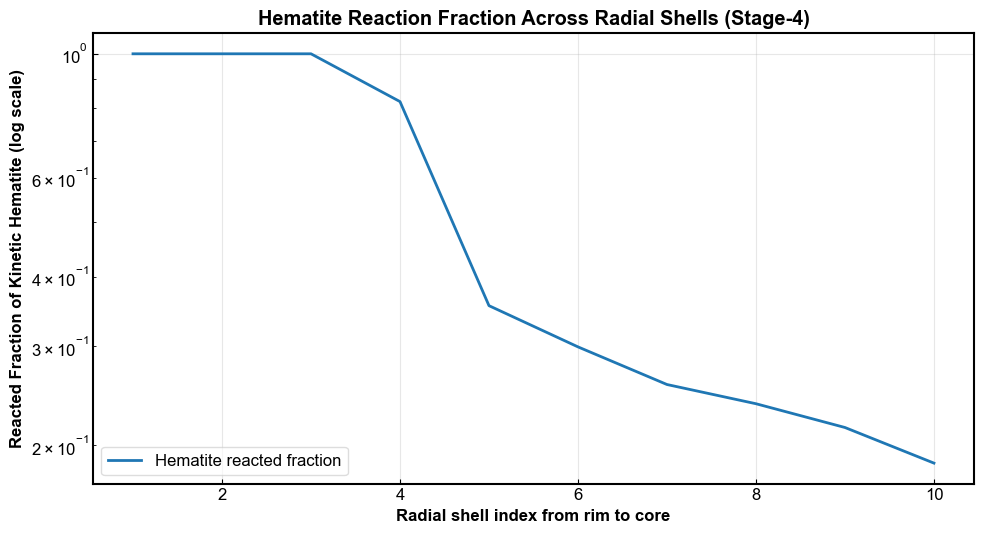

>>> Figure displayed inline : CFAS_Stage04_Stage_4_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


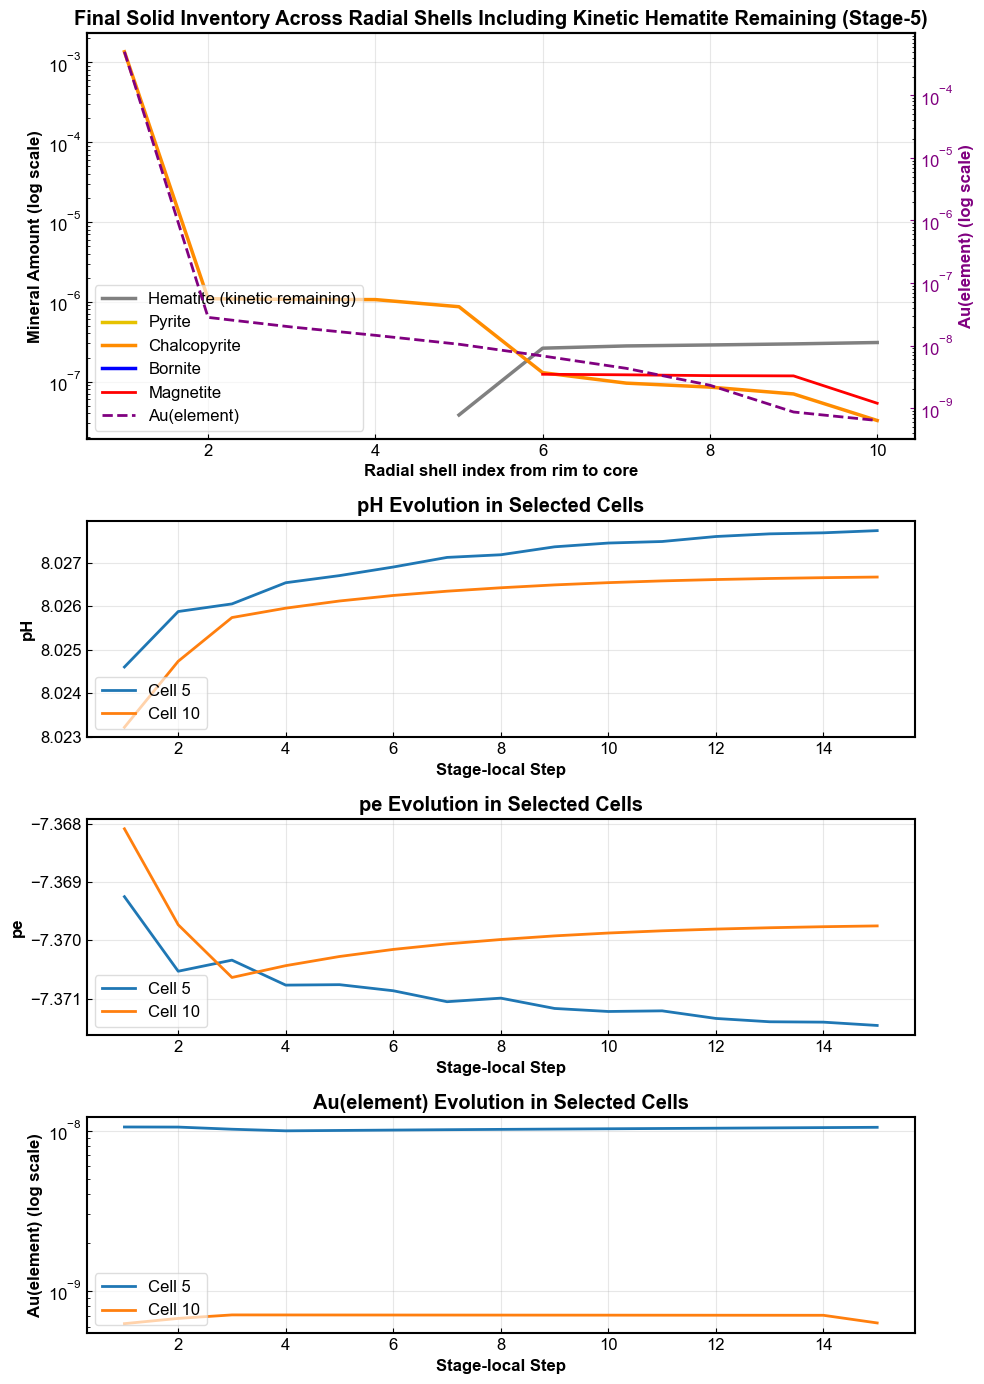

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


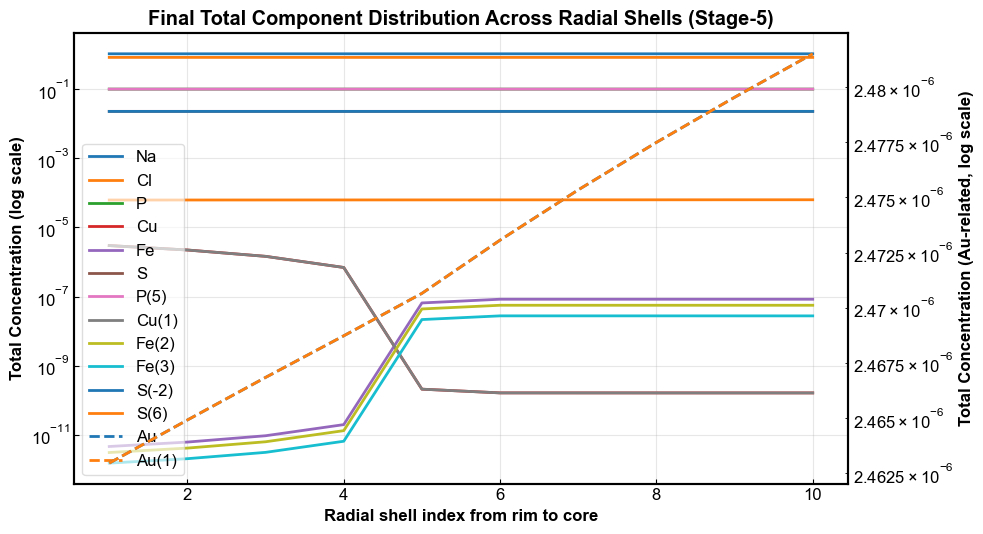

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


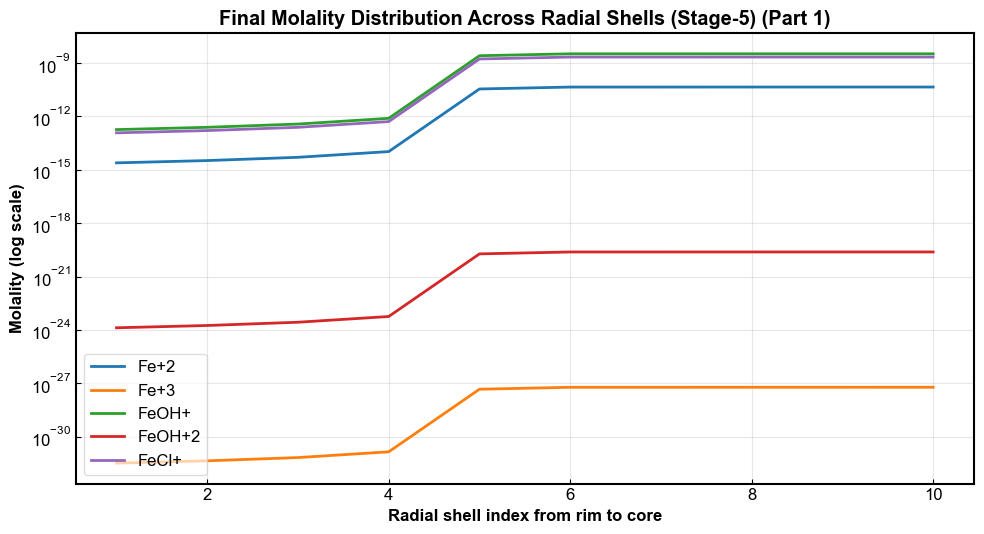

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


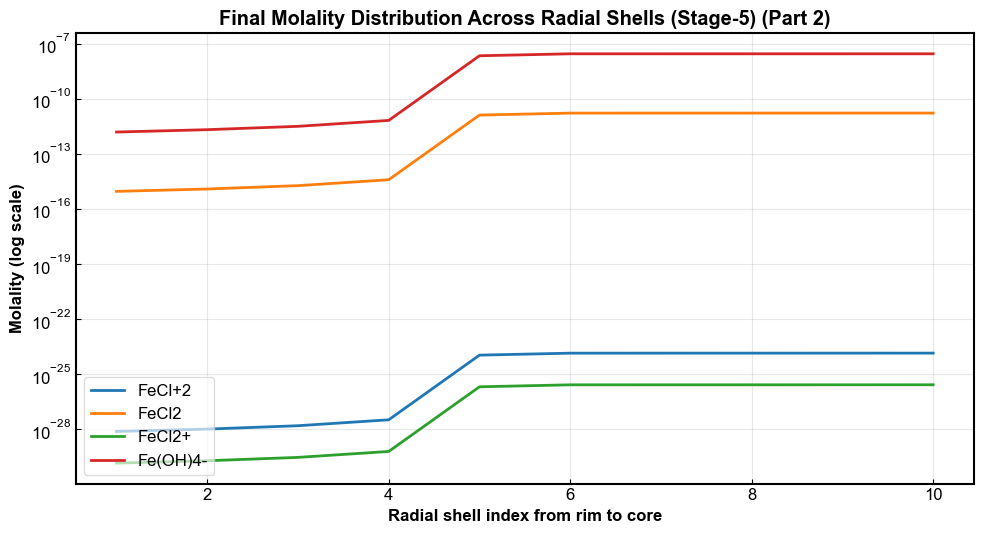

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


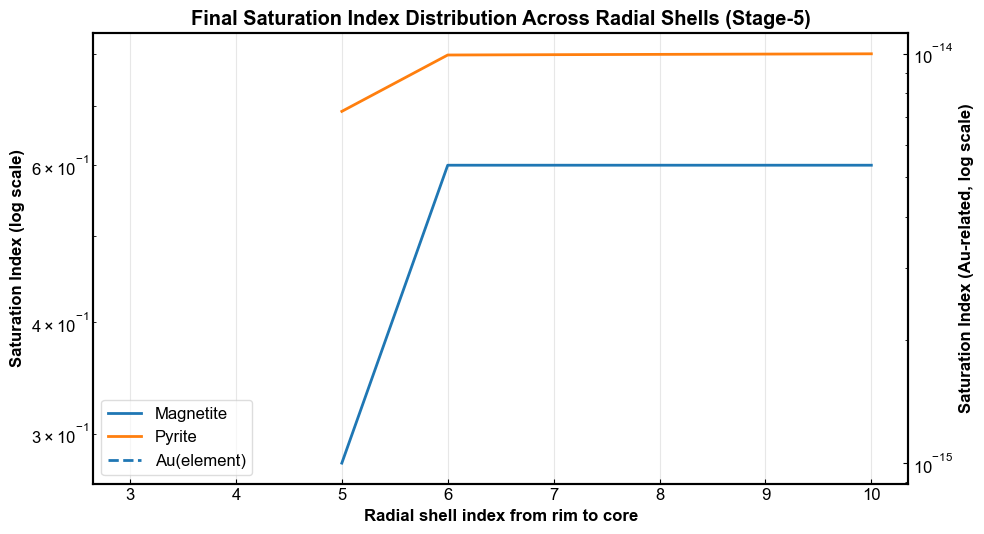

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


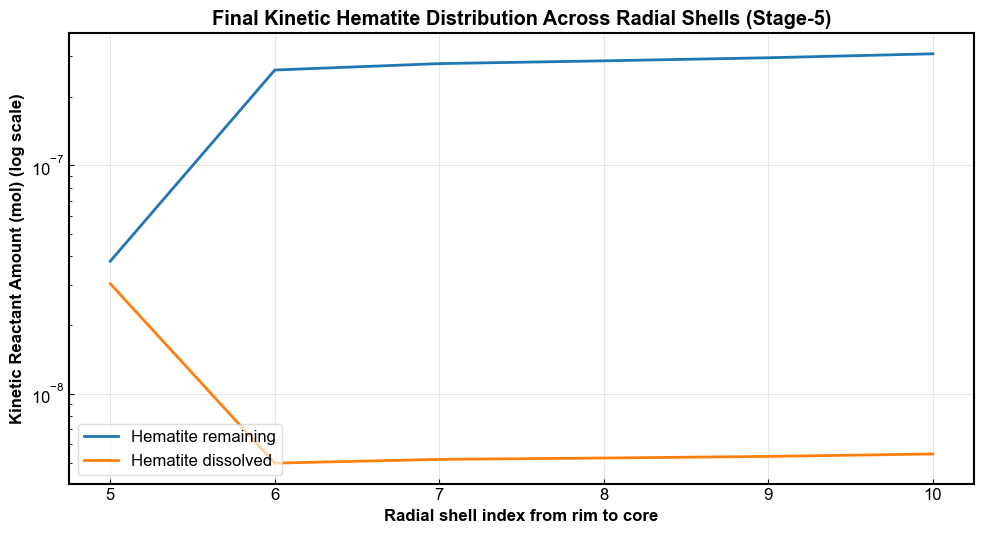

C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_HematitePK_AcrossCells.png


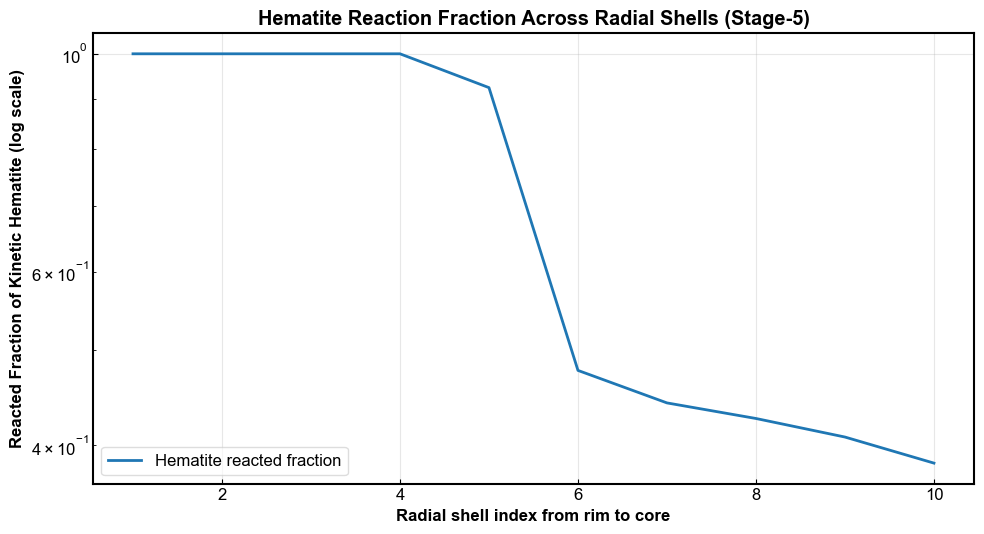

>>> Figure displayed inline : CFAS_Stage05_Stage_5_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


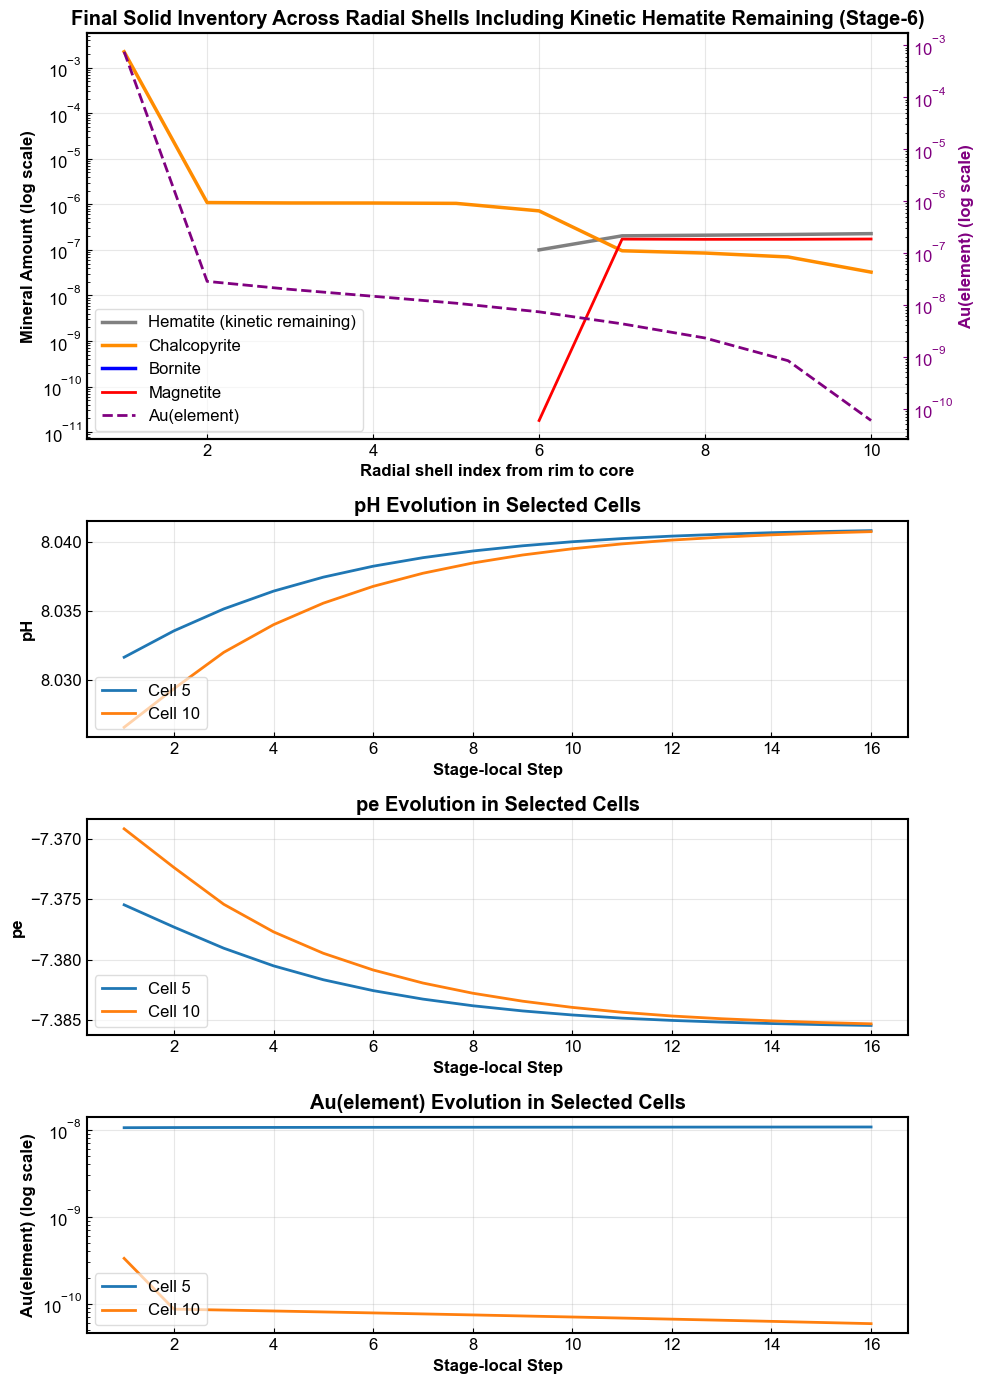

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


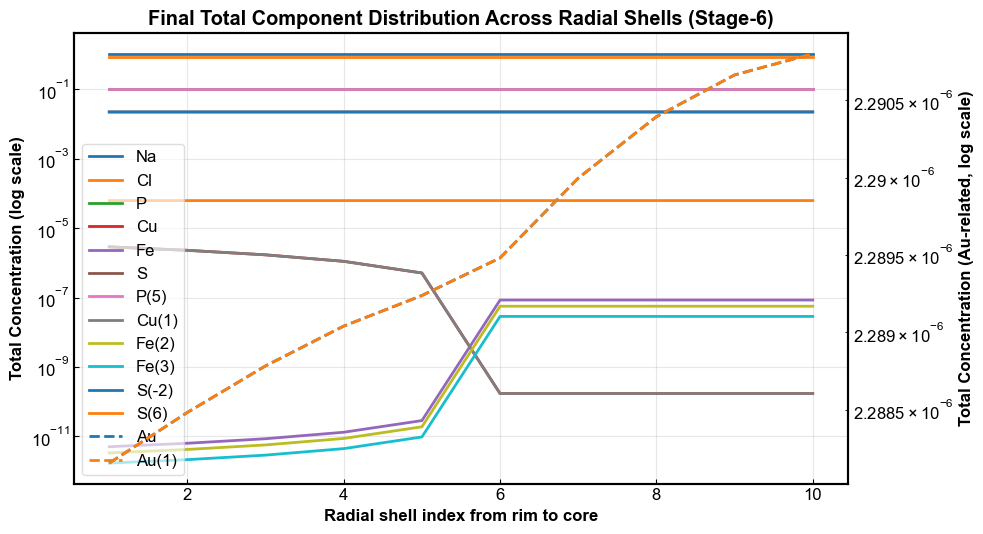

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


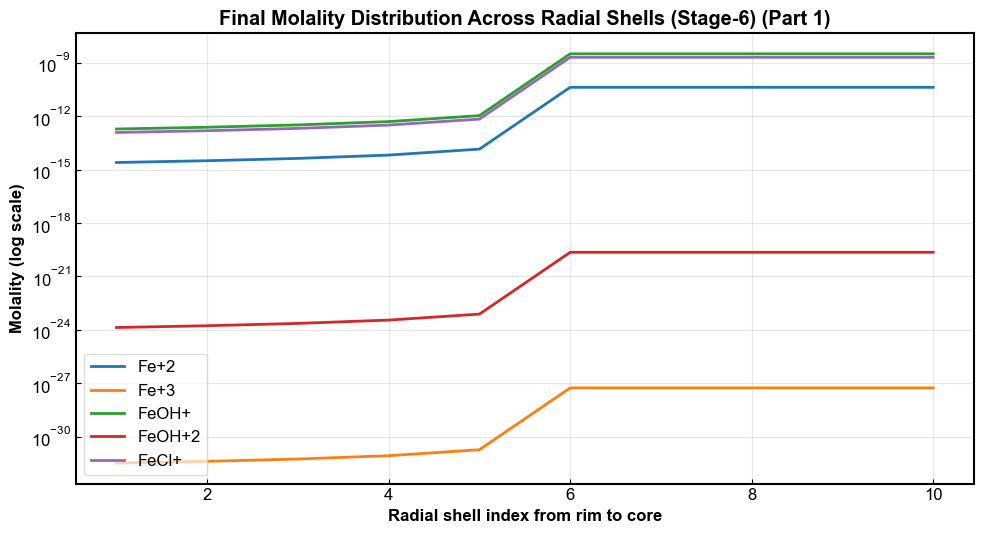

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


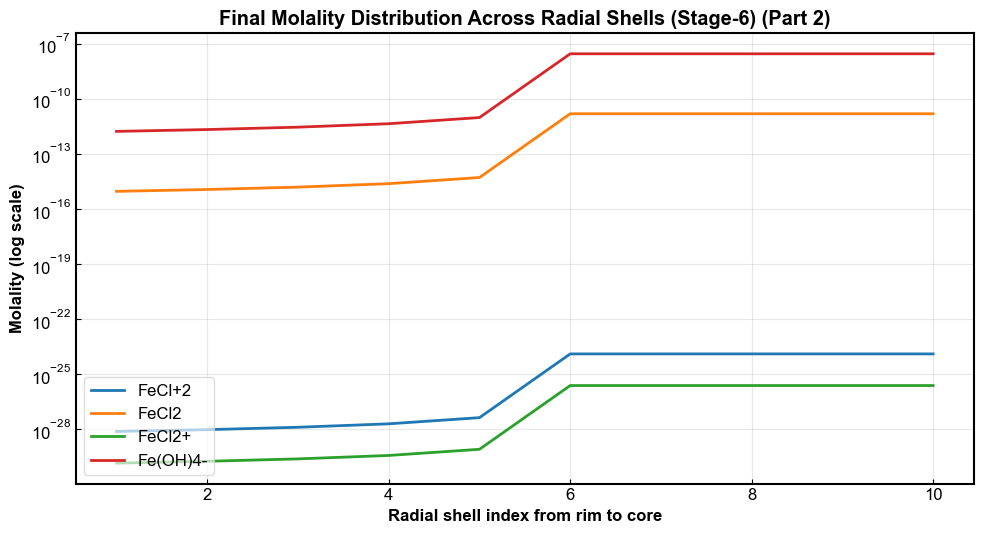

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


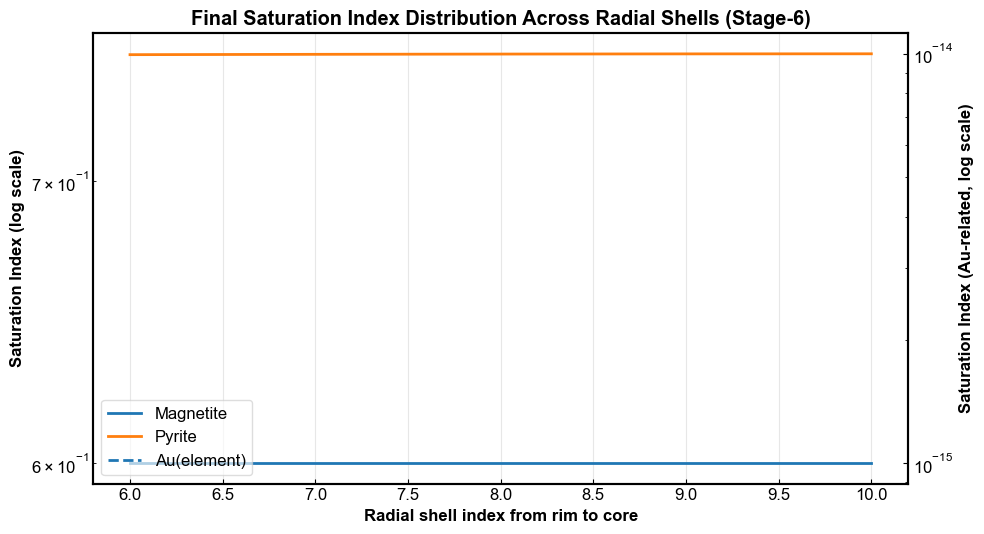

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


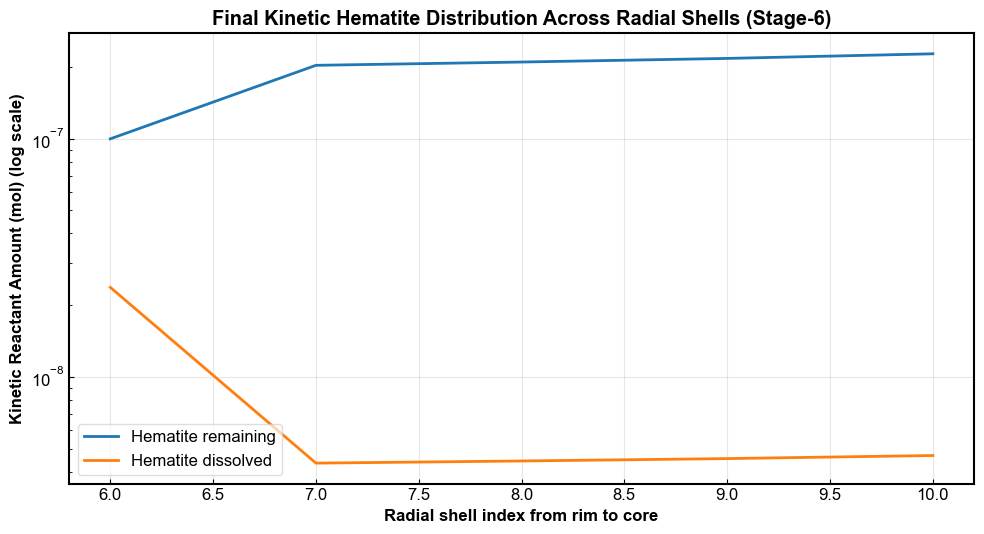

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_HematitePK_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


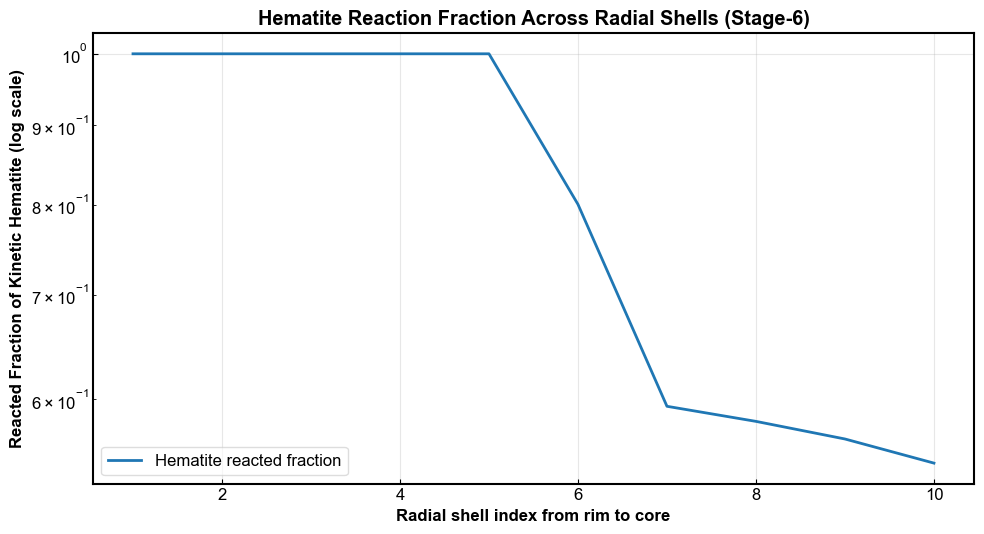

>>> Figure displayed inline : CFAS_Stage06_Stage_6_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


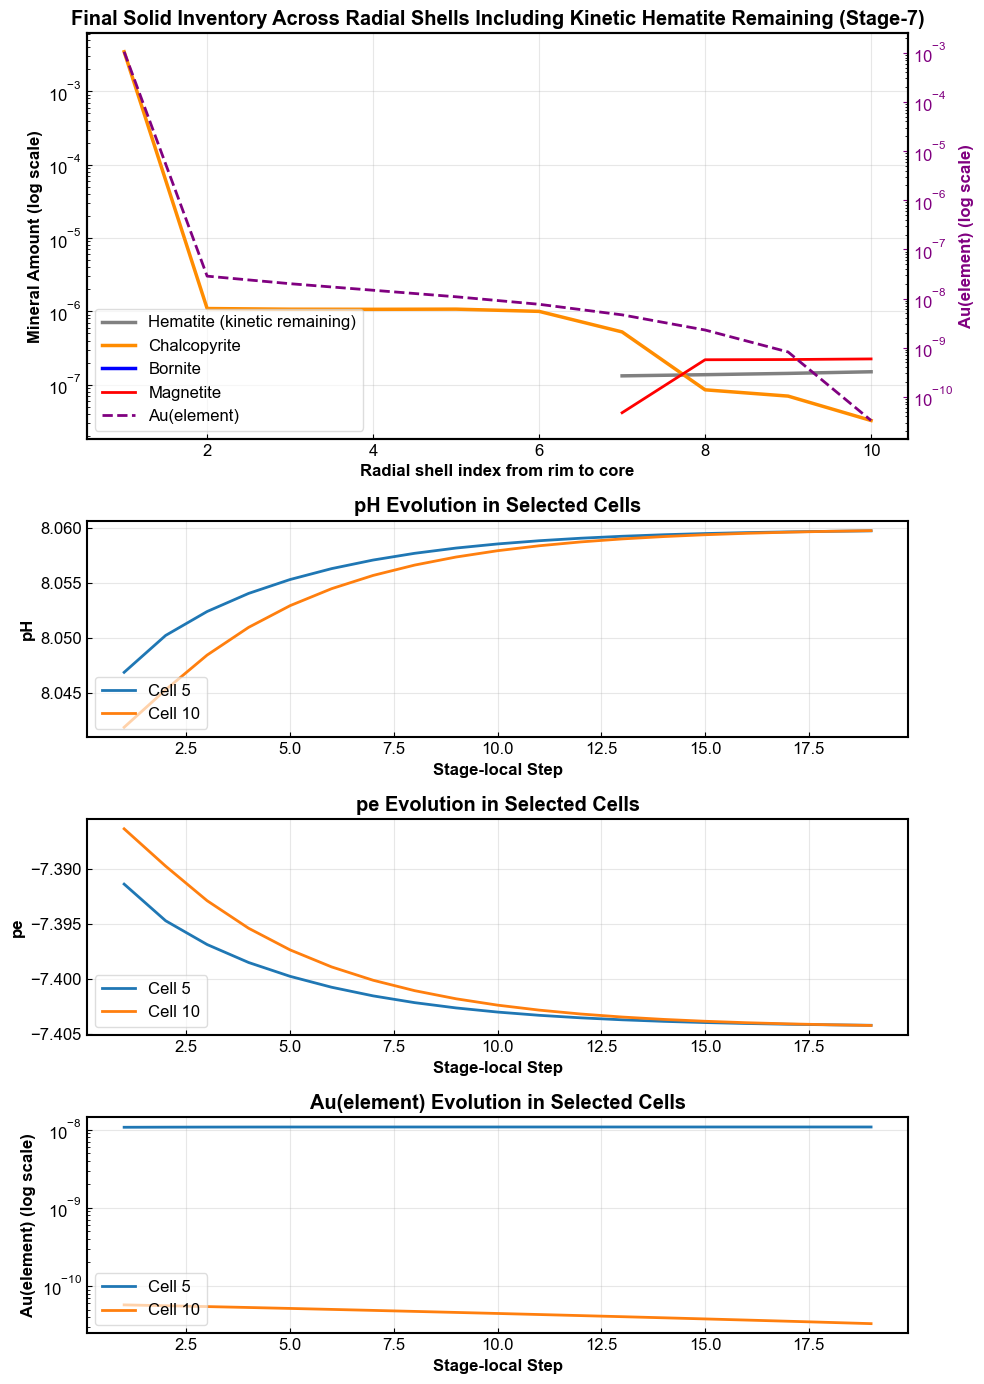

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


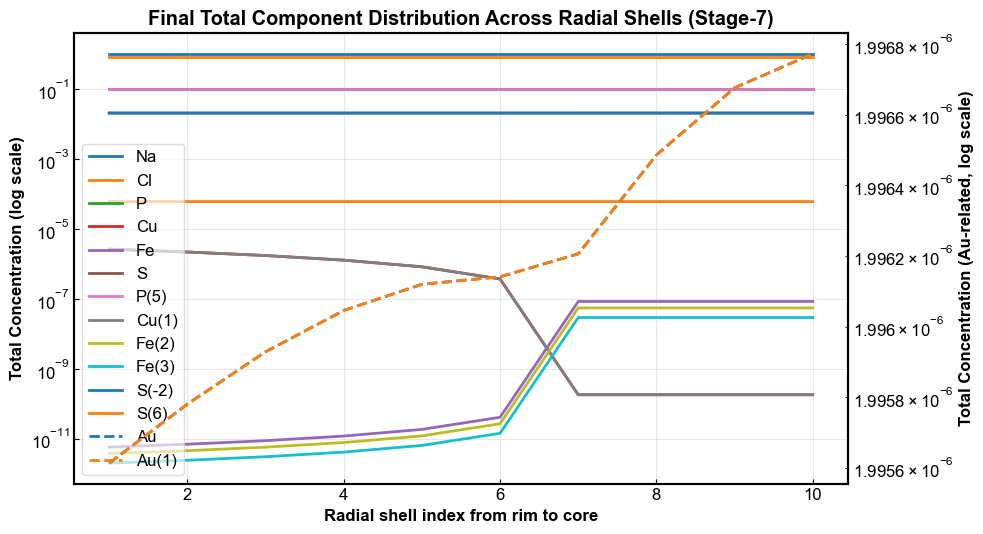

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


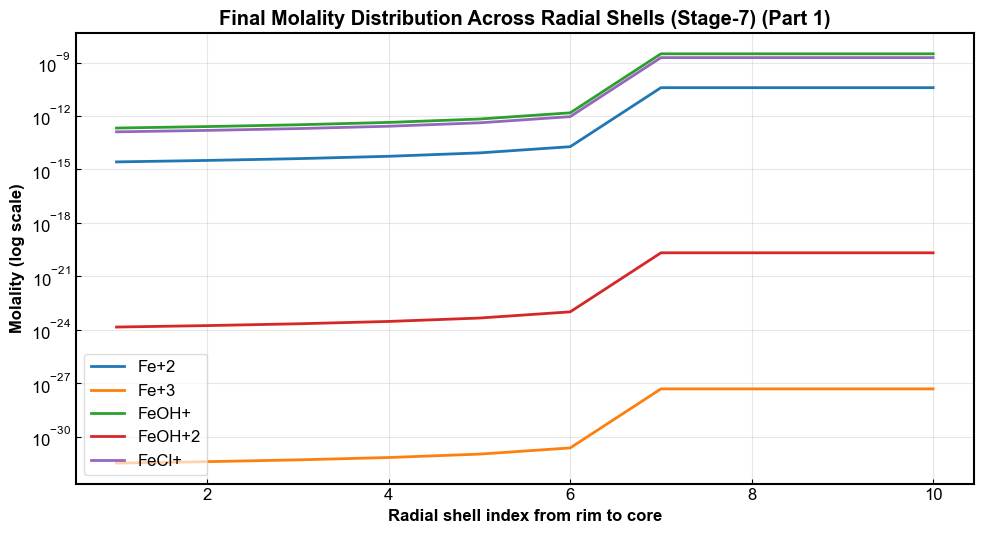

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


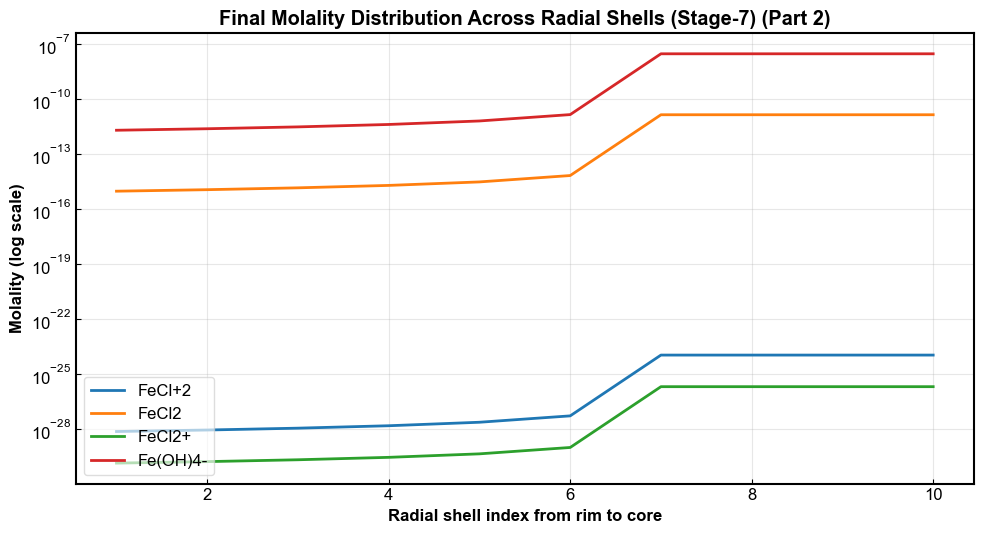

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


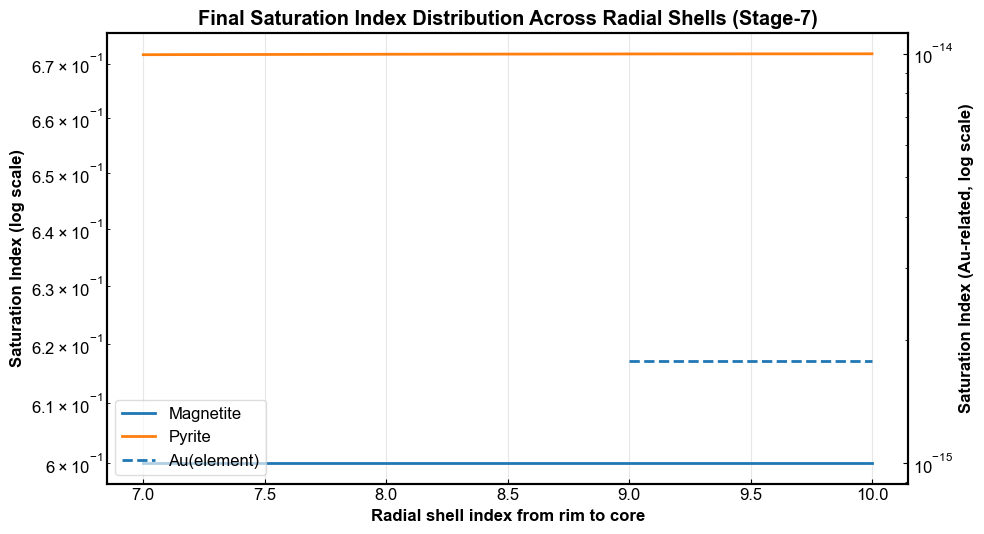

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


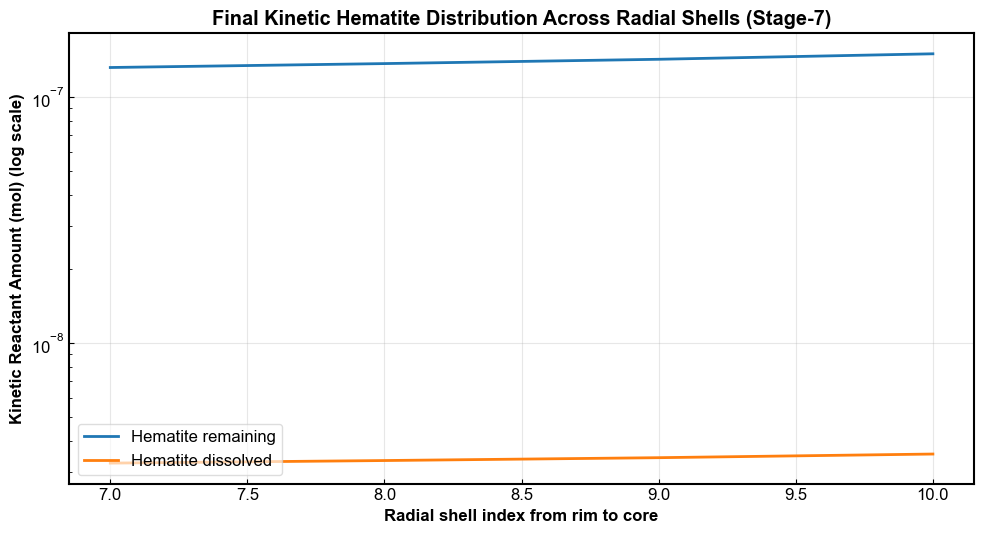

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_HematitePK_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


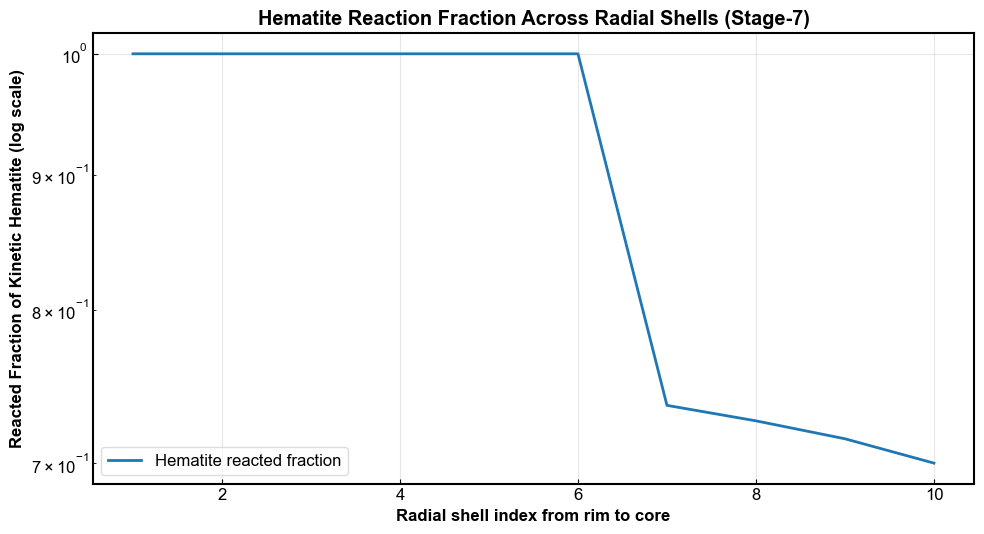

>>> Figure displayed inline : CFAS_Stage07_Stage_7_Final_HematitePK_ReactedFraction_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


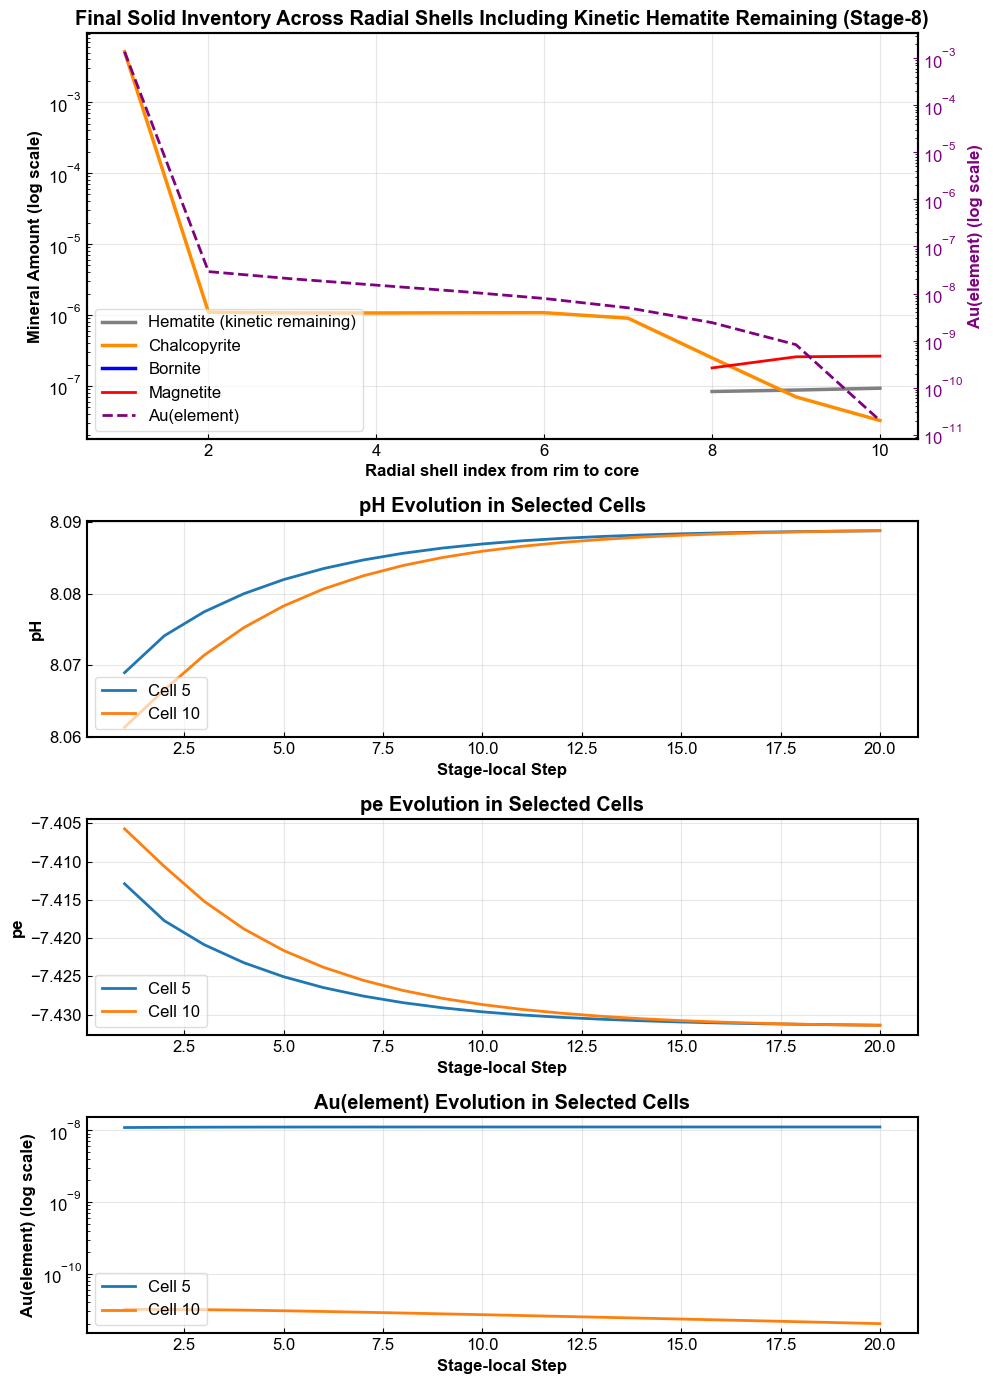

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Combined.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


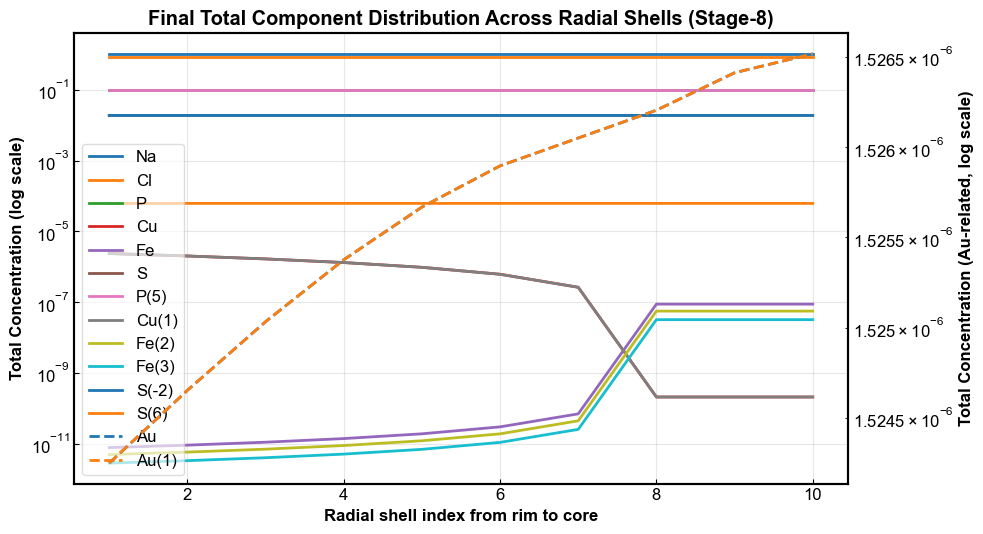

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_Totals_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


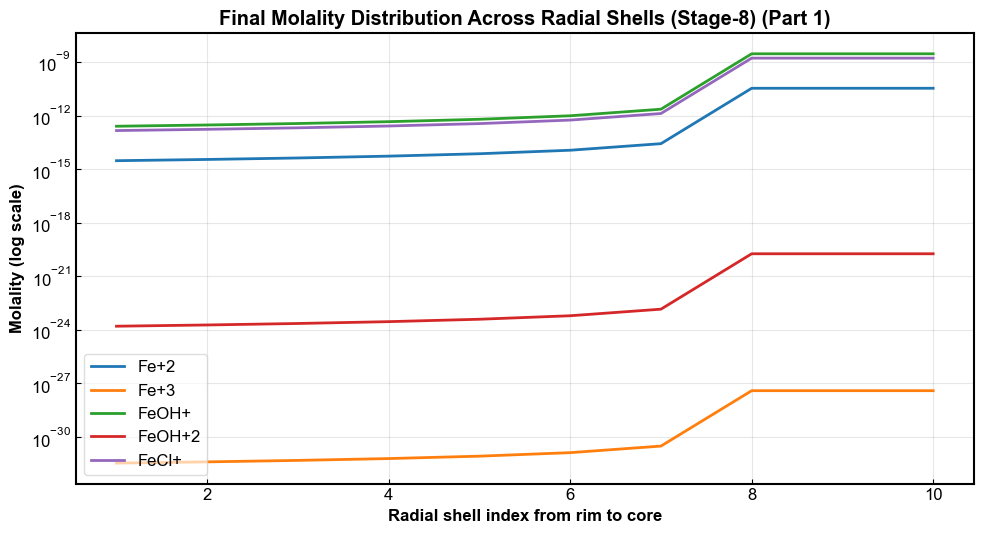

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_Molalities_AcrossCells_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


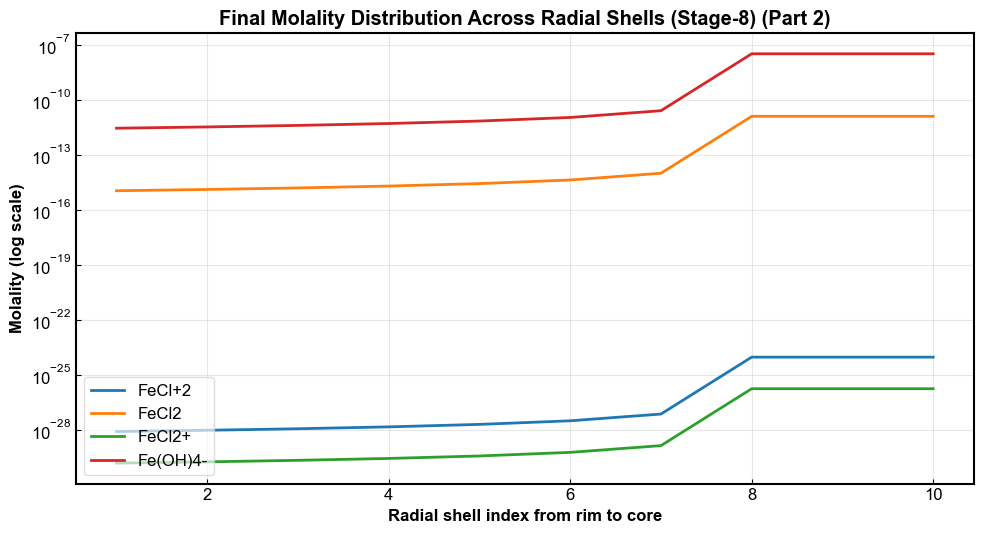

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_Molalities_AcrossCells_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


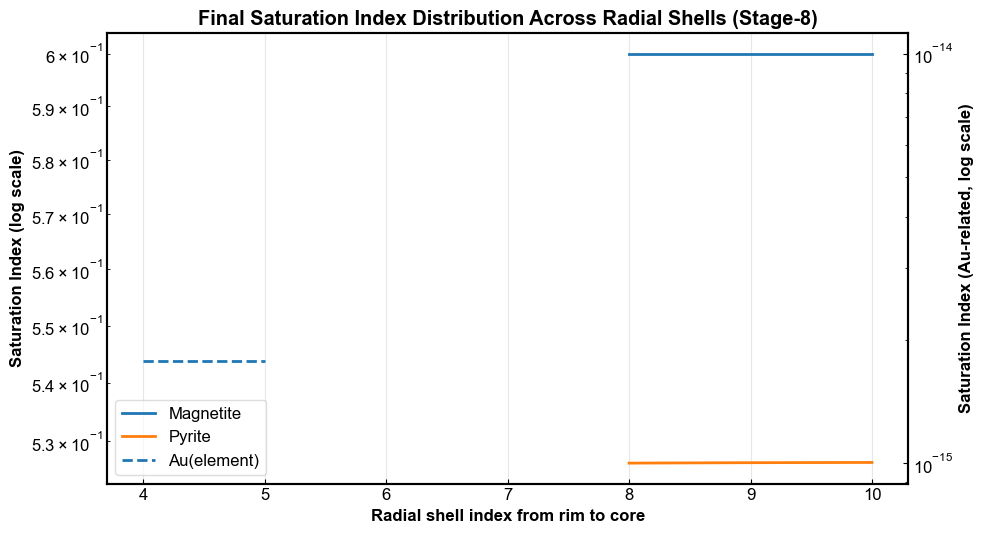

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_SI_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


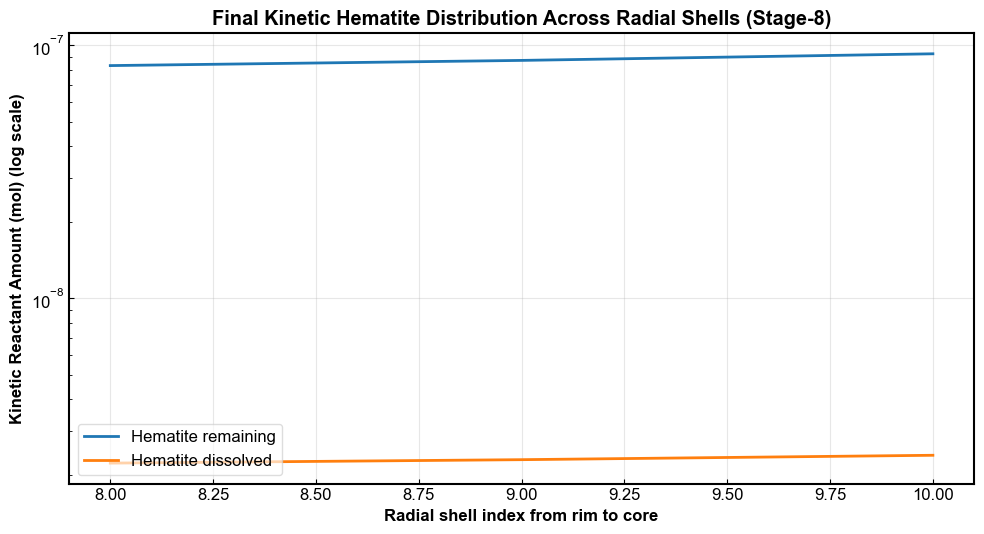

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_HematitePK_AcrossCells.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


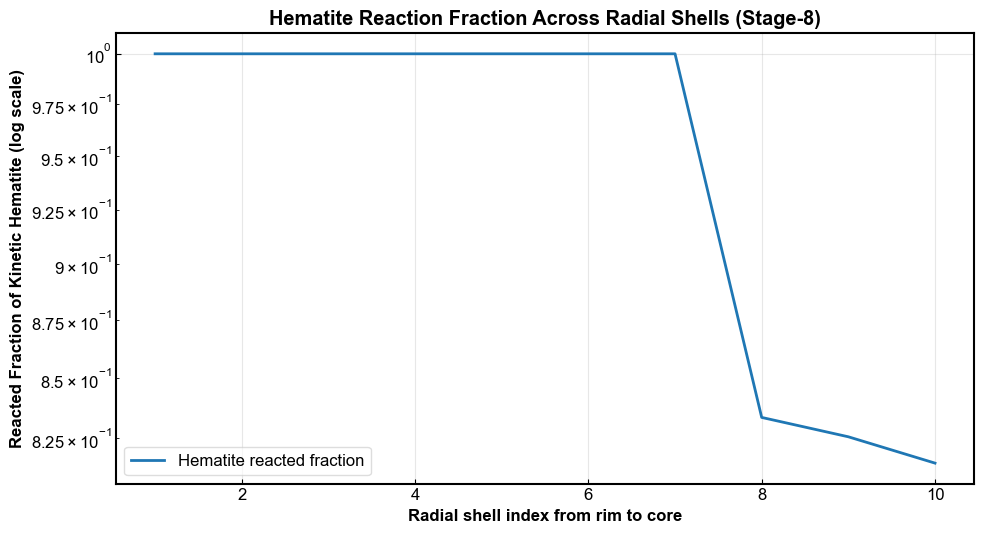

>>> Figure displayed inline : CFAS_Stage08_Stage_8_Final_HematitePK_ReactedFraction_AcrossCells.png
>>> Stage-separated figure summary:
    combined figures           : 8
    final-distribution figures : 48


In [553]:
# =========================================================
# Final distributions (stage-separated)
# =========================================================
n_fig_final = 0
n_fig_track = 0
n_fig_combined = 0

for meta in stage_final_frames:
    df_stage_final = meta["df_final"]
    if df_stage_final is None or len(df_stage_final) == 0:
        print(f">>> Skip final-distribution batch for {meta['stage_label']}: empty final slice.")
        continue

    df_stage_cells = stage_cell_tables.get(meta["stage_index"], pd.DataFrame()).copy()

    stage_slug = re.sub(r"[^A-Za-z0-9]+", "_", meta["stage_label"]).strip("_")
    title_suffix = f" ({meta['stage_label']})"

    n_fig_combined += int(render_stage_combined_figure(
        df_stage_final,
        df_stage_cells,
        target_cells,
        meta["stage_label"],
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Combined.png"
    ))

    n_fig_final += plot_final_distribution(
        df_stage_final,
        totals_map,
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_Totals_AcrossCells.png",
        "Final Total Component Distribution Across Radial Shells" + title_suffix,
        "Total Concentration"
    )

    n_fig_final += plot_grouped_final_distribution(
        df_stage_final,
        mol_map,
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_Molalities_AcrossCells",
        "Final Molality Distribution Across Radial Shells" + title_suffix,
        "Molality",
        group_size=5
    )

    n_fig_final += plot_grouped_final_distribution(
        df_stage_final,
        act_map,
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_Activities_AcrossCells",
        "Final Activity Distribution Across Radial Shells" + title_suffix,
        "Activity",
        group_size=6
    )

    n_fig_final += plot_final_distribution(
        df_stage_final,
        si_map,
        f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_SI_AcrossCells.png",
        "Final Saturation Index Distribution Across Radial Shells" + title_suffix,
        "Saturation Index"
    )

    kin_final_map = {}
    if "Hematite_PK_remaining" in df_stage_final.columns:
        kin_final_map["Hematite remaining"] = "Hematite_PK_remaining"
    if "Hematite_PK_dissolved" in df_stage_final.columns:
        kin_final_map["Hematite dissolved"] = "Hematite_PK_dissolved"
    if len(kin_final_map) > 0:
        n_fig_final += plot_final_distribution(
            df_stage_final,
            kin_final_map,
            f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_HematitePK_AcrossCells.png",
            "Final Kinetic Hematite Distribution Across Radial Shells" + title_suffix,
            "Kinetic Reactant Amount (mol)"
        )

    reacted_map = {}
    if "Hematite_PK_reacted_fraction" in df_stage_final.columns:
        reacted_map["Hematite reacted fraction"] = "Hematite_PK_reacted_fraction"
    if len(reacted_map) > 0:
        n_fig_final += plot_final_distribution(
            df_stage_final,
            reacted_map,
            f"CFAS_Stage{meta['stage_index']:02d}_{stage_slug}_Final_HematitePK_ReactedFraction_AcrossCells.png",
            "Hematite Reaction Fraction Across Radial Shells" + title_suffix,
            "Reacted Fraction of Kinetic Hematite"
        )

print(">>> Stage-separated figure summary:")
print(f"    combined figures           : {int(n_fig_combined)}")
print(f"    final-distribution figures : {int(n_fig_final)}")



C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


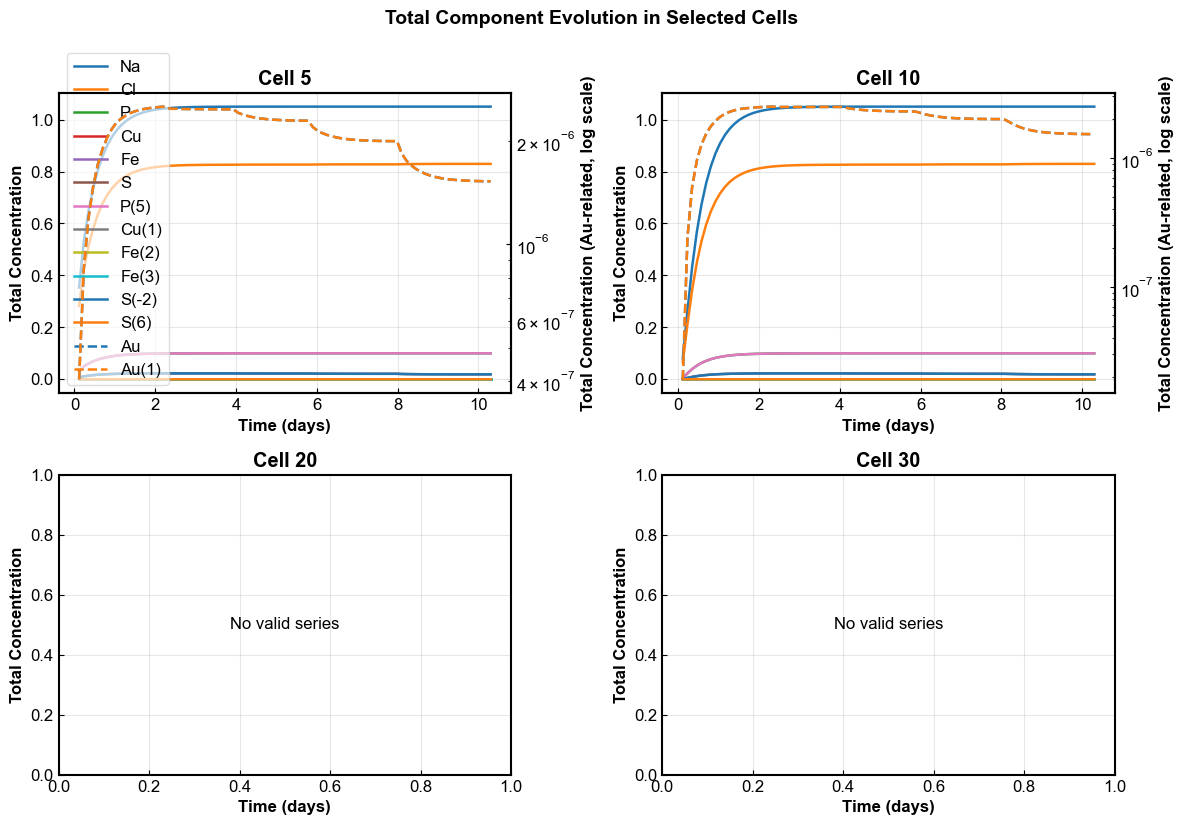

>>> Figure displayed inline : CFAS_TrackedCells_Totals.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


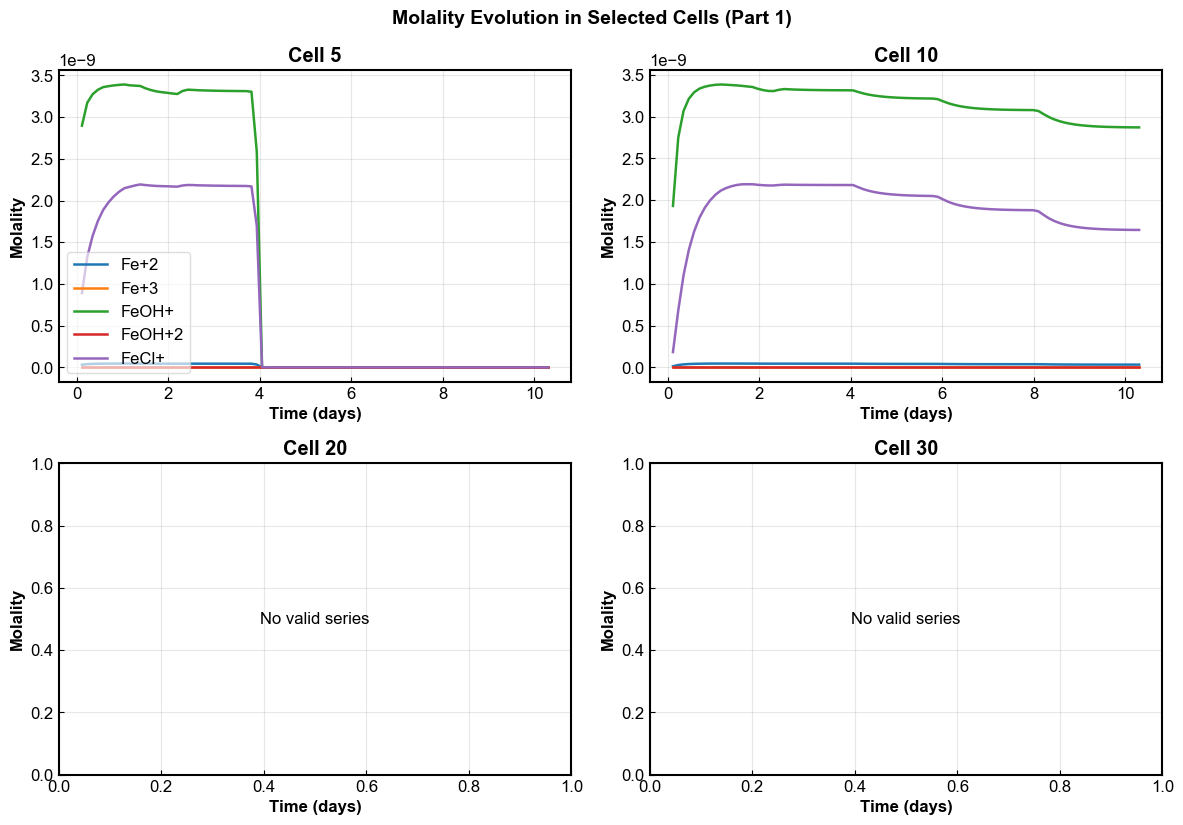

>>> Figure displayed inline : CFAS_TrackedCells_Molalities_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


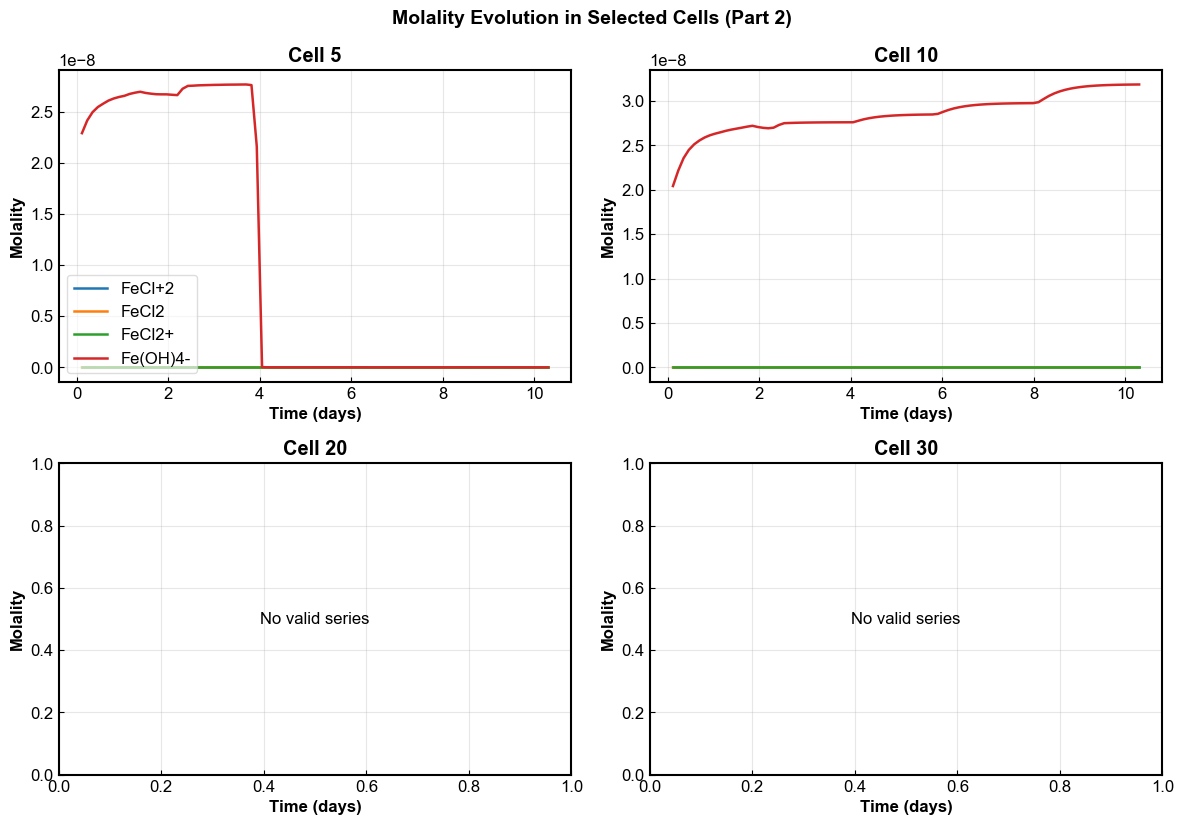

>>> Figure displayed inline : CFAS_TrackedCells_Molalities_part2.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


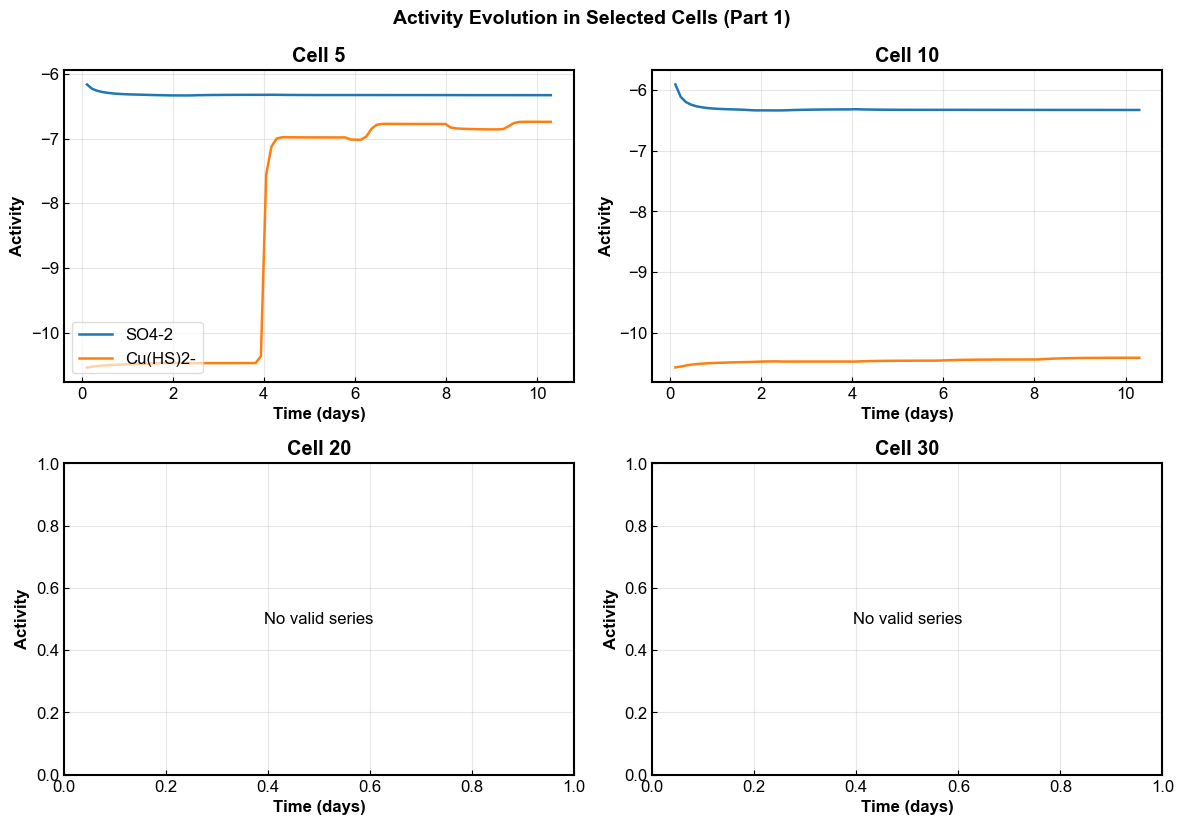

>>> Figure displayed inline : CFAS_TrackedCells_Activities_part1.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


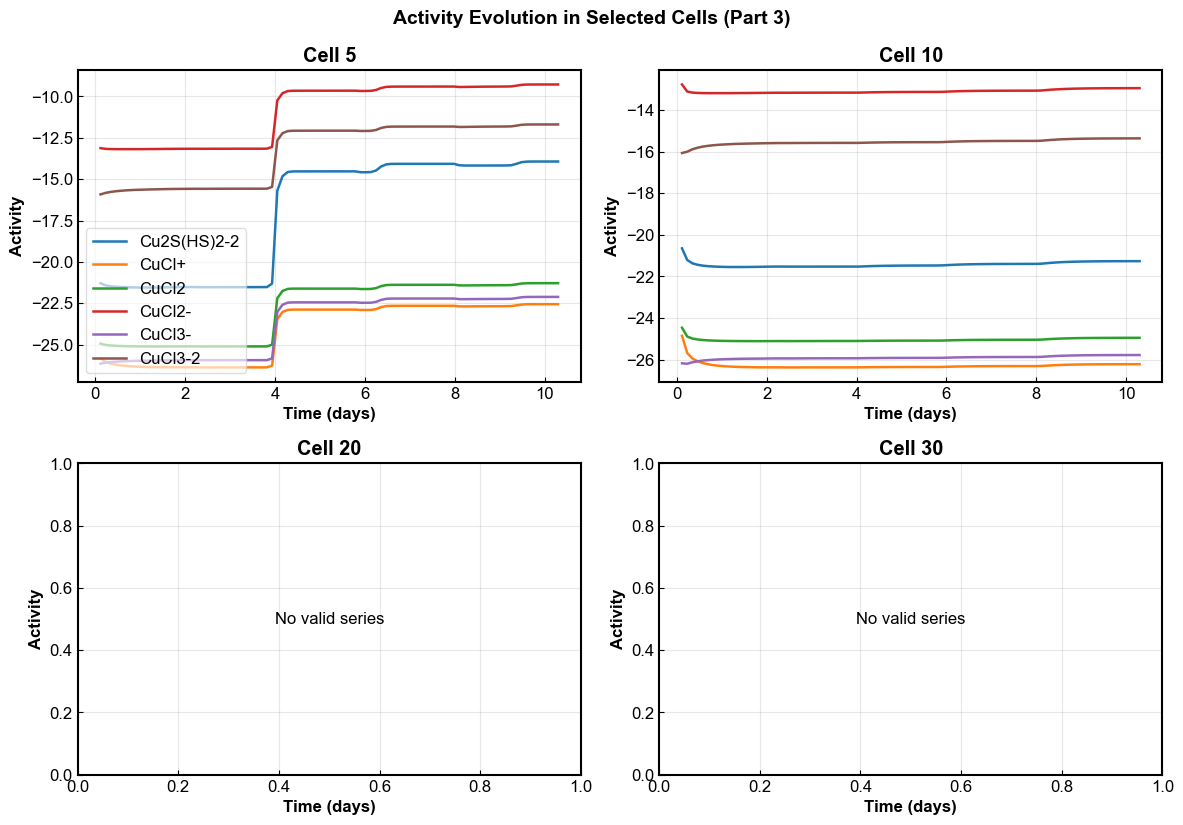

>>> Figure displayed inline : CFAS_TrackedCells_Activities_part3.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


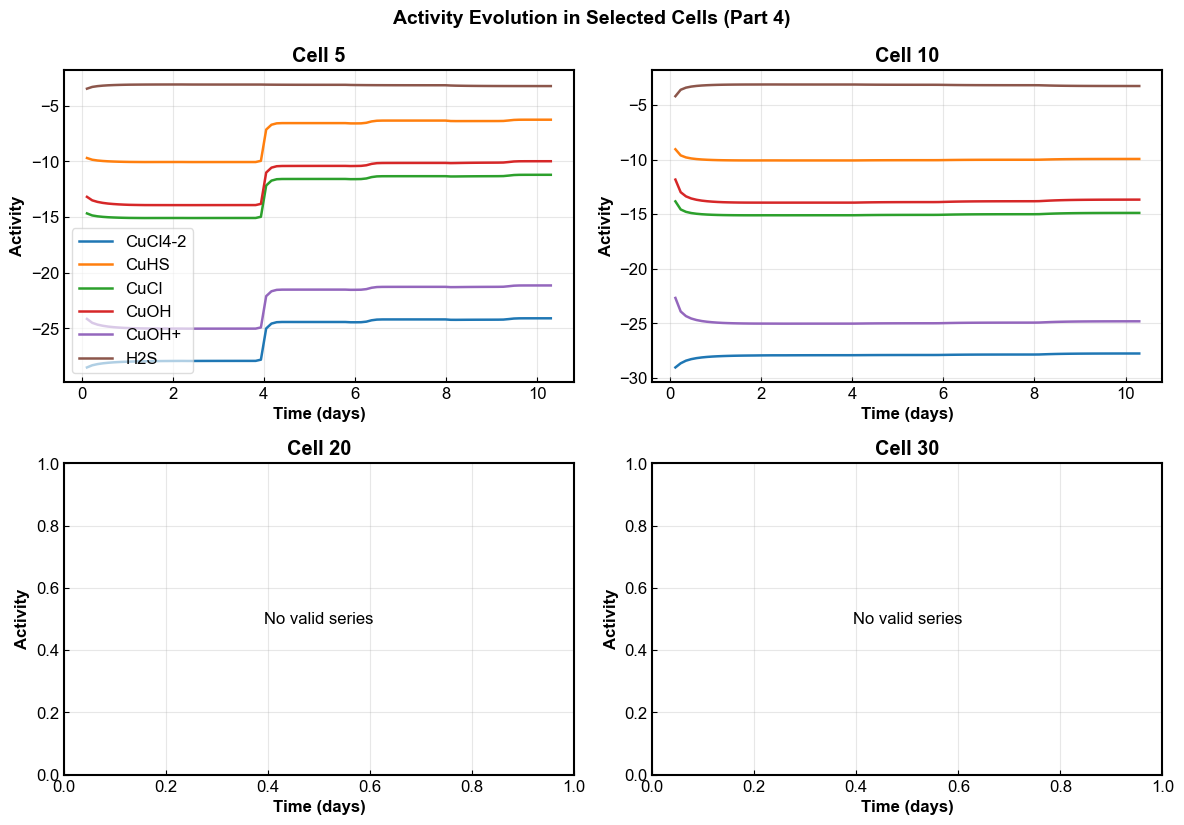

>>> Figure displayed inline : CFAS_TrackedCells_Activities_part4.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


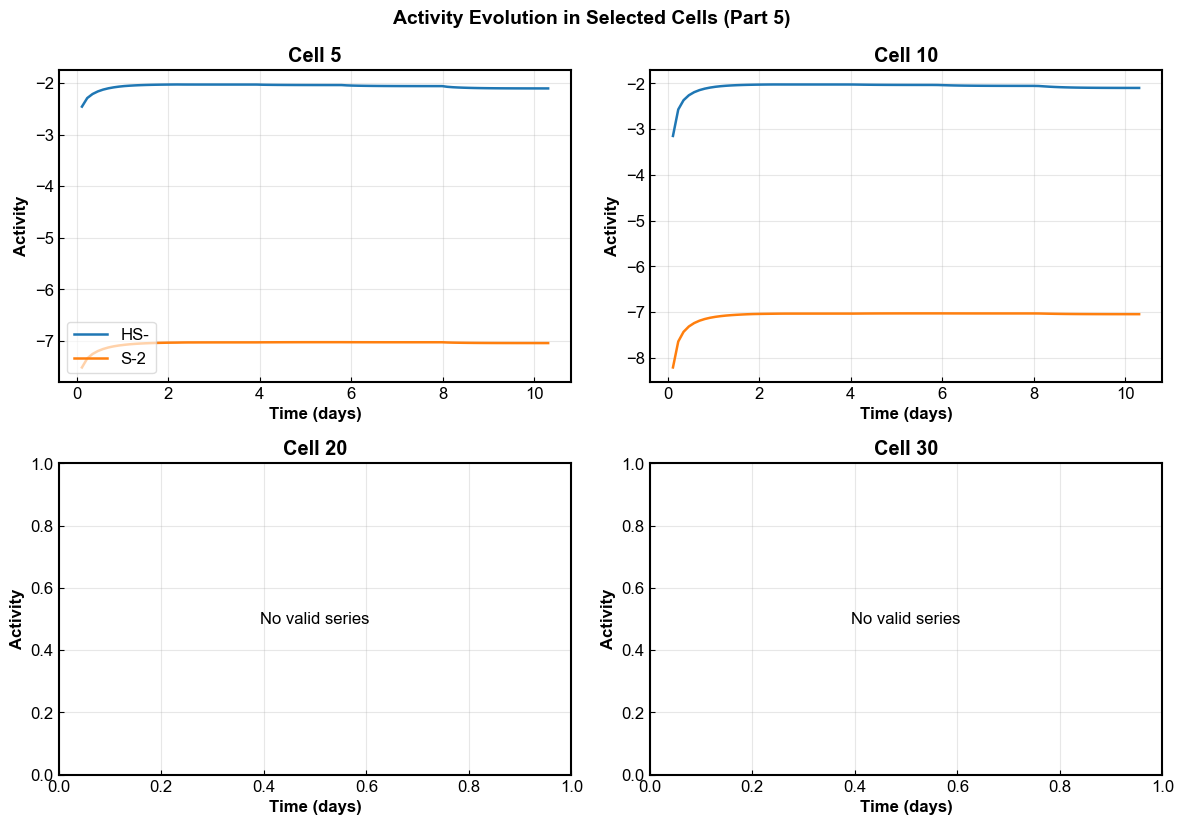

>>> Figure displayed inline : CFAS_TrackedCells_Activities_part5.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


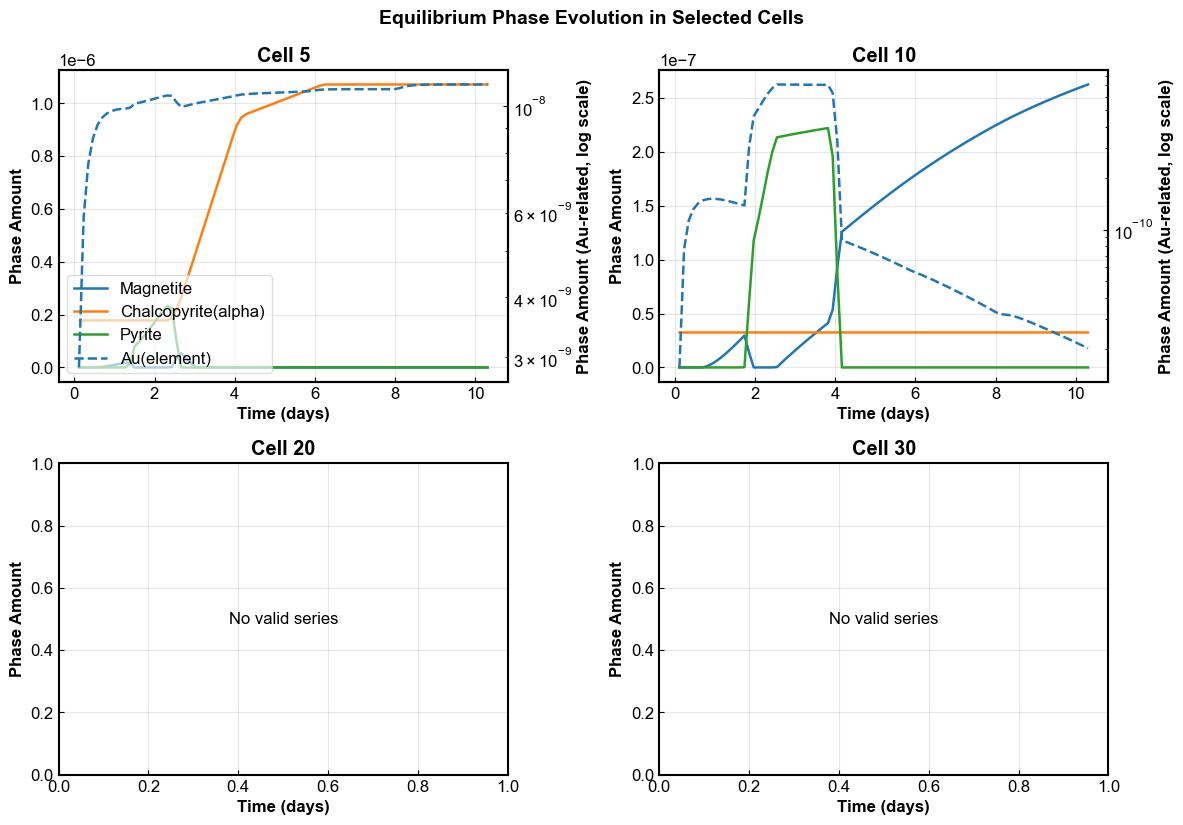

>>> Figure displayed inline : CFAS_TrackedCells_EquilibriumPhases.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


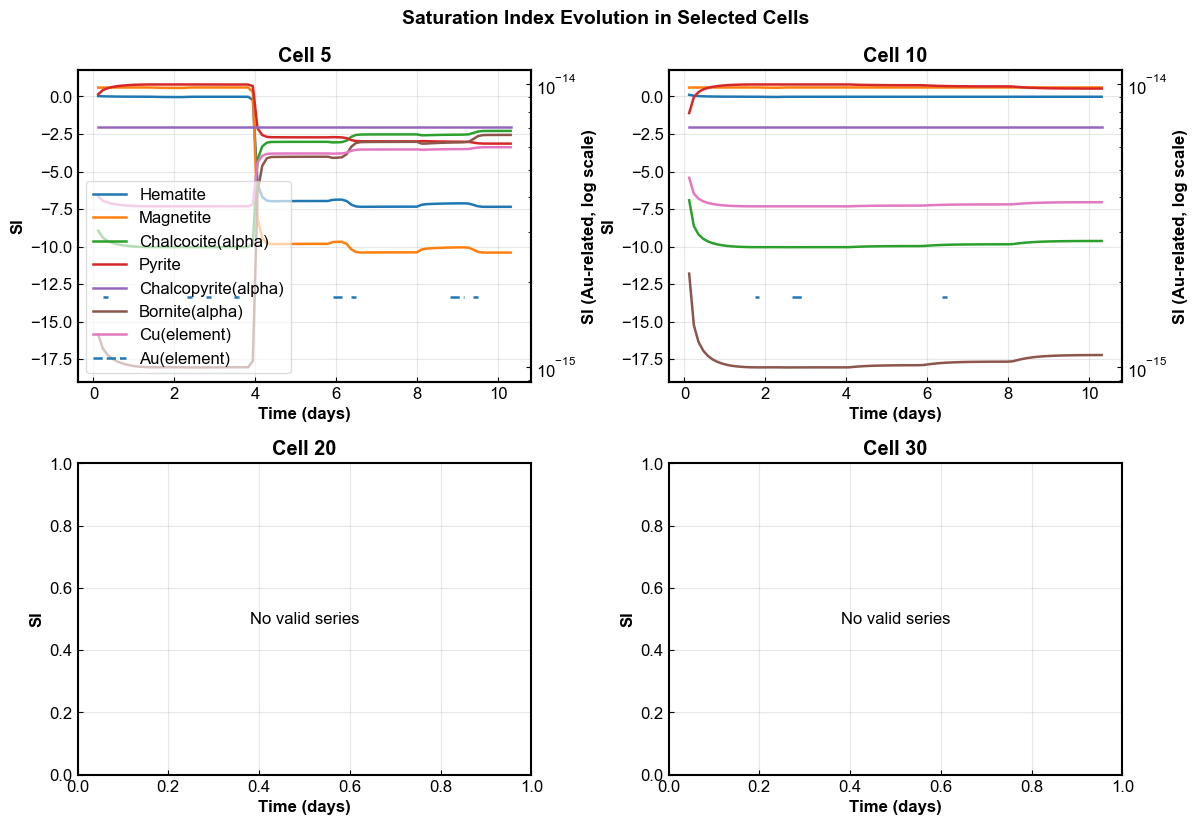

>>> Figure displayed inline : CFAS_TrackedCells_SI.png


C:\Users\m1536\AppData\Local\Temp\ipykernel_44760\2060688239.py:68: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


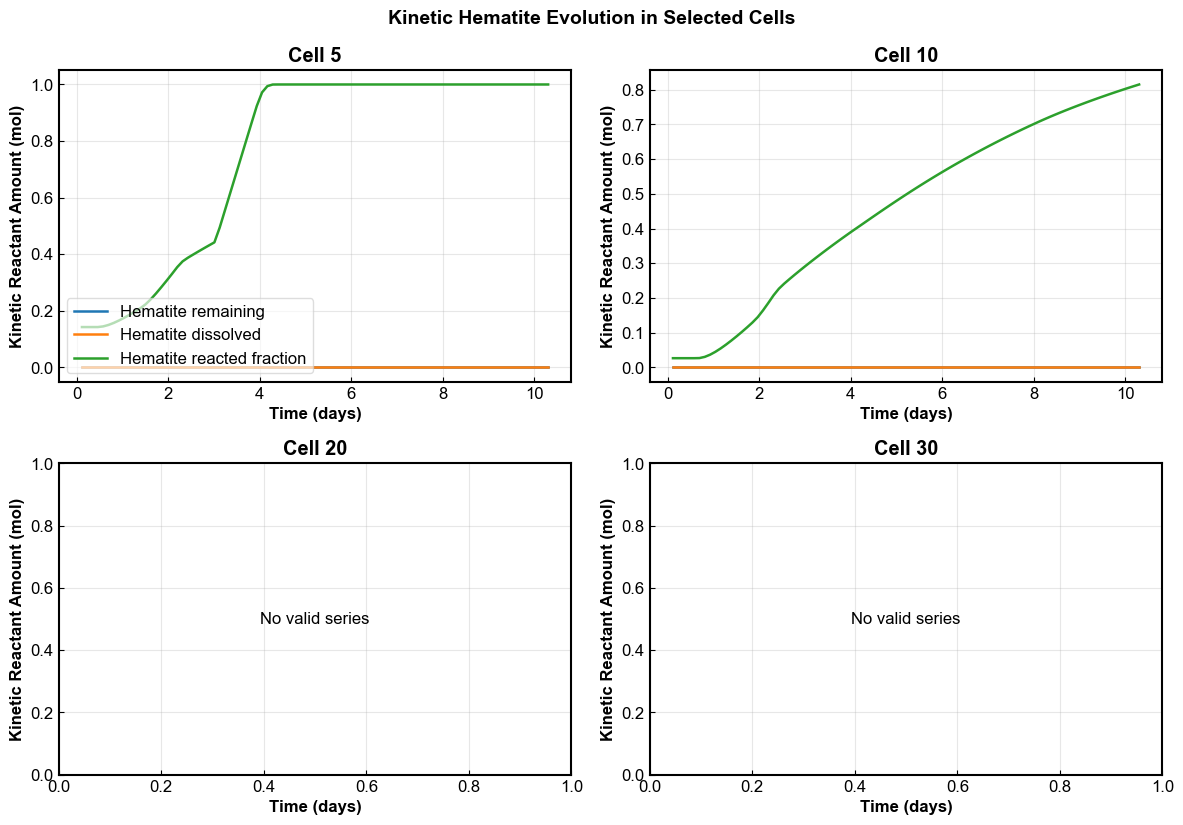

>>> Figure displayed inline : CFAS_TrackedCells_HematitePK_Kinetics.png
>>> Summary (stage-separated finals + full-run tracking):
    final-distribution figures : 48
    cell-tracking figures      : 10
>>> Finished successfully.


In [554]:
# =========================================================
# Tracking in selected cells
# =========================================================
n_fig_track += plot_cell_tracking(
    df_evo,
    target_cells,
    totals_map,
    "CFAS_TrackedCells_Totals.png",
    "Total Component Evolution in Selected Cells",
    "Total Concentration",
    time_xlabel
)

n_fig_track += plot_grouped_cell_tracking(
    df_evo,
    target_cells,
    mol_map,
    "CFAS_TrackedCells_Molalities",
    "Molality Evolution in Selected Cells",
    "Molality",
    time_xlabel,
    group_size=5
)

n_fig_track += plot_grouped_cell_tracking(
    df_evo,
    target_cells,
    act_map,
    "CFAS_TrackedCells_Activities",
    "Activity Evolution in Selected Cells",
    "Activity",
    time_xlabel,
    group_size=6
)

n_fig_track += plot_cell_tracking(
    df_evo,
    target_cells,
    eq_map,
    "CFAS_TrackedCells_EquilibriumPhases.png",
    "Equilibrium Phase Evolution in Selected Cells",
    "Phase Amount",
    time_xlabel
)

n_fig_track += plot_cell_tracking(
    df_evo,
    target_cells,
    si_map,
    "CFAS_TrackedCells_SI.png",
    "Saturation Index Evolution in Selected Cells",
    "SI",
    time_xlabel
)

kin_tracking_map = {}
if "Hematite_PK_remaining" in df_evo.columns:
    kin_tracking_map["Hematite remaining"] = "Hematite_PK_remaining"
if "Hematite_PK_dissolved" in df_evo.columns:
    kin_tracking_map["Hematite dissolved"] = "Hematite_PK_dissolved"
if "Hematite_PK_reacted_fraction" in df_evo.columns:
    kin_tracking_map["Hematite reacted fraction"] = "Hematite_PK_reacted_fraction"
if len(kin_tracking_map) > 0:
    n_fig_track += plot_cell_tracking(
        df_evo,
        target_cells,
        kin_tracking_map,
        "CFAS_TrackedCells_HematitePK_Kinetics.png",
        "Kinetic Hematite Evolution in Selected Cells",
        "Kinetic Reactant Amount (mol)",
        time_xlabel
    )
else:
    print(">>> Warning: No Hematite_PK kinetic columns found for tracking plot.")

print(">>> Summary (stage-separated finals + full-run tracking):")
print(f"    final-distribution figures : {int(n_fig_final)}")
print(f"    cell-tracking figures      : {int(n_fig_track)}")
print(">>> Finished successfully.")


In [555]:
# Auxiliary diagnostics removed by refactor.
pass


In [556]:
# Auxiliary diagnostics removed by refactor.
pass
